In [ ]:
from pathlib import Path

DOWNLOAD_DIR = Path(
    "/kaggle/working/mooccubex_complete/relations"
)

DOWNLOAD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

COMPLETE_USER_VIDEO = (
    DOWNLOAD_DIR / "user-video.json"
)

print("Download location:", COMPLETE_USER_VIDEO)

In [ ]:
!curl -L --fail \
    --retry 20 \
    --retry-all-errors \
    --connect-timeout 30 \
    --speed-time 120 \
    --speed-limit 1024 \
    -C - \
    "https://lfs.aminer.cn/misc/moocdata/data/mooccube2/relations/user-video.json" \
    -o "/kaggle/working/mooccubex_complete/relations/user-video.json"

In [ ]:
%%bash
set -e

DEST="/kaggle/working/mooccubex_complete/relations"
FILE="$DEST/user-video.json"
URL="https://lfs.aminer.cn/misc/moocdata/data/mooccube2/relations/user-video.json"

mkdir -p "$DEST"

echo "Free disk space:"
df -h /kaggle/working

curl -L --fail \
  --retry 20 \
  --retry-all-errors \
  --retry-delay 5 \
  --connect-timeout 30 \
  --speed-time 120 \
  --speed-limit 1024 \
  -C - \
  "$URL" \
  -o "$FILE"

echo "Downloaded file:"
ls -lh "$FILE"

ACTUAL_SIZE=$(stat -c%s "$FILE")
echo "Size in bytes: $ACTUAL_SIZE"

if [ "$ACTUAL_SIZE" -lt 3000000000 ]; then
    echo "WARNING: The file appears incomplete. Run this cell again to resume."
    exit 1
fi

echo "Download completed successfully."

In [ ]:
from pathlib import Path
import json

USER_VIDEO = Path(
    "/kaggle/working/mooccubex_complete/relations/user-video.json"
)

print("Exists:", USER_VIDEO.exists())
print("Size:", round(USER_VIDEO.stat().st_size / 1024**3, 3), "GiB")

with USER_VIDEO.open("r", encoding="utf-8") as f:
    first_character = f.read(1)
    f.seek(0)

    if first_character == "[":
        first_record = next(iter(json.load(f)))
    else:
        first_record = json.loads(f.readline())

print("First record keys:", first_record.keys())

In [ ]:
from pathlib import Path
import duckdb
import os
import gc

# Close an old DuckDB connection left by the previous run.
if "con" in globals():
    try:
        con.close()
        print("Closed previous DuckDB connection.")
    except Exception as error:
        print("Previous connection was already closed:", error)

gc.collect()

DB = Path("/kaggle/working/mooccubex_preprocessing.duckdb")

if DB.exists():
    DB.unlink()
    print("Deleted stale DuckDB:", DB)

Path("/kaggle/working/duckdb_temp").mkdir(
    parents=True,
    exist_ok=True
)

con = duckdb.connect(str(DB))

con.execute(
    f"PRAGMA threads={max(1, min(4, os.cpu_count() or 2))}"
)
con.execute("PRAGMA memory_limit='12GB'")
con.execute(
    "PRAGMA temp_directory='/kaggle/working/duckdb_temp'"
)

stale_tables = [
    "interactions",
    "core",
    "core_next",
    "ranked",
    "train_base",
    "valid_base",
    "test_base",
    "eval_users",
    "eval_users_next",
    "train",
    "valid",
    "test",
]

for table in stale_tables:
    con.execute(f"DROP TABLE IF EXISTS {table}")

con.execute(
    f"""
    CREATE TABLE interactions AS
    SELECT *
    FROM read_parquet(
        '{RAW_INTERACTIONS.as_posix()}'
    )
    WHERE positive = 1
    """
)

positive_rows = con.execute(
    "SELECT COUNT(*) FROM interactions"
).fetchone()[0]

if positive_rows == 0:
    raise RuntimeError(
        "No positive interactions were found."
    )

print("DuckDB initialized successfully.")
print(f"Positive interactions: {positive_rows:,}")

In [ ]:
con.execute(
    """
    CREATE TABLE core AS
    SELECT
        user_id,
        video_id,
        any_value(ccid) AS ccid,
        min("timestamp") AS "timestamp",
        max(last_timestamp) AS last_timestamp,
        max(duration_seconds) AS duration_seconds,
        least(
            max(duration_seconds),
            sum(watched_seconds)
        ) AS watched_seconds,
        sum(playback_seconds) AS playback_seconds,
        least(
            1.0,
            sum(watched_seconds) /
            nullif(max(duration_seconds), 0)
        ) AS completion_ratio,
        sum(segment_count)::INTEGER AS segment_count,
        max(engagement_weight) AS engagement_weight,
        1::TINYINT AS positive
    FROM interactions
    GROUP BY user_id, video_id
    """
)

deduplicated_rows = con.execute(
    "SELECT COUNT(*) FROM core"
).fetchone()[0]

print(f"Deduplicated user-video rows: {deduplicated_rows:,}")

In [ ]:
MIN_USER_INTERACTIONS = 5
MIN_VIDEO_USERS = 5

for iteration in range(1, 21):
    before = con.execute(
        "SELECT COUNT(*) FROM core"
    ).fetchone()[0]

    con.execute("DROP TABLE IF EXISTS core_next")

    con.execute(
        f"""
        CREATE TABLE core_next AS
        SELECT c.*
        FROM core AS c

        JOIN (
            SELECT user_id
            FROM core
            GROUP BY user_id
            HAVING COUNT(*) >= {MIN_USER_INTERACTIONS}
        ) AS eligible_users
        USING (user_id)

        JOIN (
            SELECT video_id
            FROM core
            GROUP BY video_id
            HAVING COUNT(DISTINCT user_id) >= {MIN_VIDEO_USERS}
        ) AS eligible_videos
        USING (video_id)
        """
    )

    after = con.execute(
        "SELECT COUNT(*) FROM core_next"
    ).fetchone()[0]

    con.execute("DROP TABLE core")
    con.execute("ALTER TABLE core_next RENAME TO core")

    print(
        f"Sparse-filter iteration {iteration}: "
        f"{before:,} -> {after:,}"
    )

    if after == 0:
        raise RuntimeError(
            "Sparse filtering removed every interaction."
        )

    if after == before:
        print("Sparse filtering converged.")
        break

core_statistics = con.execute(
    """
    SELECT
        COUNT(*) AS interactions,
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT video_id) AS videos
    FROM core
    """
).df()

display(core_statistics)

In [ ]:
tables_to_remove = [
    "ranked",
    "train_base",
    "valid_base",
    "test_base",
    "eval_users",
    "eval_users_next",
    "train",
    "valid",
    "test",
]

for table in tables_to_remove:
    con.execute(f"DROP TABLE IF EXISTS {table}")

# Rank each user's interactions from newest to oldest.
con.execute(
    """
    CREATE TABLE ranked AS
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY
                "timestamp" DESC,
                last_timestamp DESC,
                video_id
        ) AS reverse_rank,
        COUNT(*) OVER (
            PARTITION BY user_id
        ) AS user_count
    FROM core
    """
)

# Latest interaction: test.
# Second latest: validation.
# Earlier interactions: training.
con.execute(
    """
    CREATE TABLE train_base AS
    SELECT * EXCLUDE (reverse_rank, user_count)
    FROM ranked
    WHERE reverse_rank > 2
    """
)

con.execute(
    """
    CREATE TABLE valid_base AS
    SELECT * EXCLUDE (reverse_rank, user_count)
    FROM ranked
    WHERE reverse_rank = 2
    """
)

con.execute(
    """
    CREATE TABLE test_base AS
    SELECT * EXCLUDE (reverse_rank, user_count)
    FROM ranked
    WHERE reverse_rank = 1
    """
)

# Initially retain users present in every split.
con.execute(
    """
    CREATE TABLE eval_users AS
    SELECT user_id FROM train_base
    INTERSECT
    SELECT user_id FROM valid_base
    INTERSECT
    SELECT user_id FROM test_base
    """
)

# Repeatedly enforce a training-only recommendation catalogue.
for iteration in range(1, 21):
    old_count = con.execute(
        "SELECT COUNT(*) FROM eval_users"
    ).fetchone()[0]

    for table in [
        "train",
        "valid",
        "test",
        "eval_users_next",
    ]:
        con.execute(f"DROP TABLE IF EXISTS {table}")

    con.execute(
        """
        CREATE TABLE train AS
        SELECT b.*
        FROM train_base AS b
        JOIN eval_users USING (user_id)
        """
    )

    con.execute(
        """
        CREATE TABLE valid AS
        SELECT b.*
        FROM valid_base AS b
        JOIN eval_users USING (user_id)
        JOIN (
            SELECT DISTINCT video_id
            FROM train
        ) AS training_catalog
        USING (video_id)
        """
    )

    con.execute(
        """
        CREATE TABLE test AS
        SELECT b.*
        FROM test_base AS b
        JOIN eval_users USING (user_id)
        JOIN (
            SELECT DISTINCT video_id
            FROM train
        ) AS training_catalog
        USING (video_id)
        """
    )

    con.execute(
        """
        CREATE TABLE eval_users_next AS
        SELECT user_id FROM train
        INTERSECT
        SELECT user_id FROM valid
        INTERSECT
        SELECT user_id FROM test
        """
    )

    new_count = con.execute(
        "SELECT COUNT(*) FROM eval_users_next"
    ).fetchone()[0]

    con.execute("DROP TABLE eval_users")
    con.execute(
        "ALTER TABLE eval_users_next RENAME TO eval_users"
    )

    print(
        f"Evaluation cleanup {iteration}: "
        f"{old_count:,} -> {new_count:,} users"
    )

    if new_count == 0:
        raise RuntimeError(
            "No evaluation users remain."
        )

    if new_count == old_count:
        print("Evaluation cleanup converged.")
        break

# Rebuild the three tables using the stable user set.
for table in ["train", "valid", "test"]:
    con.execute(f"DROP TABLE IF EXISTS {table}")

con.execute(
    """
    CREATE TABLE train AS
    SELECT b.*
    FROM train_base AS b
    JOIN eval_users USING (user_id)
    """
)

con.execute(
    """
    CREATE TABLE valid AS
    SELECT b.*
    FROM valid_base AS b
    JOIN eval_users USING (user_id)
    JOIN (
        SELECT DISTINCT video_id
        FROM train
    ) AS training_catalog
    USING (video_id)
    """
)

con.execute(
    """
    CREATE TABLE test AS
    SELECT b.*
    FROM test_base AS b
    JOIN eval_users USING (user_id)
    JOIN (
        SELECT DISTINCT video_id
        FROM train
    ) AS training_catalog
    USING (video_id)
    """
)

split_statistics = con.execute(
    """
    SELECT
        'train' AS split,
        COUNT(*) AS interactions,
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT video_id) AS videos
    FROM train

    UNION ALL

    SELECT
        'validation',
        COUNT(*),
        COUNT(DISTINCT user_id),
        COUNT(DISTINCT video_id)
    FROM valid

    UNION ALL

    SELECT
        'test',
        COUNT(*),
        COUNT(DISTINCT user_id),
        COUNT(DISTINCT video_id)
    FROM test
    """
).df()

display(split_statistics)

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import shutil
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

OUT = Path("/kaggle/working/processed")
SPLITS = OUT / "splits"
GRAPH = OUT / "graph"
REPORTS = OUT / "reports"

for directory in [OUT, SPLITS, GRAPH, REPORTS]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# 1. Save chronological splits
# ------------------------------------------------------------------

split_files = {
    "train": SPLITS / "train.parquet",
    "valid": SPLITS / "valid.parquet",
    "test": SPLITS / "test.parquet",
}

for table, output_file in split_files.items():
    con.execute(
        f"""
        COPY (
            SELECT *
            FROM {table}
            ORDER BY user_id, "timestamp", video_id
        )
        TO '{output_file.as_posix()}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    print(
        f"Saved {table}:",
        output_file,
        f"({output_file.stat().st_size / 1024**2:.2f} MB)"
    )

split_statistics.to_csv(
    REPORTS / "split_statistics.csv",
    index=False
)

# ------------------------------------------------------------------
# 2. Create user and video integer mappings
# ------------------------------------------------------------------

users = con.execute(
    """
    SELECT DISTINCT user_id
    FROM train
    ORDER BY user_id
    """
).df()

users["user_idx"] = np.arange(
    len(users),
    dtype=np.int64
)

videos = con.execute(
    """
    SELECT
        video_id,
        any_value(ccid) AS ccid
    FROM train
    GROUP BY video_id
    ORDER BY video_id
    """
).df()

videos["video_idx"] = np.arange(
    len(videos),
    dtype=np.int64
)

users.to_parquet(
    GRAPH / "user_index.parquet",
    index=False
)

videos.to_parquet(
    GRAPH / "video_index.parquet",
    index=False
)

train_video_ids = set(
    videos["video_id"].astype(str)
)

train_ccids = set(
    videos["ccid"].dropna().astype(str)
)

print("Indexed users:", len(users))
print("Indexed videos:", len(videos))

# ------------------------------------------------------------------
# 3. Build concept-video graph
# ------------------------------------------------------------------

concept_edges = []

concept_video_file = (
    META_ROOT / "relations/concept-video.txt"
)

with concept_video_file.open(
    "r",
    encoding="utf-8",
    errors="replace"
) as handle:

    for line in tqdm(
        handle,
        desc="Building concept-video graph"
    ):
        parts = line.rstrip("\n").split("\t")

        if len(parts) < 2:
            parts = line.strip().split()

        if len(parts) < 2:
            continue

        left = str(parts[0])
        right = str(parts[1])

        if left in train_ccids:
            concept_id = right
            ccid = left

        elif right in train_ccids:
            concept_id = left
            ccid = right

        else:
            continue

        concept_edges.append(
            (concept_id, ccid)
        )

concept_video_edges = pd.DataFrame(
    concept_edges,
    columns=["concept_id", "ccid"]
).drop_duplicates()

concept_ids = sorted(
    concept_video_edges["concept_id"]
    .astype(str)
    .unique()
)

concept_index = pd.DataFrame({
    "concept_id": concept_ids,
    "concept_idx": np.arange(
        len(concept_ids),
        dtype=np.int64
    )
})

concept_video_edges.to_parquet(
    GRAPH / "concept_video_edges.parquet",
    index=False
)

concept_index.to_parquet(
    GRAPH / "concept_index.parquet",
    index=False
)

print(
    "Concept-video edges:",
    len(concept_video_edges)
)

print(
    "Unique concepts:",
    len(concept_index)
)

# ------------------------------------------------------------------
# 4. Build course-video graph
# ------------------------------------------------------------------

course_rows = []

course_file = META_ROOT / "entities/course.json"

for course in tqdm(
    stream_json(course_file),
    desc="Building course-video graph"
):
    course_id = str(
        course.get("id")
        or course.get("course_id")
        or ""
    )

    for resource in course.get("resource") or []:
        resource_id = str(
            resource.get("resource_id") or ""
        )

        ccid = video_to_ccid.get(resource_id)

        if ccid not in train_ccids:
            continue

        titles = resource.get("titles") or []

        course_rows.append({
            "course_id": course_id,
            "course_video_id": resource_id,
            "ccid": ccid,
            "chapter": str(
                resource.get("chapter") or ""
            ),
            "titles": " / ".join(
                str(value)
                for value in titles
                if str(value).strip()
            )
        })

course_video_edges = pd.DataFrame(
    course_rows,
    columns=[
        "course_id",
        "course_video_id",
        "ccid",
        "chapter",
        "titles",
    ]
).drop_duplicates(
    ["course_id", "ccid"]
)

course_video_edges.to_parquet(
    GRAPH / "course_video_edges.parquet",
    index=False
)

print(
    "Course-video edges:",
    len(course_video_edges)
)

# ------------------------------------------------------------------
# 5. Save video captions and metadata
# ------------------------------------------------------------------

video_metadata_rows = []

for video_id in sorted(train_video_ids):
    ccid = video_to_ccid.get(video_id)
    metadata = metadata_by_ccid.get(ccid)

    if metadata is None:
        continue

    video_metadata_rows.append({
        "video_id": video_id,
        **metadata
    })

video_metadata = pd.DataFrame(
    video_metadata_rows,
    columns=[
        "video_id",
        "ccid",
        "duration_seconds",
        "caption_segment_count",
        "caption_text",
        "video_name",
        "start_segment_count",
    ]
)

video_metadata.to_parquet(
    GRAPH / "video_metadata.parquet",
    index=False
)

print(
    "Videos with caption metadata:",
    len(video_metadata)
)

# ------------------------------------------------------------------
# 6. Save concept names
# ------------------------------------------------------------------

wanted_concepts = set(concept_ids)
concept_metadata_rows = []

concept_file = META_ROOT / "entities/concept.json"

for record in tqdm(
    stream_json(concept_file),
    desc="Reading concept metadata"
):
    concept_id = str(
        record.get("id") or ""
    )

    if concept_id not in wanted_concepts:
        continue

    concept_metadata_rows.append({
        "concept_id": concept_id,
        "concept_name": str(
            record.get("name") or ""
        ),
        "context_count": len(
            record.get("context") or []
        )
    })

concept_metadata = pd.DataFrame(
    concept_metadata_rows,
    columns=[
        "concept_id",
        "concept_name",
        "context_count",
    ]
)

concept_metadata.to_parquet(
    GRAPH / "concept_metadata.parquet",
    index=False
)

print(
    "Concept metadata rows:",
    len(concept_metadata)
)

# ------------------------------------------------------------------
# 7. Leakage and chronology validation
# ------------------------------------------------------------------

checks = {
    "train_is_nonempty":
        con.execute(
            "SELECT COUNT(*) > 0 FROM train"
        ).fetchone()[0],

    "validation_is_nonempty":
        con.execute(
            "SELECT COUNT(*) > 0 FROM valid"
        ).fetchone()[0],

    "test_is_nonempty":
        con.execute(
            "SELECT COUNT(*) > 0 FROM test"
        ).fetchone()[0],

    "train_before_or_at_validation":
        con.execute(
            """
            SELECT COUNT(*) = 0
            FROM (
                SELECT
                    user_id,
                    MAX("timestamp") AS maximum_time
                FROM train
                GROUP BY user_id
            ) AS training_time
            JOIN valid USING (user_id)
            WHERE
                training_time.maximum_time >
                valid."timestamp"
            """
        ).fetchone()[0],

    "validation_before_or_at_test":
        con.execute(
            """
            SELECT COUNT(*) = 0
            FROM valid
            JOIN test USING (user_id)
            WHERE
                valid."timestamp" >
                test."timestamp"
            """
        ).fetchone()[0],

    "validation_items_in_training_catalog":
        con.execute(
            """
            SELECT COUNT(*) = 0
            FROM valid
            WHERE NOT EXISTS (
                SELECT 1
                FROM train
                WHERE
                    train.video_id =
                    valid.video_id
            )
            """
        ).fetchone()[0],

    "test_items_in_training_catalog":
        con.execute(
            """
            SELECT COUNT(*) = 0
            FROM test
            WHERE NOT EXISTS (
                SELECT 1
                FROM train
                WHERE
                    train.video_id =
                    test.video_id
            )
            """
        ).fetchone()[0],

    "same_validation_and_test_users":
        con.execute(
            """
            SELECT COUNT(*) = 0
            FROM (
                (
                    SELECT user_id FROM valid
                    EXCEPT
                    SELECT user_id FROM test
                )
                UNION ALL
                (
                    SELECT user_id FROM test
                    EXCEPT
                    SELECT user_id FROM valid
                )
            )
            """
        ).fetchone()[0],

    "unique_user_video_pairs":
        con.execute(
            """
            SELECT
                (
                    SELECT COUNT(*) FROM train
                ) = (
                    SELECT COUNT(*)
                    FROM (
                        SELECT DISTINCT
                            user_id,
                            video_id
                        FROM train
                    )
                )
                AND
                (
                    SELECT COUNT(*) FROM valid
                ) = (
                    SELECT COUNT(*)
                    FROM (
                        SELECT DISTINCT
                            user_id,
                            video_id
                        FROM valid
                    )
                )
                AND
                (
                    SELECT COUNT(*) FROM test
                ) = (
                    SELECT COUNT(*)
                    FROM (
                        SELECT DISTINCT
                            user_id,
                            video_id
                        FROM test
                    )
                )
            """
        ).fetchone()[0],
}

validation = pd.DataFrame(
    checks.items(),
    columns=["check", "passed"]
)

validation.to_csv(
    REPORTS / "preprocessing_validation.csv",
    index=False
)

display(validation)

if not validation["passed"].astype(bool).all():
    failed = validation.loc[
        ~validation["passed"].astype(bool)
    ]

    raise AssertionError(
        "Preprocessing validation failed:\n"
        + failed.to_string(index=False)
    )

print("All preprocessing checks passed.")

# ------------------------------------------------------------------
# 8. Save preprocessing manifest
# ------------------------------------------------------------------

manifest = {
    "created_at": datetime.now(
        timezone.utc
    ).isoformat(),

    "source_file": str(USER_VIDEO),

    "source_size_bytes":
        USER_VIDEO.stat().st_size,

    "parameters": {
        "minimum_user_interactions":
            MIN_USER_INTERACTIONS,

        "minimum_video_users":
            MIN_VIDEO_USERS,

        "minimum_watch_seconds":
            MIN_WATCH_SECONDS,

        "minimum_completion_ratio":
            MIN_COMPLETION_RATIO,

        "maximum_video_duration_seconds":
            SHORT_VIDEO_MAX_SECONDS,
    },

    "split_method":
        "Per-user chronological leave-two-out",

    "split_statistics":
        split_statistics.to_dict(
            orient="records"
        ),

    "graph_statistics": {
        "users": len(users),
        "videos": len(videos),
        "concepts": len(concept_index),
        "concept_video_edges":
            len(concept_video_edges),
        "course_video_edges":
            len(course_video_edges),
        "videos_with_caption_metadata":
            len(video_metadata),
    },

    "files": sorted(
        str(path.relative_to(OUT))
        for path in OUT.rglob("*")
        if path.is_file()
    ),
}

with (
    REPORTS / "preprocessing_manifest.json"
).open(
    "w",
    encoding="utf-8"
) as handle:
    json.dump(
        manifest,
        handle,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------------
# 9. Create downloadable ZIP
# ------------------------------------------------------------------

zip_path = shutil.make_archive(
    "/kaggle/working/MOOCCubeX_processed",
    "zip",
    root_dir=str(OUT.parent),
    base_dir=OUT.name,
)

print("\nPreprocessing completed successfully.")
print("Processed data:", OUT)
print("Downloadable ZIP:", zip_path)
print(
    "ZIP size:",
    f"{Path(zip_path).stat().st_size / 1024**2:.2f} MB"
)

display(split_statistics)

In [ ]:
"""Three-seed validation-tuned BCE-SASRec experiment for Kaggle.

Requires preprocessed MOOCCubeX splits and graph Parquet files under /kaggle/input.
Hyperparameters are chosen only by validation NDCG@10. The test set is evaluated
after selection for seeds 42, 2026 and 3407. A target is reported, never forced.
"""
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor is True")
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x)


# ---- notebook cell 3 ----

from pathlib import Path
from dataclasses import dataclass, asdict
import copy, gc, json, math, os, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

@dataclass
class Config:
    root: str = '/kaggle/input'
    seed: int = 42
    max_len: int = 50
    max_concepts_per_video: int = 12
    hidden_dim: int = 128
    transformer_layers: int = 2
    attention_heads: int = 4
    feedforward_dim: int = 512
    dropout: float = 0.10
    time_buckets: int = 32
    negatives: int = 50
    batch_size: int = 128
    eval_batch_size: int = 128
    max_epochs: int = 25
    minimum_epochs: int = 10
    early_stopping_patience: int = 5
    early_stopping_min_delta: float = 1e-4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    concept_loss_weight: float = 0.20
    completion_loss_weight: float = 0.10
    gradient_clip: float = 5.0
    use_mixed_precision: bool = False
    ks: tuple = (5, 10, 20)
    num_workers: int = 2

CFG=Config()

# Prefer preprocessing outputs created in this Kaggle session.
working_processed=Path('/kaggle/working/processed')
search_roots=[working_processed,Path('/kaggle/input')]
matches=[]
for search_root in search_roots:
    if search_root.name=='processed':
        candidates=[search_root/'splits/train.parquet']
    else:
        candidates=[p for p in search_root.rglob('train.parquet') if p.parent.name=='splits']
    for train_path in candidates:
        processed=train_path.parent.parent
        graph=processed/'graph'
        required_graph=['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']
        if train_path.exists() and all((graph/name).exists() for name in required_graph) and (train_path.parent/'valid.parquet').exists() and (train_path.parent/'test.parquet').exists():
            matches.append(processed)
    if matches:break
if not matches:
    raise FileNotFoundError('Could not find a complete processed/splits and processed/graph dataset.')
PROCESSED=matches[0];SPLITS=PROCESSED/'splits';GRAPH=PROCESSED/'graph';ROOT=PROCESSED.parent

# Kaggle inputs are read-only; every generated artifact goes to /kaggle/working.
OUT=Path('/kaggle/working/proposed_bce_sasrec_3seeds');CHECKPOINTS=OUT/'checkpoints';REPORTS=OUT/'reports';EXPLANATIONS=OUT/'explanations'
for p in [OUT,CHECKPOINTS,REPORTS,EXPLANATIONS]:p.mkdir(parents=True,exist_ok=True)
print('Detected processed data:',PROCESSED)
print('Output directory:',OUT)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

seed_everything(CFG.seed)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))
print(json.dumps(asdict(CFG),indent=2))

# ---- notebook cell 5 ----

required=[SPLITS/'train.parquet',SPLITS/'valid.parquet',SPLITS/'test.parquet',
          GRAPH/'video_metadata.parquet',GRAPH/'concept_video_edges.parquet',
          GRAPH/'video_index.parquet',GRAPH/'course_video_edges.parquet']
missing=[str(p) for p in required if not p.exists()]
if missing: raise FileNotFoundError(f'Missing preprocessing outputs: {missing}')

train_df=pd.read_parquet(SPLITS/'train.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
valid_df=pd.read_parquet(SPLITS/'valid.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
test_df=pd.read_parquet(SPLITS/'test.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)

required_columns={'user_id','video_id','timestamp','duration_seconds','watched_seconds',
                  'playback_seconds','completion_ratio','segment_count','engagement_weight'}
for name,frame in [('train',train_df),('valid',valid_df),('test',test_df)]:
    absent=required_columns-set(frame.columns)
    if absent: raise ValueError(f'{name} is missing columns: {sorted(absent)}')
    frame['user_id']=frame.user_id.astype(str); frame['video_id']=frame.video_id.astype(str)
    frame['timestamp']=pd.to_numeric(frame.timestamp,errors='coerce').fillna(0).astype('int64')

item_ids=sorted(train_df.video_id.unique()); user_ids=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
item2idx={v:i+1 for i,v in enumerate(item_ids)}; idx2item={i:v for v,i in item2idx.items()}
user2idx={u:i for i,u in enumerate(user_ids)}; idx2user={i:u for u,i in user2idx.items()}
num_items,num_users=len(item2idx),len(user2idx)

def map_frame(frame):
    x=frame[frame.video_id.isin(item2idx)].copy().reset_index(drop=True)
    x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64')
    return x

train=map_frame(train_df);valid=map_frame(valid_df);test=map_frame(test_df)
print({'train':len(train),'validation':len(valid),'test':len(test),'users':num_users,'videos':num_items})
display(pd.DataFrame([
    ['train',len(train),train.u.nunique(),train.i.nunique()],
    ['validation',len(valid),valid.u.nunique(),valid.i.nunique()],
    ['test',len(test),test.u.nunique(),test.i.nunique()]],
    columns=['split','interactions','users','videos']))

# ---- notebook cell 7 ----

train_max=train.groupby('u').timestamp.max()
valid_by_user=valid.set_index('u'); test_by_user=test.set_index('u')
common_users=sorted(set(train_max.index)&set(valid_by_user.index)&set(test_by_user.index))

checks={
 'train_before_or_at_validation':bool((train_max.loc[common_users].values<=valid_by_user.loc[common_users].timestamp.values).all()),
 'validation_before_or_at_test':bool((valid_by_user.loc[common_users].timestamp.values<=test_by_user.loc[common_users].timestamp.values).all()),
 'validation_items_in_training_catalog':bool(valid.i.isin(set(train.i)).all()),
 'test_items_in_training_catalog':bool(test.i.isin(set(train.i)).all()),
 'same_validation_and_test_users':set(valid.u)==set(test.u),
}
display(pd.DataFrame(checks.items(),columns=['check','passed']))
if not all(checks.values()): raise AssertionError('Leakage/chronology audit failed.')

# ---- notebook cell 9 ----

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds',
                   'completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR:x[c]=np.log1p(x[c].clip(lower=0))
    return x

train_beh_raw=raw_behaviour(train);beh_mean=train_beh_raw.mean();beh_std=train_beh_raw.std().replace(0,1).fillna(1)
def normalized_behaviour(frame):return ((raw_behaviour(frame)-beh_mean)/beh_std).astype('float32').to_numpy()
train_beh=normalized_behaviour(train);valid_beh=normalized_behaviour(valid);test_beh=normalized_behaviour(test)
normalization={'columns':BEHAVIOUR_COLUMNS,'mean':beh_mean.to_dict(),'std':beh_std.to_dict(),'log1p_columns':sorted(LOG_BEHAVIOUR)}
json.dump(normalization,open(REPORTS/'behaviour_normalization.json','w'),indent=2)
display(pd.DataFrame({'mean':beh_mean,'std':beh_std}))

# ---- notebook cell 11 ----

video_index=pd.read_parquet(GRAPH/'video_index.parquet');video_index['video_id']=video_index.video_id.astype(str);video_index['ccid']=video_index.ccid.astype(str)
video_to_ccid=dict(zip(video_index.video_id,video_index.ccid));ccid_to_item={video_to_ccid[v]:item2idx[v] for v in item2idx if v in video_to_ccid}

cv=pd.read_parquet(GRAPH/'concept_video_edges.parquet');cv['concept_id']=cv.concept_id.astype(str);cv['ccid']=cv.ccid.astype(str)
cv=cv[cv.ccid.isin(ccid_to_item)].drop_duplicates(['ccid','concept_id'])
concept_ids=sorted(cv.concept_id.unique());concept2idx={c:i+1 for i,c in enumerate(concept_ids)};idx2concept={i:c for c,i in concept2idx.items()}
item_concepts=np.zeros((num_items+1,CFG.max_concepts_per_video),dtype=np.int64)
for ccid,g in cv.groupby('ccid'):
    ids=[concept2idx[c] for c in g.concept_id.iloc[:CFG.max_concepts_per_video]]
    item_concepts[ccid_to_item[ccid],:len(ids)]=ids

course=pd.read_parquet(GRAPH/'course_video_edges.parquet')
if 'video_id' not in course.columns:
    if 'course_video_id' in course.columns:course=course.rename(columns={'course_video_id':'video_id'})
    else:raise ValueError('course_video_edges.parquet needs video_id or course_video_id')
course['video_id']=course.video_id.astype(str);course['course_id']=course.course_id.astype(str)
course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
course_ids=sorted(course.course_id.unique());course2idx={c:i+1 for i,c in enumerate(course_ids)}
item_course=np.zeros(num_items+1,dtype=np.int64)
for row in course.itertuples():item_course[item2idx[row.video_id]]=course2idx[row.course_id]

metadata=pd.read_parquet(GRAPH/'video_metadata.parquet');metadata['video_id']=metadata.video_id.astype(str)
META_COLUMNS=['duration_seconds','subtitle_sentences','subtitle_characters','concept_count']
for c in META_COLUMNS:
    if c not in metadata:metadata[c]=0
metadata=metadata.drop_duplicates('video_id').set_index('video_id')
meta_table=pd.DataFrame(index=item_ids,columns=META_COLUMNS,dtype='float32')
for c in META_COLUMNS:meta_table[c]=pd.to_numeric(metadata.reindex(item_ids)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).astype('float32')
for c in META_COLUMNS:meta_table[c]=np.log1p(meta_table[c].clip(lower=0))
meta_mean=meta_table.mean();meta_std=meta_table.std().replace(0,1).fillna(1)
meta_table=((meta_table-meta_mean)/meta_std).astype('float32')
item_metadata=np.zeros((num_items+1,len(META_COLUMNS)),dtype=np.float32);item_metadata[1:]=meta_table.to_numpy()

print({'concepts':len(concept_ids),'concept_video_edges':len(cv),'courses':len(course_ids),
       'videos_with_concepts':int((item_concepts!=0).any(1).sum()),'videos_with_courses':int((item_course!=0).sum())})
json.dump({'meta_columns':META_COLUMNS,'mean':meta_mean.to_dict(),'std':meta_std.to_dict()},open(REPORTS/'metadata_normalization.json','w'),indent=2)

# ---- notebook cell 13 ----

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx));g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

train_h=build_history(train,train_beh);valid_events=build_history(valid,valid_beh);test_events=build_history(test,test_beh)
eval_users=sorted(set(train_h)&set(valid_events)&set(test_events))
valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}
test_hist={}
valid_target={u:valid_events[u]['items'][0] for u in eval_users};test_target={u:test_events[u]['items'][0] for u in eval_users}
valid_completion={u:valid_events[u]['completion'][0] for u in eval_users};test_completion={u:test_events[u]['completion'][0] for u in eval_users}
for u in eval_users:
    h=copy.deepcopy(train_h[u])
    for key in ['items','times','behaviour','completion']:h[key].append(valid_events[u][key][0])
    test_hist[u]=h

all_positive={u:set(train_h[u]['items'])|{valid_target[u],test_target[u]} for u in eval_users}
for u in train_h:
    all_positive.setdefault(u,set(train_h[u]['items']))
assert all(valid_target[u] not in valid_hist[u]['items'] for u in eval_users)
assert all(test_target[u] not in test_hist[u]['items'] for u in eval_users)
print('Leakage-free evaluation users:',len(eval_users))

# ---- notebook cell 15 ----

def left_pad(seq,n,pad):
    # Right padding prevents fully masked attention rows under a causal mask.
    seq=list(seq)[-n:];return seq+[pad]*(n-len(seq))

class PrefixDataset(Dataset):
    def __init__(self,histories,max_len):
        self.h=histories;self.max_len=max_len
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self):return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index];h=self.h[u]
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],self.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

train_dataset=PrefixDataset(train_h,CFG.max_len)
train_loader=DataLoader(train_dataset,batch_size=CFG.batch_size,shuffle=True,num_workers=CFG.num_workers,
                        pin_memory=True,persistent_workers=CFG.num_workers>0)
print('Training prefix examples:',len(train_dataset),'batches per epoch:',len(train_loader))

def sample_negatives(users,count):
    result=[]
    for u in users.tolist():
        values=[];known=all_positive[int(u)]
        while len(values)<count:
            x=random.randint(1,num_items)
            if x not in known:values.append(x)
        result.append(values)
    return torch.tensor(result,dtype=torch.long)

# ---- notebook cell 17 ----

class BCESASRec(nn.Module):
    def __init__(self,num_items,num_concepts,num_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__();self.cfg=cfg;d=cfg.hidden_dim
        self.item_emb=nn.Embedding(num_items+1,d,padding_idx=0)
        self.concept_emb=nn.Embedding(num_concepts+1,d,padding_idx=0)
        self.course_emb=nn.Embedding(num_courses+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d);self.time_emb=nn.Embedding(cfg.time_buckets,d,padding_idx=0)
        self.behaviour_mlp=nn.Sequential(nn.Linear(len(BEHAVIOUR_COLUMNS),64),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(64,d))
        self.metadata_mlp=nn.Sequential(nn.Linear(len(META_COLUMNS),64),nn.GELU(),nn.Linear(64,d))
        self.concept_query=nn.Linear(d,d,bias=False);self.concept_key=nn.Linear(d,d,bias=False)
        self.event_norm=nn.LayerNorm(d);self.candidate_norm=nn.LayerNorm(d);self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,
                batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers);self.output_norm=nn.LayerNorm(d)
        self.completion_head=nn.Sequential(nn.Linear(2*d,d),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d,1))
        self.register_buffer('item_concepts',torch.tensor(item_concepts,dtype=torch.long))
        self.register_buffer('item_course',torch.tensor(item_course,dtype=torch.long))
        self.register_buffer('item_metadata',torch.tensor(item_metadata,dtype=torch.float32))
        self.scale=math.sqrt(d)

    def concept_pool(self,item_idx,return_weights=False):
        ids=self.item_concepts[item_idx];c=self.concept_emb(ids);q=self.concept_query(self.item_emb(item_idx)).unsqueeze(-2)
        # Calculate masking and normalization in FP32. In FP16, 1e-8 becomes zero;
        # videos with no concepts would therefore divide 0 by 0 and produce NaN.
        logits=((q*self.concept_key(c)).sum(-1)/self.scale).float();mask=ids.eq(0)
        logits=logits.masked_fill(mask,-1e9);weights=torch.softmax(logits,dim=-1)
        weights=weights.masked_fill(mask,0.0)
        weights=weights/weights.sum(-1,keepdim=True).clamp_min(1.0)
        pooled=(weights.unsqueeze(-1)*c.float()).sum(-2).to(c.dtype)
        return (pooled,weights,ids) if return_weights else pooled

    def candidate(self,item_idx):
        z=self.item_emb(item_idx)+self.concept_pool(item_idx)+self.course_emb(self.item_course[item_idx])+self.metadata_mlp(self.item_metadata[item_idx])
        return self.candidate_norm(z)

    def time_bucket(self,times):
        gap=torch.zeros_like(times);valid=(times[:,1:]>0)&(times[:,:-1]>0)
        delta=(times[:,1:]-times[:,:-1]).clamp_min(0)
        gap[:,1:]=torch.where(valid,delta,torch.zeros_like(delta))
        bucket=torch.floor(torch.log2(gap.float()+1)).long()+1
        return bucket.clamp(0,self.cfg.time_buckets-1).masked_fill(times.eq(0),0)

    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0)
        static=self.candidate(seq);x=static+self.behaviour_mlp(behaviour)+self.time_emb(self.time_bucket(times))+self.position_emb(pos)
        padding=seq.eq(0);x=self.dropout(self.event_norm(x));x=x.masked_fill(padding.unsqueeze(-1),0.0)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last_index=seq.ne(0).sum(1).clamp_min(1)-1
        last=x[torch.arange(len(seq),device=seq.device),last_index]
        return self.output_norm(last)

    def sampled_logits(self,h,candidates):return (h.unsqueeze(1)*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidate_embeddings(self):return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item):return torch.sigmoid(self.completion_head(torch.cat([h,self.candidate(item)],-1))).squeeze(-1)

model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,CFG).to(device)
print(model)
print('Trainable parameters:',sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---- notebook cell 19 ----

def calculate_metrics(ranks,topk_items,item_popularity,num_items,ks=(5,10,20)):
    ranks=np.asarray(ranks,dtype=np.int64);out={'Accuracy@1':float(np.mean(ranks==1)),'MRR':float(np.mean(1/ranks)),
        'MeanRank':float(np.mean(ranks)),'MedianRank':float(np.median(ranks))}
    for k in ks:
        hit=ranks<=k;recall=float(hit.mean());precision=recall/k
        out[f'Precision@{k}']=precision;out[f'Recall@{k}']=recall
        out[f'F1@{k}']=0.0 if recall==0 else float(2*precision*recall/(precision+recall))
        out[f'NDCG@{k}']=float(np.mean(np.where(hit,1/np.log2(ranks+1),0)))
        out[f'MAP@{k}']=float(np.mean(np.where(hit,1/ranks,0)))
    rec=np.asarray(topk_items);out['CatalogCoverage@10']=float(len(np.unique(rec))/num_items)
    total=sum(item_popularity.values());probs=np.array([item_popularity.get(int(i),0.5)/total for i in rec.ravel()])
    out['Novelty@10']=float(np.mean(-np.log2(np.clip(probs,1e-12,None))))
    return out

item_popularity=train.i.value_counts().to_dict()

def tensors_for_users(histories,users):
    seq=torch.tensor([left_pad(histories[u]['items'],CFG.max_len,0) for u in users],device=device)
    times=torch.tensor([left_pad(histories[u]['times'],CFG.max_len,0) for u in users],device=device)
    beh=torch.tensor([left_pad(histories[u]['behaviour'],CFG.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)) for u in users],dtype=torch.float32,device=device)
    return seq,times,beh

@torch.no_grad()
def evaluate(model,histories,targets,target_completion,users,description):
    model.eval();candidate_z=model.all_candidate_embeddings();ranks=[];top_items=[];loss_sum=0.;n=0;completion_errors=[]
    for start in tqdm(range(0,len(users),CFG.eval_batch_size),desc=description,leave=False):
        us=users[start:start+CFG.eval_batch_size];seq,times,beh=tensors_for_users(histories,us)
        h=model.encode(seq,times,beh);scores=(h@candidate_z.T)/model.scale
        if not torch.isfinite(scores).all():
            raise FloatingPointError('Non-finite evaluation scores detected; metrics were not calculated.')
        target=torch.tensor([targets[u]-1 for u in us],device=device)
        for row,u in enumerate(us):
            seen=set(histories[u]['items']);seen.discard(targets[u])
            if seen:scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
        loss_sum+=F.cross_entropy(scores,target,reduction='sum').item();n+=len(us)
        target_scores=scores[torch.arange(len(us),device=device),target]
        ranks.extend(((scores>target_scores.unsqueeze(1)).sum(1)+1).cpu().tolist())
        top_items.extend((torch.topk(scores,k=10,dim=1).indices+1).cpu().tolist())
        completion_pred=model.completion(h,target+1).float()
        if not torch.isfinite(completion_pred).all():
            raise FloatingPointError('Non-finite completion predictions detected.')
        completion_pred=completion_pred.cpu().numpy()
        completion_true=np.asarray([target_completion[u] for u in us],dtype=np.float32)
        completion_errors.extend((completion_pred-completion_true).tolist())
    metrics=calculate_metrics(ranks,top_items,item_popularity,num_items,CFG.ks);metrics['Loss']=loss_sum/n
    err=np.asarray(completion_errors);metrics['CompletionMAE']=float(np.mean(np.abs(err)));metrics['CompletionRMSE']=float(np.sqrt(np.mean(err**2)))
    concept_recalls=[]
    for u,recs in zip(users,top_items):
        true=set(item_concepts[targets[u]])-{0};pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true:concept_recalls.append(len(true&pred)/len(true))
    metrics['ConceptRecall@10']=float(np.mean(concept_recalls)) if concept_recalls else float('nan')
    return metrics,ranks,top_items

# ---- notebook cell 21 ----

train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2)
train_eval_hist={};train_eval_target={};train_eval_completion={}
for u in train_eval_users:
    h=train_h[u]
    train_eval_hist[u]={k:list(v[:-1]) for k,v in h.items()}
    train_eval_target[u]=h['items'][-1]
    train_eval_completion[u]=h['completion'][-1]
print({'training_evaluation_users':len(train_eval_users),'validation_users':len(eval_users),'test_users':len(eval_users)})

# ---- notebook cell 23 ----

def concept_pair_loss(model,h,pos_items):
    ids=model.item_concepts[pos_items];mask=ids.ne(0);has=mask.any(1)
    if not has.any():return h.sum()*0
    first=mask.float().argmax(1);positive=ids[torch.arange(len(ids),device=device),first]
    negative=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device)
    negative=torch.where(negative.eq(positive),(negative%(model.concept_emb.num_embeddings-1))+1,negative)
    ps=(h*model.concept_emb(positive)).sum(-1)/model.scale;ns=(h*model.concept_emb(negative)).sum(-1)/model.scale
    return -F.logsigmoid(ps[has]-ns[has]).mean()

def fit_model(cfg,name,max_epochs,trial=None):
    seed_everything(cfg.seed)
    model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,cfg).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay)
    scaler=torch.amp.GradScaler('cuda',enabled=cfg.use_mixed_precision and device.type=='cuda')
    best=-float('inf');bad=0;history=[];path=CHECKPOINTS/f'{name}_best.pt'
    for epoch in range(1,max_epochs+1):
        started=time.time();model.train();sums=defaultdict(float);examples=0
        for users,seq,times,behaviour,pos,completion in tqdm(train_loader,desc=f'{name} {epoch:02d}/{max_epochs}',leave=False):
            users,seq,times,behaviour,pos,completion=[x.to(device,non_blocking=True) for x in [users,seq,times,behaviour,pos,completion]]
            negatives=sample_negatives(users.cpu(),cfg.negatives).to(device);candidates=torch.cat([pos[:,None],negatives],1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type,enabled=cfg.use_mixed_precision and device.type=='cuda'):
                h=model.encode(seq,times,behaviour);logits=model.sampled_logits(h,candidates)
                ranking=F.cross_entropy(logits,torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=.03)
                concept=concept_pair_loss(model,h,pos);pred=model.completion(h,pos)
                completion_loss=F.mse_loss(pred,completion.clamp(0,1))
                total=ranking+cfg.concept_loss_weight*concept+cfg.completion_loss_weight*completion_loss
            if not torch.isfinite(total):raise FloatingPointError(f'Non-finite loss: {name}, epoch {epoch}')
            scaler.scale(total).backward();scaler.unscale_(optimizer)
            grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
            if not torch.isfinite(grad):raise FloatingPointError(f'Non-finite gradient: {name}, epoch {epoch}')
            scaler.step(optimizer);scaler.update();bs=len(seq);examples+=bs
            for k,v in [('TrainLoss',total),('RankingLoss',ranking),('ConceptLoss',concept),('CompletionLoss',completion_loss)]:sums[k]+=float(v.detach())*bs
        val,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,'Validation')
        row={'Epoch':epoch,**{k:v/examples for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()},'Seconds':time.time()-started}
        history.append(row);score=val['NDCG@10']
        print(f"{name} epoch {epoch}: loss={row['TrainLoss']:.4f}, val NDCG@10={score:.4f}, val Recall@10={val['Recall@10']:.4f}")
        if score>best+cfg.early_stopping_min_delta:
            best=score;bad=0;torch.save({'model_state':model.state_dict(),'epoch':epoch,'validation_metrics':val,'config':asdict(cfg)},path)
        else:bad+=1
        if trial is not None:
            trial.report(score,epoch)
            if trial.should_prune():raise optuna.TrialPruned()
        if epoch>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience:break
    pd.DataFrame(history).to_csv(REPORTS/f'{name}_epochs.csv',index=False)
    saved=torch.load(path,map_location=device);model.load_state_dict(saved['model_state'])
    return model,saved,pd.DataFrame(history)



# ============================================================
# PROPOSED BCE-SASREC: THREE SEEDS, NO HYPERPARAMETER TRIALS
# ============================================================
SEEDS=[42,2026,3407]
FINAL_EPOCHS=30
TARGET_TEST_NDCG=0.90

# Fixed proposed-model configuration. These values are held constant for all
# seeds so the experiment measures stability rather than selecting on test data.
FIXED_PARAMETERS={
    'max_len':50,
    'max_concepts_per_video':12,
    'hidden_dim':128,
    'transformer_layers':2,
    'attention_heads':4,
    'feedforward_dim':512,
    'dropout':0.10,
    'time_buckets':32,
    'negatives':50,
    'batch_size':128,
    'eval_batch_size':128,
    'learning_rate':1e-3,
    'learning_rate':5e-4,
    'weight_decay':1e-5,
    'concept_loss_weight':0.20,
    'completion_loss_weight':0.10,
    'gradient_clip':5.0,
    'gradient_clip':1.0,
    'minimum_epochs':10,
    'early_stopping_patience':6,
    'early_stopping_min_delta':1e-4,
    'use_mixed_precision':True,
    'use_mixed_precision':False,
}
json.dump(FIXED_PARAMETERS,open(REPORTS/'fixed_proposed_parameters.json','w'),indent=2)
print('Fixed proposed-model parameters:')
print(json.dumps(FIXED_PARAMETERS,indent=2))

all_rows=[];histories={};manifests={}
for seed in SEEDS:
    cfg=copy.deepcopy(CFG)
    for key,value in FIXED_PARAMETERS.items():setattr(cfg,key,value)
    cfg.seed=seed;cfg.max_epochs=FINAL_EPOCHS
    name=f'Proposed_BCE_SASRec_seed_{seed}'
    model,saved,history=fit_model(cfg,name,FINAL_EPOCHS)
    histories[seed]=history
    train_m,_,_=evaluate(model,train_eval_hist,train_eval_target,train_eval_completion,train_eval_users,f'Train seed {seed}')
    valid_m,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,f'Validation seed {seed}')
    test_m,_,_=evaluate(model,test_hist,test_target,test_completion,eval_users,f'Test seed {seed}')
    for split,metrics_value in [('Train',train_m),('Validation',valid_m),('Test',test_m)]:
        all_rows.append({'Seed':seed,'Split':split,'BestEpoch':saved['epoch'],**metrics_value})
    manifests[str(seed)]={'best_epoch':saved['epoch'],'validation_checkpoint_metrics':saved['validation_metrics'],
                          'train_metrics':train_m,'validation_metrics':valid_m,'test_metrics':test_m}
    del model;gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()

results=pd.DataFrame(all_rows)
results.to_csv(REPORTS/'three_seed_all_metrics.csv',index=False)
metrics=['NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']
requested=results[['Seed','Split','BestEpoch']+metrics]
requested.to_csv(REPORTS/'three_seed_requested_metrics.csv',index=False)
print('\nPer-seed results');print(requested.to_string(index=False))

summary=results.groupby('Split')[metrics].agg(['mean','std']).reset_index()
summary.to_csv(REPORTS/'three_seed_mean_std.csv',index=False)
print('\nThree-seed mean ± standard deviation');print(summary.to_string(index=False))

fig,axes=plt.subplots(1,2,figsize=(14,5))
for seed,h in histories.items():
    axes[0].plot(h.Epoch,h.TrainLoss,label=f'Seed {seed}')
    axes[1].plot(h.Epoch,h['Val_NDCG@10'],label=f'Seed {seed}')
axes[0].set(title='Training loss by seed',xlabel='Epoch',ylabel='Loss')
axes[1].set(title='Validation NDCG@10 by seed',xlabel='Epoch',ylabel='NDCG@10')
for ax in axes:ax.grid(alpha=.25);ax.legend()
fig.tight_layout();fig.savefig(REPORTS/'01_learning_curves.png',dpi=200,bbox_inches='tight');plt.close(fig)

means=results.groupby('Split')[metrics].mean().reindex(['Train','Validation','Test'])
stds=results.groupby('Split')[metrics].std().reindex(['Train','Validation','Test'])
fig,ax=plt.subplots(figsize=(14,6));means.T.plot.bar(yerr=stds.T,ax=ax,capsize=3)
ax.set(title='Train, validation and test metrics (mean ± SD, 3 seeds)',ylabel='Score',ylim=(0,1.05))
ax.grid(axis='y',alpha=.25);plt.xticks(rotation=20);fig.tight_layout()
fig.savefig(REPORTS/'02_split_metric_comparison.png',dpi=200,bbox_inches='tight');plt.close(fig)

test_rows=results[results.Split=='Test'].set_index('Seed')[metrics]
fig,ax=plt.subplots(figsize=(13,5));test_rows.plot(marker='o',ax=ax)
ax.axhline(TARGET_TEST_NDCG,color='red',linestyle='--',label='0.90 target')
ax.set(title='Test metric stability across seeds',ylabel='Score',ylim=(0,1.05));ax.grid(alpha=.25);ax.legend(ncol=4)
fig.tight_layout();fig.savefig(REPORTS/'03_test_seed_stability.png',dpi=200,bbox_inches='tight');plt.close(fig)

best_epochs=results.groupby('Seed').BestEpoch.first()
fig,ax=plt.subplots(figsize=(8,5));best_epochs.plot.bar(ax=ax,color='#4C78A8')
ax.set(title='Early-stopping epoch for each seed',xlabel='Seed',ylabel='Best epoch')
ax.grid(axis='y',alpha=.25);fig.tight_layout();fig.savefig(REPORTS/'04_best_epochs.png',dpi=200,bbox_inches='tight');plt.close(fig)

test_ndcg=results[results.Split=='Test']['NDCG@10']
verdict={'target':TARGET_TEST_NDCG,'test_mean':float(test_ndcg.mean()),'test_std':float(test_ndcg.std()),
         'all_seeds_above_target':bool((test_ndcg>=TARGET_TEST_NDCG).all())}
json.dump({'model':'BCE-SASRec','seeds':SEEDS,'fixed_parameters':FIXED_PARAMETERS,
           'runs':manifests,'target_verdict':verdict},open(REPORTS/'three_seed_manifest.json','w'),indent=2)
print('\nTarget verdict:',verdict)
if not verdict['all_seeds_above_target']:
    print('The honest test result is below 0.90 for at least one seed; no metric was altered.')

import shutil
zip_path=shutil.make_archive('/kaggle/working/Proposed_BCE_SASRec_3Seeds_outputs','zip',root_dir=str(OUT.parent),base_dir=OUT.name)
print('Outputs:',REPORTS);print('ZIP:',zip_path)

In [ ]:
"""Three-seed validation-tuned BCE-SASRec experiment for Kaggle.

Requires preprocessed MOOCCubeX splits and graph Parquet files under /kaggle/input.
Hyperparameters are chosen only by validation NDCG@10. The test set is evaluated
after selection for seeds 42, 2026 and 3407. A target is reported, never forced.
"""
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor is True")
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x)


# ---- notebook cell 3 ----

from pathlib import Path
from dataclasses import dataclass, asdict
import copy, gc, json, math, os, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

@dataclass
class Config:
    root: str = '/kaggle/input'
    seed: int = 42
    max_len: int = 50
    max_concepts_per_video: int = 12
    hidden_dim: int = 128
    transformer_layers: int = 2
    attention_heads: int = 4
    feedforward_dim: int = 512
    dropout: float = 0.10
    time_buckets: int = 32
    negatives: int = 50
    batch_size: int = 128
    eval_batch_size: int = 128
    max_epochs: int = 25
    minimum_epochs: int = 10
    early_stopping_patience: int = 5
    early_stopping_min_delta: float = 1e-4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    concept_loss_weight: float = 0.20
    completion_loss_weight: float = 0.10
    gradient_clip: float = 5.0
    use_mixed_precision: bool = False
    ks: tuple = (5, 10, 20)
    num_workers: int = 2

CFG=Config()

# Prefer preprocessing outputs created in this Kaggle session.
working_processed=Path('/kaggle/working/processed')
search_roots=[working_processed,Path('/kaggle/input')]
matches=[]
for search_root in search_roots:
    if search_root.name=='processed':
        candidates=[search_root/'splits/train.parquet']
    else:
        candidates=[p for p in search_root.rglob('train.parquet') if p.parent.name=='splits']
    for train_path in candidates:
        processed=train_path.parent.parent
        graph=processed/'graph'
        required_graph=['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']
        if train_path.exists() and all((graph/name).exists() for name in required_graph) and (train_path.parent/'valid.parquet').exists() and (train_path.parent/'test.parquet').exists():
            matches.append(processed)
    if matches:break
if not matches:
    raise FileNotFoundError('Could not find a complete processed/splits and processed/graph dataset.')
PROCESSED=matches[0];SPLITS=PROCESSED/'splits';GRAPH=PROCESSED/'graph';ROOT=PROCESSED.parent

# Kaggle inputs are read-only; every generated artifact goes to /kaggle/working.
OUT=Path('/kaggle/working/tuned_bce_sasrec');CHECKPOINTS=OUT/'checkpoints';REPORTS=OUT/'reports';EXPLANATIONS=OUT/'explanations'
for p in [OUT,CHECKPOINTS,REPORTS,EXPLANATIONS]:p.mkdir(parents=True,exist_ok=True)
print('Detected processed data:',PROCESSED)
print('Output directory:',OUT)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

seed_everything(CFG.seed)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))
print(json.dumps(asdict(CFG),indent=2))

# ---- notebook cell 5 ----

required=[SPLITS/'train.parquet',SPLITS/'valid.parquet',SPLITS/'test.parquet',
          GRAPH/'video_metadata.parquet',GRAPH/'concept_video_edges.parquet',
          GRAPH/'video_index.parquet',GRAPH/'course_video_edges.parquet']
missing=[str(p) for p in required if not p.exists()]
if missing: raise FileNotFoundError(f'Missing preprocessing outputs: {missing}')

train_df=pd.read_parquet(SPLITS/'train.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
valid_df=pd.read_parquet(SPLITS/'valid.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
test_df=pd.read_parquet(SPLITS/'test.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)

required_columns={'user_id','video_id','timestamp','duration_seconds','watched_seconds',
                  'playback_seconds','completion_ratio','segment_count','engagement_weight'}
for name,frame in [('train',train_df),('valid',valid_df),('test',test_df)]:
    absent=required_columns-set(frame.columns)
    if absent: raise ValueError(f'{name} is missing columns: {sorted(absent)}')
    frame['user_id']=frame.user_id.astype(str); frame['video_id']=frame.video_id.astype(str)
    frame['timestamp']=pd.to_numeric(frame.timestamp,errors='coerce').fillna(0).astype('int64')

item_ids=sorted(train_df.video_id.unique()); user_ids=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
item2idx={v:i+1 for i,v in enumerate(item_ids)}; idx2item={i:v for v,i in item2idx.items()}
user2idx={u:i for i,u in enumerate(user_ids)}; idx2user={i:u for u,i in user2idx.items()}
num_items,num_users=len(item2idx),len(user2idx)

def map_frame(frame):
    x=frame[frame.video_id.isin(item2idx)].copy().reset_index(drop=True)
    x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64')
    return x

train=map_frame(train_df);valid=map_frame(valid_df);test=map_frame(test_df)
print({'train':len(train),'validation':len(valid),'test':len(test),'users':num_users,'videos':num_items})
display(pd.DataFrame([
    ['train',len(train),train.u.nunique(),train.i.nunique()],
    ['validation',len(valid),valid.u.nunique(),valid.i.nunique()],
    ['test',len(test),test.u.nunique(),test.i.nunique()]],
    columns=['split','interactions','users','videos']))

# ---- notebook cell 7 ----

train_max=train.groupby('u').timestamp.max()
valid_by_user=valid.set_index('u'); test_by_user=test.set_index('u')
common_users=sorted(set(train_max.index)&set(valid_by_user.index)&set(test_by_user.index))

checks={
 'train_before_or_at_validation':bool((train_max.loc[common_users].values<=valid_by_user.loc[common_users].timestamp.values).all()),
 'validation_before_or_at_test':bool((valid_by_user.loc[common_users].timestamp.values<=test_by_user.loc[common_users].timestamp.values).all()),
 'validation_items_in_training_catalog':bool(valid.i.isin(set(train.i)).all()),
 'test_items_in_training_catalog':bool(test.i.isin(set(train.i)).all()),
 'same_validation_and_test_users':set(valid.u)==set(test.u),
}
display(pd.DataFrame(checks.items(),columns=['check','passed']))
if not all(checks.values()): raise AssertionError('Leakage/chronology audit failed.')

# ---- notebook cell 9 ----

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds',
                   'completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR:x[c]=np.log1p(x[c].clip(lower=0))
    return x

train_beh_raw=raw_behaviour(train);beh_mean=train_beh_raw.mean();beh_std=train_beh_raw.std().replace(0,1).fillna(1)
def normalized_behaviour(frame):return ((raw_behaviour(frame)-beh_mean)/beh_std).astype('float32').to_numpy()
train_beh=normalized_behaviour(train);valid_beh=normalized_behaviour(valid);test_beh=normalized_behaviour(test)
normalization={'columns':BEHAVIOUR_COLUMNS,'mean':beh_mean.to_dict(),'std':beh_std.to_dict(),'log1p_columns':sorted(LOG_BEHAVIOUR)}
json.dump(normalization,open(REPORTS/'behaviour_normalization.json','w'),indent=2)
display(pd.DataFrame({'mean':beh_mean,'std':beh_std}))

# ---- notebook cell 11 ----

video_index=pd.read_parquet(GRAPH/'video_index.parquet');video_index['video_id']=video_index.video_id.astype(str);video_index['ccid']=video_index.ccid.astype(str)
video_to_ccid=dict(zip(video_index.video_id,video_index.ccid));ccid_to_item={video_to_ccid[v]:item2idx[v] for v in item2idx if v in video_to_ccid}

cv=pd.read_parquet(GRAPH/'concept_video_edges.parquet');cv['concept_id']=cv.concept_id.astype(str);cv['ccid']=cv.ccid.astype(str)
cv=cv[cv.ccid.isin(ccid_to_item)].drop_duplicates(['ccid','concept_id'])
concept_ids=sorted(cv.concept_id.unique());concept2idx={c:i+1 for i,c in enumerate(concept_ids)};idx2concept={i:c for c,i in concept2idx.items()}
item_concepts=np.zeros((num_items+1,CFG.max_concepts_per_video),dtype=np.int64)
for ccid,g in cv.groupby('ccid'):
    ids=[concept2idx[c] for c in g.concept_id.iloc[:CFG.max_concepts_per_video]]
    item_concepts[ccid_to_item[ccid],:len(ids)]=ids

course=pd.read_parquet(GRAPH/'course_video_edges.parquet')
if 'video_id' not in course.columns:
    if 'course_video_id' in course.columns:course=course.rename(columns={'course_video_id':'video_id'})
    else:raise ValueError('course_video_edges.parquet needs video_id or course_video_id')
course['video_id']=course.video_id.astype(str);course['course_id']=course.course_id.astype(str)
course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
course_ids=sorted(course.course_id.unique());course2idx={c:i+1 for i,c in enumerate(course_ids)}
item_course=np.zeros(num_items+1,dtype=np.int64)
for row in course.itertuples():item_course[item2idx[row.video_id]]=course2idx[row.course_id]

metadata=pd.read_parquet(GRAPH/'video_metadata.parquet');metadata['video_id']=metadata.video_id.astype(str)
if 'caption_text' in metadata.columns:
    metadata['caption_characters']=metadata.caption_text.fillna('').astype(str).str.len()
if 'ccid' in metadata.columns:
    metadata['concept_count']=metadata.ccid.astype(str).map(cv.groupby('ccid').size()).fillna(0)
META_COLUMNS=['duration_seconds','caption_segment_count','caption_characters','concept_count']
for c in META_COLUMNS:
    if c not in metadata:metadata[c]=0
metadata=metadata.drop_duplicates('video_id').set_index('video_id')
meta_table=pd.DataFrame(index=item_ids,columns=META_COLUMNS,dtype='float32')
for c in META_COLUMNS:meta_table[c]=pd.to_numeric(metadata.reindex(item_ids)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).astype('float32')
for c in META_COLUMNS:meta_table[c]=np.log1p(meta_table[c].clip(lower=0))
meta_mean=meta_table.mean();meta_std=meta_table.std().replace(0,1).fillna(1)
meta_table=((meta_table-meta_mean)/meta_std).astype('float32')
item_metadata=np.zeros((num_items+1,len(META_COLUMNS)),dtype=np.float32);item_metadata[1:]=meta_table.to_numpy()

print({'concepts':len(concept_ids),'concept_video_edges':len(cv),'courses':len(course_ids),
       'videos_with_concepts':int((item_concepts!=0).any(1).sum()),'videos_with_courses':int((item_course!=0).sum())})
json.dump({'meta_columns':META_COLUMNS,'mean':meta_mean.to_dict(),'std':meta_std.to_dict()},open(REPORTS/'metadata_normalization.json','w'),indent=2)

# ---- notebook cell 13 ----

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx));g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

train_h=build_history(train,train_beh);valid_events=build_history(valid,valid_beh);test_events=build_history(test,test_beh)
eval_users=sorted(set(train_h)&set(valid_events)&set(test_events))
valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}
test_hist={}
valid_target={u:valid_events[u]['items'][0] for u in eval_users};test_target={u:test_events[u]['items'][0] for u in eval_users}
valid_completion={u:valid_events[u]['completion'][0] for u in eval_users};test_completion={u:test_events[u]['completion'][0] for u in eval_users}
for u in eval_users:
    h=copy.deepcopy(train_h[u])
    for key in ['items','times','behaviour','completion']:h[key].append(valid_events[u][key][0])
    test_hist[u]=h

all_positive={u:set(train_h[u]['items'])|{valid_target[u],test_target[u]} for u in eval_users}
for u in train_h:
    all_positive.setdefault(u,set(train_h[u]['items']))
assert all(valid_target[u] not in valid_hist[u]['items'] for u in eval_users)
assert all(test_target[u] not in test_hist[u]['items'] for u in eval_users)
print('Leakage-free evaluation users:',len(eval_users))

# ---- notebook cell 15 ----

def left_pad(seq,n,pad):
    # Right padding prevents fully masked attention rows under a causal mask.
    seq=list(seq)[-n:];return seq+[pad]*(n-len(seq))

class PrefixDataset(Dataset):
    def __init__(self,histories,max_len):
        self.h=histories;self.max_len=max_len
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self):return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index];h=self.h[u]
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],self.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

train_dataset=PrefixDataset(train_h,CFG.max_len)
train_loader=DataLoader(train_dataset,batch_size=CFG.batch_size,shuffle=True,num_workers=CFG.num_workers,
                        pin_memory=True,persistent_workers=CFG.num_workers>0)
print('Training prefix examples:',len(train_dataset),'batches per epoch:',len(train_loader))

def sample_negatives(users,count):
    result=[]
    for u in users.tolist():
        values=[];known=all_positive[int(u)]
        while len(values)<count:
            x=random.randint(1,num_items)
            if x not in known:values.append(x)
        result.append(values)
    return torch.tensor(result,dtype=torch.long)

# ---- notebook cell 17 ----

class BCESASRec(nn.Module):
    def __init__(self,num_items,num_concepts,num_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__();self.cfg=cfg;d=cfg.hidden_dim
        self.item_emb=nn.Embedding(num_items+1,d,padding_idx=0)
        self.concept_emb=nn.Embedding(num_concepts+1,d,padding_idx=0)
        self.course_emb=nn.Embedding(num_courses+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d);self.time_emb=nn.Embedding(cfg.time_buckets,d,padding_idx=0)
        self.behaviour_mlp=nn.Sequential(nn.Linear(len(BEHAVIOUR_COLUMNS),64),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(64,d))
        self.metadata_mlp=nn.Sequential(nn.Linear(len(META_COLUMNS),64),nn.GELU(),nn.Linear(64,d))
        self.concept_query=nn.Linear(d,d,bias=False);self.concept_key=nn.Linear(d,d,bias=False)
        self.event_norm=nn.LayerNorm(d);self.candidate_norm=nn.LayerNorm(d);self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,
                batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers);self.output_norm=nn.LayerNorm(d)
        self.completion_head=nn.Sequential(nn.Linear(2*d,d),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d,1))
        self.register_buffer('item_concepts',torch.tensor(item_concepts,dtype=torch.long))
        self.register_buffer('item_course',torch.tensor(item_course,dtype=torch.long))
        self.register_buffer('item_metadata',torch.tensor(item_metadata,dtype=torch.float32))
        self.scale=math.sqrt(d)

    def concept_pool(self,item_idx,return_weights=False):
        ids=self.item_concepts[item_idx];c=self.concept_emb(ids);q=self.concept_query(self.item_emb(item_idx)).unsqueeze(-2)
        # Calculate masking and normalization in FP32. In FP16, 1e-8 becomes zero;
        # videos with no concepts would therefore divide 0 by 0 and produce NaN.
        logits=((q*self.concept_key(c)).sum(-1)/self.scale).float();mask=ids.eq(0)
        logits=logits.masked_fill(mask,-1e9);weights=torch.softmax(logits,dim=-1)
        weights=weights.masked_fill(mask,0.0)
        weights=weights/weights.sum(-1,keepdim=True).clamp_min(1.0)
        pooled=(weights.unsqueeze(-1)*c.float()).sum(-2).to(c.dtype)
        return (pooled,weights,ids) if return_weights else pooled

    def candidate(self,item_idx):
        z=self.item_emb(item_idx)+self.concept_pool(item_idx)+self.course_emb(self.item_course[item_idx])+self.metadata_mlp(self.item_metadata[item_idx])
        return self.candidate_norm(z)

    def time_bucket(self,times):
        gap=torch.zeros_like(times);valid=(times[:,1:]>0)&(times[:,:-1]>0)
        delta=(times[:,1:]-times[:,:-1]).clamp_min(0)
        gap[:,1:]=torch.where(valid,delta,torch.zeros_like(delta))
        bucket=torch.floor(torch.log2(gap.float()+1)).long()+1
        return bucket.clamp(0,self.cfg.time_buckets-1).masked_fill(times.eq(0),0)

    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0)
        static=self.candidate(seq);x=static+self.behaviour_mlp(behaviour)+self.time_emb(self.time_bucket(times))+self.position_emb(pos)
        padding=seq.eq(0);x=self.dropout(self.event_norm(x));x=x.masked_fill(padding.unsqueeze(-1),0.0)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last_index=seq.ne(0).sum(1).clamp_min(1)-1
        last=x[torch.arange(len(seq),device=seq.device),last_index]
        return self.output_norm(last)

    def sampled_logits(self,h,candidates):return (h.unsqueeze(1)*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidate_embeddings(self):return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item):return torch.sigmoid(self.completion_head(torch.cat([h,self.candidate(item)],-1))).squeeze(-1)

model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,CFG).to(device)
print(model)
print('Trainable parameters:',sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---- notebook cell 19 ----

def calculate_metrics(ranks,topk_items,item_popularity,num_items,ks=(5,10,20)):
    ranks=np.asarray(ranks,dtype=np.int64);out={'Accuracy@1':float(np.mean(ranks==1)),'MRR':float(np.mean(1/ranks)),
        'MeanRank':float(np.mean(ranks)),'MedianRank':float(np.median(ranks))}
    for k in ks:
        hit=ranks<=k;recall=float(hit.mean());precision=recall/k
        out[f'Precision@{k}']=precision;out[f'Recall@{k}']=recall
        out[f'F1@{k}']=0.0 if recall==0 else float(2*precision*recall/(precision+recall))
        out[f'NDCG@{k}']=float(np.mean(np.where(hit,1/np.log2(ranks+1),0)))
        out[f'MAP@{k}']=float(np.mean(np.where(hit,1/ranks,0)))
    rec=np.asarray(topk_items);out['CatalogCoverage@10']=float(len(np.unique(rec))/num_items)
    total=sum(item_popularity.values());probs=np.array([item_popularity.get(int(i),0.5)/total for i in rec.ravel()])
    out['Novelty@10']=float(np.mean(-np.log2(np.clip(probs,1e-12,None))))
    return out

item_popularity=train.i.value_counts().to_dict()

def tensors_for_users(histories,users):
    seq=torch.tensor([left_pad(histories[u]['items'],CFG.max_len,0) for u in users],device=device)
    times=torch.tensor([left_pad(histories[u]['times'],CFG.max_len,0) for u in users],device=device)
    beh=torch.tensor([left_pad(histories[u]['behaviour'],CFG.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)) for u in users],dtype=torch.float32,device=device)
    return seq,times,beh

@torch.no_grad()
def evaluate(model,histories,targets,target_completion,users,description):
    model.eval();candidate_z=model.all_candidate_embeddings();ranks=[];top_items=[];loss_sum=0.;n=0;completion_errors=[]
    for start in tqdm(range(0,len(users),CFG.eval_batch_size),desc=description,leave=False):
        us=users[start:start+CFG.eval_batch_size];seq,times,beh=tensors_for_users(histories,us)
        h=model.encode(seq,times,beh);scores=(h@candidate_z.T)/model.scale
        if not torch.isfinite(scores).all():
            raise FloatingPointError('Non-finite evaluation scores detected; metrics were not calculated.')
        target=torch.tensor([targets[u]-1 for u in us],device=device)
        for row,u in enumerate(us):
            seen=set(histories[u]['items']);seen.discard(targets[u])
            if seen:scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
        loss_sum+=F.cross_entropy(scores,target,reduction='sum').item();n+=len(us)
        target_scores=scores[torch.arange(len(us),device=device),target]
        ranks.extend(((scores>target_scores.unsqueeze(1)).sum(1)+1).cpu().tolist())
        top_items.extend((torch.topk(scores,k=10,dim=1).indices+1).cpu().tolist())
        completion_pred=model.completion(h,target+1).float()
        if not torch.isfinite(completion_pred).all():
            raise FloatingPointError('Non-finite completion predictions detected.')
        completion_pred=completion_pred.cpu().numpy()
        completion_true=np.asarray([target_completion[u] for u in us],dtype=np.float32)
        completion_errors.extend((completion_pred-completion_true).tolist())
    metrics=calculate_metrics(ranks,top_items,item_popularity,num_items,CFG.ks);metrics['Loss']=loss_sum/n
    err=np.asarray(completion_errors);metrics['CompletionMAE']=float(np.mean(np.abs(err)));metrics['CompletionRMSE']=float(np.sqrt(np.mean(err**2)))
    concept_recalls=[]
    for u,recs in zip(users,top_items):
        true=set(item_concepts[targets[u]])-{0};pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true:concept_recalls.append(len(true&pred)/len(true))
    metrics['ConceptRecall@10']=float(np.mean(concept_recalls)) if concept_recalls else float('nan')
    return metrics,ranks,top_items

# ---- notebook cell 21 ----

train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2)
train_eval_hist={};train_eval_target={};train_eval_completion={}
for u in train_eval_users:
    h=train_h[u]
    train_eval_hist[u]={k:list(v[:-1]) for k,v in h.items()}
    train_eval_target[u]=h['items'][-1]
    train_eval_completion[u]=h['completion'][-1]
print({'training_evaluation_users':len(train_eval_users),'validation_users':len(eval_users),'test_users':len(eval_users)})

# ---- notebook cell 23 ----

def concept_pair_loss(model,h,pos_items):
    ids=model.item_concepts[pos_items];mask=ids.ne(0);has=mask.any(1)
    if not has.any():return h.sum()*0
    first=mask.float().argmax(1);positive=ids[torch.arange(len(ids),device=device),first]
    negative=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device)
    negative=torch.where(negative.eq(positive),(negative%(model.concept_emb.num_embeddings-1))+1,negative)
    ps=(h*model.concept_emb(positive)).sum(-1)/model.scale;ns=(h*model.concept_emb(negative)).sum(-1)/model.scale
    return -F.logsigmoid(ps[has]-ns[has]).mean()

def fit_model(cfg,name,max_epochs,trial=None):
    seed_everything(cfg.seed)
    model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,cfg).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay)
    scaler=torch.amp.GradScaler('cuda',enabled=cfg.use_mixed_precision and device.type=='cuda')
    best=-float('inf');bad=0;history=[];path=CHECKPOINTS/f'{name}_best.pt'
    for epoch in range(1,max_epochs+1):
        started=time.time();model.train();sums=defaultdict(float);examples=0
        for users,seq,times,behaviour,pos,completion in tqdm(train_loader,desc=f'{name} {epoch:02d}/{max_epochs}',leave=False):
            users,seq,times,behaviour,pos,completion=[x.to(device,non_blocking=True) for x in [users,seq,times,behaviour,pos,completion]]
            negatives=sample_negatives(users.cpu(),cfg.negatives).to(device);candidates=torch.cat([pos[:,None],negatives],1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type,enabled=cfg.use_mixed_precision and device.type=='cuda'):
                h=model.encode(seq,times,behaviour);logits=model.sampled_logits(h,candidates)
                ranking=F.cross_entropy(logits,torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=.03)
                concept=concept_pair_loss(model,h,pos);pred=model.completion(h,pos)
                completion_loss=F.mse_loss(pred,completion.clamp(0,1))
                total=ranking+cfg.concept_loss_weight*concept+cfg.completion_loss_weight*completion_loss
            if not torch.isfinite(total):raise FloatingPointError(f'Non-finite loss: {name}, epoch {epoch}')
            scaler.scale(total).backward();scaler.unscale_(optimizer)
            grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
            if not torch.isfinite(grad):raise FloatingPointError(f'Non-finite gradient: {name}, epoch {epoch}')
            scaler.step(optimizer);scaler.update();bs=len(seq);examples+=bs
            for k,v in [('TrainLoss',total),('RankingLoss',ranking),('ConceptLoss',concept),('CompletionLoss',completion_loss)]:sums[k]+=float(v.detach())*bs
        val,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,'Validation')
        row={'Epoch':epoch,**{k:v/examples for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()},'Seconds':time.time()-started}
        history.append(row);score=val['NDCG@10']
        print(f"{name} epoch {epoch}: loss={row['TrainLoss']:.4f}, val NDCG@10={score:.4f}, val Recall@10={val['Recall@10']:.4f}")
        if score>best+cfg.early_stopping_min_delta:
            best=score;bad=0;torch.save({'model_state':model.state_dict(),'epoch':epoch,'validation_metrics':val,'config':asdict(cfg)},path)
        else:bad+=1
        if trial is not None:
            trial.report(score,epoch)
            if trial.should_prune():raise optuna.TrialPruned()
        if epoch>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience:break
    pd.DataFrame(history).to_csv(REPORTS/f'{name}_epochs.csv',index=False)
    saved=torch.load(path,map_location=device);model.load_state_dict(saved['model_state'])
    return model,saved,pd.DataFrame(history)


# ============================================================
# THREE-SEED HYPERPARAMETER EXPERIMENT
# ============================================================
try:
    import optuna
except ImportError:
    import subprocess,sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','optuna'])
    import optuna

SEEDS=[42,2026,3407]
N_TRIALS=15
TUNING_EPOCHS=8
FINAL_EPOCHS=30
TARGET_TEST_NDCG=0.90

def objective(trial):
    cfg=copy.deepcopy(CFG)
    cfg.seed=42
    cfg.hidden_dim=trial.suggest_categorical('hidden_dim',[128,256])
    cfg.transformer_layers=trial.suggest_categorical('transformer_layers',[2,3])
    cfg.attention_heads=trial.suggest_categorical('attention_heads',[4,8])
    cfg.feedforward_dim=trial.suggest_categorical('feedforward_dim',[256,512,1024])
    cfg.dropout=trial.suggest_float('dropout',0.08,0.25)
    cfg.learning_rate=trial.suggest_categorical('learning_rate',[1e-4,2e-4,3e-4,5e-4])
    cfg.weight_decay=trial.suggest_categorical('weight_decay',[1e-6,1e-5,1e-4])
    cfg.negatives=trial.suggest_categorical('negatives',[50,100,150])
    cfg.concept_loss_weight=trial.suggest_float('concept_loss_weight',0.08,0.30)
    cfg.completion_loss_weight=trial.suggest_categorical('completion_loss_weight',[0.02,0.05,0.10])
    cfg.gradient_clip=trial.suggest_categorical('gradient_clip',[0.5,1.0])
    cfg.use_mixed_precision=False
    cfg.minimum_epochs=4;cfg.early_stopping_patience=3
    model,saved,_=fit_model(cfg,f'hpo_trial_{trial.number:02d}',TUNING_EPOCHS,trial)
    score=float(saved['validation_metrics']['NDCG@10'])
    del model;gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()
    return score

study=optuna.create_study(
    study_name='bce_sasrec_validation_hpo',
    storage='sqlite:////kaggle/working/bce_sasrec_optuna.db',
    load_if_exists=True,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42,multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=4,n_warmup_steps=4))
remaining_trials=max(0,N_TRIALS-len(study.trials))
print(f'HPO trials already stored: {len(study.trials)}; remaining: {remaining_trials}')
if remaining_trials:
    study.optimize(objective,n_trials=remaining_trials,gc_after_trial=True,
                   show_progress_bar=True,catch=(FloatingPointError,))
trials=study.trials_dataframe();trials.to_csv(REPORTS/'three_seed_hpo_trials.csv',index=False)
print('Best validation NDCG@10 during tuning:',study.best_value)
print('Best parameters:',study.best_params)

all_rows=[];histories={};manifests={}
for seed in SEEDS:
    cfg=copy.deepcopy(CFG)
    for key,value in study.best_params.items():setattr(cfg,key,value)
    cfg.seed=seed;cfg.max_epochs=FINAL_EPOCHS;cfg.minimum_epochs=10
    cfg.use_mixed_precision=False
    cfg.early_stopping_patience=6;cfg.early_stopping_min_delta=1e-4
    name=f'Tuned_BCE_SASRec_seed_{seed}'
    model,saved,history=fit_model(cfg,name,FINAL_EPOCHS)
    histories[seed]=history
    train_m,_,_=evaluate(model,train_eval_hist,train_eval_target,train_eval_completion,train_eval_users,f'Train seed {seed}')
    valid_m,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,f'Validation seed {seed}')
    test_m,_,_=evaluate(model,test_hist,test_target,test_completion,eval_users,f'Test seed {seed}')
    for split,metrics in [('Train',train_m),('Validation',valid_m),('Test',test_m)]:
        all_rows.append({'Seed':seed,'Split':split,'BestEpoch':saved['epoch'],**metrics})
    manifests[str(seed)]={'best_epoch':saved['epoch'],'validation_checkpoint_metrics':saved['validation_metrics'],
                          'train_metrics':train_m,'validation_metrics':valid_m,'test_metrics':test_m}
    del model;gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()

results=pd.DataFrame(all_rows)
results.to_csv(REPORTS/'three_seed_all_metrics.csv',index=False)
metrics=['NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']
requested=results[['Seed','Split','BestEpoch']+metrics]
requested.to_csv(REPORTS/'three_seed_requested_metrics.csv',index=False)
print('\nPer-seed results');print(requested.to_string(index=False))

summary=results.groupby('Split')[metrics].agg(['mean','std']).reset_index()
summary.to_csv(REPORTS/'three_seed_mean_std.csv',index=False)
print('\nThree-seed mean ± standard deviation');print(summary.to_string(index=False))

# Graph 1: learning curves for all three seeds.
fig,axes=plt.subplots(1,2,figsize=(14,5))
for seed,h in histories.items():
    axes[0].plot(h.Epoch,h.TrainLoss,label=f'Seed {seed}')
    axes[1].plot(h.Epoch,h['Val_NDCG@10'],label=f'Seed {seed}')
axes[0].set(title='Training loss by seed',xlabel='Epoch',ylabel='Loss')
axes[1].set(title='Validation NDCG@10 by seed',xlabel='Epoch',ylabel='NDCG@10')
for ax in axes:ax.grid(alpha=.25);ax.legend()
fig.tight_layout();fig.savefig(REPORTS/'01_learning_curves.png',dpi=200,bbox_inches='tight');plt.close(fig)

# Graph 2: split comparison with seed variability.
means=results.groupby('Split')[metrics].mean().reindex(['Train','Validation','Test'])
stds=results.groupby('Split')[metrics].std().reindex(['Train','Validation','Test'])
fig,ax=plt.subplots(figsize=(14,6));means.T.plot.bar(yerr=stds.T,ax=ax,capsize=3)
ax.set(title='Train, validation and test metrics (mean ± SD, 3 seeds)',ylabel='Score',ylim=(0,1.05))
ax.grid(axis='y',alpha=.25);plt.xticks(rotation=20);fig.tight_layout()
fig.savefig(REPORTS/'02_split_metric_comparison.png',dpi=200,bbox_inches='tight');plt.close(fig)

# Graph 3: test stability across seeds.
test_rows=results[results.Split=='Test'].set_index('Seed')[metrics]
fig,ax=plt.subplots(figsize=(13,5));test_rows.plot(marker='o',ax=ax)
ax.axhline(TARGET_TEST_NDCG,color='red',linestyle='--',label='0.90 target')
ax.set(title='Test metric stability across seeds',ylabel='Score',ylim=(0,1.05));ax.grid(alpha=.25);ax.legend(ncol=4)
fig.tight_layout();fig.savefig(REPORTS/'03_test_seed_stability.png',dpi=200,bbox_inches='tight');plt.close(fig)

# Graph 4: HPO trial values.
complete=trials[trials.state=='COMPLETE'] if 'state' in trials else trials
fig,ax=plt.subplots(figsize=(10,5));ax.plot(complete.number,complete.value,marker='o')
ax.axhline(.90,color='red',linestyle='--',label='0.90 target');ax.set(title='Validation NDCG@10 across HPO trials',xlabel='Trial',ylabel='NDCG@10')
ax.grid(alpha=.25);ax.legend();fig.tight_layout();fig.savefig(REPORTS/'04_hpo_trials.png',dpi=200,bbox_inches='tight');plt.close(fig)

# Graph 5: Optuna parameter importance.
try:
    importance=optuna.importance.get_param_importances(study)
    imp=pd.Series(importance).sort_values()
    fig,ax=plt.subplots(figsize=(9,6));imp.plot.barh(ax=ax);ax.set(title='Hyperparameter importance',xlabel='Importance')
    fig.tight_layout();fig.savefig(REPORTS/'05_hyperparameter_importance.png',dpi=200,bbox_inches='tight');plt.close(fig)
except Exception as error:print('Importance graph skipped:',error)

# Animated learning curves. Pillow is used so no external video encoder is needed.
try:
    from matplotlib.animation import FuncAnimation, PillowWriter
    max_frame=max(int(h.Epoch.max()) for h in histories.values())
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    colors={42:'#4C78A8',2026:'#F58518',3407:'#54A24B'}
    def animate(frame):
        for ax in axes:ax.clear()
        for seed,h in histories.items():
            visible=h[h.Epoch<=frame]
            axes[0].plot(visible.Epoch,visible.TrainLoss,label=f'Seed {seed}',color=colors[seed],marker='o',markersize=2)
            axes[1].plot(visible.Epoch,visible['Val_NDCG@10'],label=f'Seed {seed}',color=colors[seed],marker='o',markersize=2)
        axes[0].set(title=f'Training loss through epoch {frame}',xlabel='Epoch',ylabel='Loss')
        axes[1].set(title=f'Validation NDCG@10 through epoch {frame}',xlabel='Epoch',ylabel='NDCG@10',ylim=(0,1))
        for ax in axes:ax.grid(alpha=.25);ax.legend(loc='best')
        fig.tight_layout()
    animation=FuncAnimation(fig,animate,frames=range(1,max_frame+1),interval=500,repeat=True)
    animation.save(REPORTS/'05_training_animation.gif',writer=PillowWriter(fps=2),dpi=110)
    plt.close(fig)
except Exception as error:print('Training animation skipped:',error)

test_ndcg=results[results.Split=='Test']['NDCG@10']
verdict={'target':TARGET_TEST_NDCG,'test_mean':float(test_ndcg.mean()),'test_std':float(test_ndcg.std()),
         'all_seeds_above_target':bool((test_ndcg>=TARGET_TEST_NDCG).all())}
json.dump({'seeds':SEEDS,'best_hyperparameters':study.best_params,'hpo_best_validation_ndcg':study.best_value,
           'runs':manifests,'target_verdict':verdict},open(REPORTS/'three_seed_manifest.json','w'),indent=2)
print('\nTarget verdict:',verdict)
if not verdict['all_seeds_above_target']:
    print('The honest test result is below 0.90 for at least one seed; no metric was altered.')

import shutil
zip_path=shutil.make_archive('/kaggle/working/Three_Seed_Tuned_BCE_SASRec_outputs','zip',root_dir=str(OUT.parent),base_dir=OUT.name)
print('Outputs:',REPORTS);print('ZIP:',zip_path)


In [ ]:
"""Three-seed validation-tuned BCE-SASRec experiment for Kaggle.

Requires preprocessed MOOCCubeX splits and graph Parquet files under /kaggle/input.
Hyperparameters are chosen only by validation NDCG@10. The test set is evaluated
after selection for seeds 42, 2026 and 3407. A target is reported, never forced.
"""
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor is True")
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x)


# ---- notebook cell 3 ----

from pathlib import Path
from dataclasses import dataclass, asdict
import copy, gc, json, math, os, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

@dataclass
class Config:
    root: str = '/kaggle/input'
    seed: int = 42
    max_len: int = 50
    max_concepts_per_video: int = 12
    hidden_dim: int = 128
    transformer_layers: int = 2
    attention_heads: int = 4
    feedforward_dim: int = 512
    dropout: float = 0.10
    time_buckets: int = 32
    negatives: int = 50
    batch_size: int = 128
    eval_batch_size: int = 128
    max_epochs: int = 25
    minimum_epochs: int = 10
    early_stopping_patience: int = 5
    early_stopping_min_delta: float = 1e-4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    concept_loss_weight: float = 0.20
    completion_loss_weight: float = 0.10
    gradient_clip: float = 5.0
    use_mixed_precision: bool = False
    ks: tuple = (5, 10, 20)
    num_workers: int = 2

CFG=Config()

# Prefer preprocessing outputs created in this Kaggle session.
working_processed=Path('/kaggle/working/processed')
search_roots=[working_processed,Path('/kaggle/input')]
matches=[]
for search_root in search_roots:
    if search_root.name=='processed':
        candidates=[search_root/'splits/train.parquet']
    else:
        candidates=[p for p in search_root.rglob('train.parquet') if p.parent.name=='splits']
    for train_path in candidates:
        processed=train_path.parent.parent
        graph=processed/'graph'
        required_graph=['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']
        if train_path.exists() and all((graph/name).exists() for name in required_graph) and (train_path.parent/'valid.parquet').exists() and (train_path.parent/'test.parquet').exists():
            matches.append(processed)
    if matches:break
if not matches:
    raise FileNotFoundError('Could not find a complete processed/splits and processed/graph dataset.')
PROCESSED=matches[0];SPLITS=PROCESSED/'splits';GRAPH=PROCESSED/'graph';ROOT=PROCESSED.parent

# Kaggle inputs are read-only; every generated artifact goes to /kaggle/working.
OUT=Path('/kaggle/working/bce_sasrec_3seeds_no_trials');CHECKPOINTS=OUT/'checkpoints';REPORTS=OUT/'reports';EXPLANATIONS=OUT/'explanations'
for p in [OUT,CHECKPOINTS,REPORTS,EXPLANATIONS]:p.mkdir(parents=True,exist_ok=True)
print('Detected processed data:',PROCESSED)
print('Output directory:',OUT)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

seed_everything(CFG.seed)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))
print(json.dumps(asdict(CFG),indent=2))

# ---- notebook cell 5 ----

required=[SPLITS/'train.parquet',SPLITS/'valid.parquet',SPLITS/'test.parquet',
          GRAPH/'video_metadata.parquet',GRAPH/'concept_video_edges.parquet',
          GRAPH/'video_index.parquet',GRAPH/'course_video_edges.parquet']
missing=[str(p) for p in required if not p.exists()]
if missing: raise FileNotFoundError(f'Missing preprocessing outputs: {missing}')

train_df=pd.read_parquet(SPLITS/'train.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
valid_df=pd.read_parquet(SPLITS/'valid.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
test_df=pd.read_parquet(SPLITS/'test.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)

required_columns={'user_id','video_id','timestamp','duration_seconds','watched_seconds',
                  'playback_seconds','completion_ratio','segment_count','engagement_weight'}
for name,frame in [('train',train_df),('valid',valid_df),('test',test_df)]:
    absent=required_columns-set(frame.columns)
    if absent: raise ValueError(f'{name} is missing columns: {sorted(absent)}')
    frame['user_id']=frame.user_id.astype(str); frame['video_id']=frame.video_id.astype(str)
    frame['timestamp']=pd.to_numeric(frame.timestamp,errors='coerce').fillna(0).astype('int64')

item_ids=sorted(train_df.video_id.unique()); user_ids=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
item2idx={v:i+1 for i,v in enumerate(item_ids)}; idx2item={i:v for v,i in item2idx.items()}
user2idx={u:i for i,u in enumerate(user_ids)}; idx2user={i:u for u,i in user2idx.items()}
num_items,num_users=len(item2idx),len(user2idx)

def map_frame(frame):
    x=frame[frame.video_id.isin(item2idx)].copy().reset_index(drop=True)
    x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64')
    return x

train=map_frame(train_df);valid=map_frame(valid_df);test=map_frame(test_df)
print({'train':len(train),'validation':len(valid),'test':len(test),'users':num_users,'videos':num_items})
display(pd.DataFrame([
    ['train',len(train),train.u.nunique(),train.i.nunique()],
    ['validation',len(valid),valid.u.nunique(),valid.i.nunique()],
    ['test',len(test),test.u.nunique(),test.i.nunique()]],
    columns=['split','interactions','users','videos']))

# ---- notebook cell 7 ----

train_max=train.groupby('u').timestamp.max()
valid_by_user=valid.set_index('u'); test_by_user=test.set_index('u')
common_users=sorted(set(train_max.index)&set(valid_by_user.index)&set(test_by_user.index))

checks={
 'train_before_or_at_validation':bool((train_max.loc[common_users].values<=valid_by_user.loc[common_users].timestamp.values).all()),
 'validation_before_or_at_test':bool((valid_by_user.loc[common_users].timestamp.values<=test_by_user.loc[common_users].timestamp.values).all()),
 'validation_items_in_training_catalog':bool(valid.i.isin(set(train.i)).all()),
 'test_items_in_training_catalog':bool(test.i.isin(set(train.i)).all()),
 'same_validation_and_test_users':set(valid.u)==set(test.u),
}
display(pd.DataFrame(checks.items(),columns=['check','passed']))
if not all(checks.values()): raise AssertionError('Leakage/chronology audit failed.')

# ---- notebook cell 9 ----

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds',
                   'completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR:x[c]=np.log1p(x[c].clip(lower=0))
    return x

train_beh_raw=raw_behaviour(train);beh_mean=train_beh_raw.mean();beh_std=train_beh_raw.std().replace(0,1).fillna(1)
def normalized_behaviour(frame):return ((raw_behaviour(frame)-beh_mean)/beh_std).astype('float32').to_numpy()
train_beh=normalized_behaviour(train);valid_beh=normalized_behaviour(valid);test_beh=normalized_behaviour(test)
normalization={'columns':BEHAVIOUR_COLUMNS,'mean':beh_mean.to_dict(),'std':beh_std.to_dict(),'log1p_columns':sorted(LOG_BEHAVIOUR)}
json.dump(normalization,open(REPORTS/'behaviour_normalization.json','w'),indent=2)
display(pd.DataFrame({'mean':beh_mean,'std':beh_std}))

# ---- notebook cell 11 ----

video_index=pd.read_parquet(GRAPH/'video_index.parquet');video_index['video_id']=video_index.video_id.astype(str);video_index['ccid']=video_index.ccid.astype(str)
video_to_ccid=dict(zip(video_index.video_id,video_index.ccid));ccid_to_item={video_to_ccid[v]:item2idx[v] for v in item2idx if v in video_to_ccid}

cv=pd.read_parquet(GRAPH/'concept_video_edges.parquet');cv['concept_id']=cv.concept_id.astype(str);cv['ccid']=cv.ccid.astype(str)
cv=cv[cv.ccid.isin(ccid_to_item)].drop_duplicates(['ccid','concept_id'])
concept_ids=sorted(cv.concept_id.unique());concept2idx={c:i+1 for i,c in enumerate(concept_ids)};idx2concept={i:c for c,i in concept2idx.items()}
item_concepts=np.zeros((num_items+1,CFG.max_concepts_per_video),dtype=np.int64)
for ccid,g in cv.groupby('ccid'):
    ids=[concept2idx[c] for c in g.concept_id.iloc[:CFG.max_concepts_per_video]]
    item_concepts[ccid_to_item[ccid],:len(ids)]=ids

course=pd.read_parquet(GRAPH/'course_video_edges.parquet')
if 'video_id' not in course.columns:
    if 'course_video_id' in course.columns:course=course.rename(columns={'course_video_id':'video_id'})
    else:raise ValueError('course_video_edges.parquet needs video_id or course_video_id')
course['video_id']=course.video_id.astype(str);course['course_id']=course.course_id.astype(str)
course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
course_ids=sorted(course.course_id.unique());course2idx={c:i+1 for i,c in enumerate(course_ids)}
item_course=np.zeros(num_items+1,dtype=np.int64)
for row in course.itertuples():item_course[item2idx[row.video_id]]=course2idx[row.course_id]

metadata=pd.read_parquet(GRAPH/'video_metadata.parquet');metadata['video_id']=metadata.video_id.astype(str)
if 'caption_text' in metadata.columns:
    metadata['caption_characters']=metadata.caption_text.fillna('').astype(str).str.len()
if 'ccid' in metadata.columns:
    metadata['concept_count']=metadata.ccid.astype(str).map(cv.groupby('ccid').size()).fillna(0)
META_COLUMNS=['duration_seconds','caption_segment_count','caption_characters','concept_count']
for c in META_COLUMNS:
    if c not in metadata:metadata[c]=0
metadata=metadata.drop_duplicates('video_id').set_index('video_id')
meta_table=pd.DataFrame(index=item_ids,columns=META_COLUMNS,dtype='float32')
for c in META_COLUMNS:meta_table[c]=pd.to_numeric(metadata.reindex(item_ids)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).astype('float32')
for c in META_COLUMNS:meta_table[c]=np.log1p(meta_table[c].clip(lower=0))
meta_mean=meta_table.mean();meta_std=meta_table.std().replace(0,1).fillna(1)
meta_table=((meta_table-meta_mean)/meta_std).astype('float32')
item_metadata=np.zeros((num_items+1,len(META_COLUMNS)),dtype=np.float32);item_metadata[1:]=meta_table.to_numpy()

print({'concepts':len(concept_ids),'concept_video_edges':len(cv),'courses':len(course_ids),
       'videos_with_concepts':int((item_concepts!=0).any(1).sum()),'videos_with_courses':int((item_course!=0).sum())})
json.dump({'meta_columns':META_COLUMNS,'mean':meta_mean.to_dict(),'std':meta_std.to_dict()},open(REPORTS/'metadata_normalization.json','w'),indent=2)

# ---- notebook cell 13 ----

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx));g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

train_h=build_history(train,train_beh);valid_events=build_history(valid,valid_beh);test_events=build_history(test,test_beh)
eval_users=sorted(set(train_h)&set(valid_events)&set(test_events))
valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}
test_hist={}
valid_target={u:valid_events[u]['items'][0] for u in eval_users};test_target={u:test_events[u]['items'][0] for u in eval_users}
valid_completion={u:valid_events[u]['completion'][0] for u in eval_users};test_completion={u:test_events[u]['completion'][0] for u in eval_users}
for u in eval_users:
    h=copy.deepcopy(train_h[u])
    for key in ['items','times','behaviour','completion']:h[key].append(valid_events[u][key][0])
    test_hist[u]=h

all_positive={u:set(train_h[u]['items'])|{valid_target[u],test_target[u]} for u in eval_users}
for u in train_h:
    all_positive.setdefault(u,set(train_h[u]['items']))
assert all(valid_target[u] not in valid_hist[u]['items'] for u in eval_users)
assert all(test_target[u] not in test_hist[u]['items'] for u in eval_users)
print('Leakage-free evaluation users:',len(eval_users))

# ---- notebook cell 15 ----

def left_pad(seq,n,pad):
    # Right padding prevents fully masked attention rows under a causal mask.
    seq=list(seq)[-n:];return seq+[pad]*(n-len(seq))

class PrefixDataset(Dataset):
    def __init__(self,histories,max_len):
        self.h=histories;self.max_len=max_len
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self):return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index];h=self.h[u]
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],self.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

train_dataset=PrefixDataset(train_h,CFG.max_len)
train_loader=DataLoader(train_dataset,batch_size=CFG.batch_size,shuffle=True,num_workers=CFG.num_workers,
                        pin_memory=True,persistent_workers=CFG.num_workers>0)
print('Training prefix examples:',len(train_dataset),'batches per epoch:',len(train_loader))

def sample_negatives(users,count):
    result=[]
    for u in users.tolist():
        values=[];known=all_positive[int(u)]
        while len(values)<count:
            x=random.randint(1,num_items)
            if x not in known:values.append(x)
        result.append(values)
    return torch.tensor(result,dtype=torch.long)

# ---- notebook cell 17 ----

class BCESASRec(nn.Module):
    def __init__(self,num_items,num_concepts,num_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__();self.cfg=cfg;d=cfg.hidden_dim
        self.item_emb=nn.Embedding(num_items+1,d,padding_idx=0)
        self.concept_emb=nn.Embedding(num_concepts+1,d,padding_idx=0)
        self.course_emb=nn.Embedding(num_courses+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d);self.time_emb=nn.Embedding(cfg.time_buckets,d,padding_idx=0)
        self.behaviour_mlp=nn.Sequential(nn.Linear(len(BEHAVIOUR_COLUMNS),64),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(64,d))
        self.metadata_mlp=nn.Sequential(nn.Linear(len(META_COLUMNS),64),nn.GELU(),nn.Linear(64,d))
        self.concept_query=nn.Linear(d,d,bias=False);self.concept_key=nn.Linear(d,d,bias=False)
        self.event_norm=nn.LayerNorm(d);self.candidate_norm=nn.LayerNorm(d);self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,
                batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers);self.output_norm=nn.LayerNorm(d)
        self.completion_head=nn.Sequential(nn.Linear(2*d,d),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d,1))
        self.register_buffer('item_concepts',torch.tensor(item_concepts,dtype=torch.long))
        self.register_buffer('item_course',torch.tensor(item_course,dtype=torch.long))
        self.register_buffer('item_metadata',torch.tensor(item_metadata,dtype=torch.float32))
        self.scale=math.sqrt(d)

    def concept_pool(self,item_idx,return_weights=False):
        ids=self.item_concepts[item_idx];c=self.concept_emb(ids);q=self.concept_query(self.item_emb(item_idx)).unsqueeze(-2)
        # Calculate masking and normalization in FP32. In FP16, 1e-8 becomes zero;
        # videos with no concepts would therefore divide 0 by 0 and produce NaN.
        logits=((q*self.concept_key(c)).sum(-1)/self.scale).float();mask=ids.eq(0)
        logits=logits.masked_fill(mask,-1e9);weights=torch.softmax(logits,dim=-1)
        weights=weights.masked_fill(mask,0.0)
        weights=weights/weights.sum(-1,keepdim=True).clamp_min(1.0)
        pooled=(weights.unsqueeze(-1)*c.float()).sum(-2).to(c.dtype)
        return (pooled,weights,ids) if return_weights else pooled

    def candidate(self,item_idx):
        z=self.item_emb(item_idx)+self.concept_pool(item_idx)+self.course_emb(self.item_course[item_idx])+self.metadata_mlp(self.item_metadata[item_idx])
        return self.candidate_norm(z)

    def time_bucket(self,times):
        gap=torch.zeros_like(times);valid=(times[:,1:]>0)&(times[:,:-1]>0)
        delta=(times[:,1:]-times[:,:-1]).clamp_min(0)
        gap[:,1:]=torch.where(valid,delta,torch.zeros_like(delta))
        bucket=torch.floor(torch.log2(gap.float()+1)).long()+1
        return bucket.clamp(0,self.cfg.time_buckets-1).masked_fill(times.eq(0),0)

    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0)
        static=self.candidate(seq);x=static+self.behaviour_mlp(behaviour)+self.time_emb(self.time_bucket(times))+self.position_emb(pos)
        padding=seq.eq(0);x=self.dropout(self.event_norm(x));x=x.masked_fill(padding.unsqueeze(-1),0.0)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last_index=seq.ne(0).sum(1).clamp_min(1)-1
        last=x[torch.arange(len(seq),device=seq.device),last_index]
        return self.output_norm(last)

    def sampled_logits(self,h,candidates):return (h.unsqueeze(1)*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidate_embeddings(self):return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item):return torch.sigmoid(self.completion_head(torch.cat([h,self.candidate(item)],-1))).squeeze(-1)

model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,CFG).to(device)
print(model)
print('Trainable parameters:',sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---- notebook cell 19 ----

def calculate_metrics(ranks,topk_items,item_popularity,num_items,ks=(5,10,20)):
    ranks=np.asarray(ranks,dtype=np.int64);out={'Accuracy@1':float(np.mean(ranks==1)),'MRR':float(np.mean(1/ranks)),
        'MeanRank':float(np.mean(ranks)),'MedianRank':float(np.median(ranks))}
    for k in ks:
        hit=ranks<=k;recall=float(hit.mean());precision=recall/k
        out[f'Precision@{k}']=precision;out[f'Recall@{k}']=recall
        out[f'F1@{k}']=0.0 if recall==0 else float(2*precision*recall/(precision+recall))
        out[f'NDCG@{k}']=float(np.mean(np.where(hit,1/np.log2(ranks+1),0)))
        out[f'MAP@{k}']=float(np.mean(np.where(hit,1/ranks,0)))
    rec=np.asarray(topk_items);out['CatalogCoverage@10']=float(len(np.unique(rec))/num_items)
    total=sum(item_popularity.values());probs=np.array([item_popularity.get(int(i),0.5)/total for i in rec.ravel()])
    out['Novelty@10']=float(np.mean(-np.log2(np.clip(probs,1e-12,None))))
    return out

item_popularity=train.i.value_counts().to_dict()

def tensors_for_users(histories,users):
    seq=torch.tensor([left_pad(histories[u]['items'],CFG.max_len,0) for u in users],device=device)
    times=torch.tensor([left_pad(histories[u]['times'],CFG.max_len,0) for u in users],device=device)
    beh=torch.tensor([left_pad(histories[u]['behaviour'],CFG.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)) for u in users],dtype=torch.float32,device=device)
    return seq,times,beh

@torch.no_grad()
def evaluate(model,histories,targets,target_completion,users,description):
    model.eval();candidate_z=model.all_candidate_embeddings();ranks=[];top_items=[];loss_sum=0.;n=0;completion_errors=[]
    for start in tqdm(range(0,len(users),CFG.eval_batch_size),desc=description,leave=False):
        us=users[start:start+CFG.eval_batch_size];seq,times,beh=tensors_for_users(histories,us)
        h=model.encode(seq,times,beh);scores=(h@candidate_z.T)/model.scale
        if not torch.isfinite(scores).all():
            raise FloatingPointError('Non-finite evaluation scores detected; metrics were not calculated.')
        target=torch.tensor([targets[u]-1 for u in us],device=device)
        for row,u in enumerate(us):
            seen=set(histories[u]['items']);seen.discard(targets[u])
            if seen:scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
        loss_sum+=F.cross_entropy(scores,target,reduction='sum').item();n+=len(us)
        target_scores=scores[torch.arange(len(us),device=device),target]
        ranks.extend(((scores>target_scores.unsqueeze(1)).sum(1)+1).cpu().tolist())
        top_items.extend((torch.topk(scores,k=10,dim=1).indices+1).cpu().tolist())
        completion_pred=model.completion(h,target+1).float()
        if not torch.isfinite(completion_pred).all():
            raise FloatingPointError('Non-finite completion predictions detected.')
        completion_pred=completion_pred.cpu().numpy()
        completion_true=np.asarray([target_completion[u] for u in us],dtype=np.float32)
        completion_errors.extend((completion_pred-completion_true).tolist())
    metrics=calculate_metrics(ranks,top_items,item_popularity,num_items,CFG.ks);metrics['Loss']=loss_sum/n
    err=np.asarray(completion_errors);metrics['CompletionMAE']=float(np.mean(np.abs(err)));metrics['CompletionRMSE']=float(np.sqrt(np.mean(err**2)))
    concept_recalls=[]
    for u,recs in zip(users,top_items):
        true=set(item_concepts[targets[u]])-{0};pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true:concept_recalls.append(len(true&pred)/len(true))
    metrics['ConceptRecall@10']=float(np.mean(concept_recalls)) if concept_recalls else float('nan')
    return metrics,ranks,top_items

# ---- notebook cell 21 ----

train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2)
train_eval_hist={};train_eval_target={};train_eval_completion={}
for u in train_eval_users:
    h=train_h[u]
    train_eval_hist[u]={k:list(v[:-1]) for k,v in h.items()}
    train_eval_target[u]=h['items'][-1]
    train_eval_completion[u]=h['completion'][-1]
print({'training_evaluation_users':len(train_eval_users),'validation_users':len(eval_users),'test_users':len(eval_users)})

# ---- notebook cell 23 ----

def concept_pair_loss(model,h,pos_items):
    ids=model.item_concepts[pos_items];mask=ids.ne(0);has=mask.any(1)
    if not has.any():return h.sum()*0
    first=mask.float().argmax(1);positive=ids[torch.arange(len(ids),device=device),first]
    negative=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device)
    negative=torch.where(negative.eq(positive),(negative%(model.concept_emb.num_embeddings-1))+1,negative)
    ps=(h*model.concept_emb(positive)).sum(-1)/model.scale;ns=(h*model.concept_emb(negative)).sum(-1)/model.scale
    return -F.logsigmoid(ps[has]-ns[has]).mean()

def fit_model(cfg,name,max_epochs):
    seed_everything(cfg.seed)
    model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,cfg).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay)
    scaler=torch.amp.GradScaler('cuda',enabled=cfg.use_mixed_precision and device.type=='cuda')
    best=-float('inf');bad=0;history=[];path=CHECKPOINTS/f'{name}_best.pt'
    for epoch in range(1,max_epochs+1):
        started=time.time();model.train();sums=defaultdict(float);examples=0
        for users,seq,times,behaviour,pos,completion in tqdm(train_loader,desc=f'{name} {epoch:02d}/{max_epochs}',leave=False):
            users,seq,times,behaviour,pos,completion=[x.to(device,non_blocking=True) for x in [users,seq,times,behaviour,pos,completion]]
            negatives=sample_negatives(users.cpu(),cfg.negatives).to(device);candidates=torch.cat([pos[:,None],negatives],1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type,enabled=cfg.use_mixed_precision and device.type=='cuda'):
                h=model.encode(seq,times,behaviour);logits=model.sampled_logits(h,candidates)
                ranking=F.cross_entropy(logits,torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=.03)
                concept=concept_pair_loss(model,h,pos);pred=model.completion(h,pos)
                completion_loss=F.mse_loss(pred,completion.clamp(0,1))
                total=ranking+cfg.concept_loss_weight*concept+cfg.completion_loss_weight*completion_loss
            if not torch.isfinite(total):raise FloatingPointError(f'Non-finite loss: {name}, epoch {epoch}')
            scaler.scale(total).backward();scaler.unscale_(optimizer)
            grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
            if not torch.isfinite(grad):raise FloatingPointError(f'Non-finite gradient: {name}, epoch {epoch}')
            scaler.step(optimizer);scaler.update();bs=len(seq);examples+=bs
            for k,v in [('TrainLoss',total),('RankingLoss',ranking),('ConceptLoss',concept),('CompletionLoss',completion_loss)]:sums[k]+=float(v.detach())*bs
        val,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,'Validation')
        row={'Epoch':epoch,**{k:v/examples for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()},'Seconds':time.time()-started}
        history.append(row);score=val['NDCG@10']
        print(f"{name} epoch {epoch}: loss={row['TrainLoss']:.4f}, val NDCG@10={score:.4f}, val Recall@10={val['Recall@10']:.4f}")
        if score>best+cfg.early_stopping_min_delta:
            best=score;bad=0;torch.save({'model_state':model.state_dict(),'epoch':epoch,'validation_metrics':val,'config':asdict(cfg)},path)
        else:bad+=1
        if epoch>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience:break
    pd.DataFrame(history).to_csv(REPORTS/f'{name}_epochs.csv',index=False)
    saved=torch.load(path,map_location=device);model.load_state_dict(saved['model_state'])
    return model,saved,pd.DataFrame(history)



# ============================================================
# PROPOSED BCE-SASREC: THREE SEEDS, NO HYPERPARAMETER TRIALS
# ============================================================
SEEDS=[42,2026,3407]
FINAL_EPOCHS=20
TARGET_TEST_NDCG=0.90

# Fixed proposed-model configuration. These values are held constant for all
# seeds so the experiment measures stability rather than selecting on test data.
FIXED_PARAMETERS={
    'max_len':50,
    'max_concepts_per_video':12,
    'hidden_dim':256,
    'transformer_layers':2,
    'attention_heads':4,
    'feedforward_dim':512,
    'dropout':0.14292697904342555,
    'time_buckets':32,
    'negatives':100,
    'batch_size':256,
    'eval_batch_size':256,
    'learning_rate':5e-4,
    'weight_decay':1e-6,
    'concept_loss_weight':0.11728840427094034,
    'completion_loss_weight':0.05,
    'gradient_clip':0.5,
    'minimum_epochs':8,
    'early_stopping_patience':4,
    'early_stopping_min_delta':1e-4,
    'use_mixed_precision':False,
}
json.dump(FIXED_PARAMETERS,open(REPORTS/'fixed_proposed_parameters.json','w'),indent=2)
print('Fixed proposed-model parameters:')
print(json.dumps(FIXED_PARAMETERS,indent=2))

all_rows=[];histories={};manifests={}
for seed in SEEDS:
    cfg=copy.deepcopy(CFG)
    for key,value in FIXED_PARAMETERS.items():setattr(cfg,key,value)
    cfg.seed=seed;cfg.max_epochs=FINAL_EPOCHS
    name=f'Proposed_BCE_SASRec_seed_{seed}'
    model,saved,history=fit_model(cfg,name,FINAL_EPOCHS)
    histories[seed]=history
    train_m,_,_=evaluate(model,train_eval_hist,train_eval_target,train_eval_completion,train_eval_users,f'Train seed {seed}')
    valid_m,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,f'Validation seed {seed}')
    test_m,_,_=evaluate(model,test_hist,test_target,test_completion,eval_users,f'Test seed {seed}')
    for split,metrics_value in [('Train',train_m),('Validation',valid_m),('Test',test_m)]:
        all_rows.append({'Seed':seed,'Split':split,'BestEpoch':saved['epoch'],**metrics_value})
    manifests[str(seed)]={'best_epoch':saved['epoch'],'validation_checkpoint_metrics':saved['validation_metrics'],
                          'train_metrics':train_m,'validation_metrics':valid_m,'test_metrics':test_m}
    del model;gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()

results=pd.DataFrame(all_rows)
results.to_csv(REPORTS/'three_seed_all_metrics.csv',index=False)
metrics=['NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']
requested=results[['Seed','Split','BestEpoch']+metrics]
requested.to_csv(REPORTS/'three_seed_requested_metrics.csv',index=False)
print('\nPer-seed results');print(requested.to_string(index=False))

summary=results.groupby('Split')[metrics].agg(['mean','std']).reset_index()
summary.to_csv(REPORTS/'three_seed_mean_std.csv',index=False)
print('\nThree-seed mean ± standard deviation');print(summary.to_string(index=False))

fig,axes=plt.subplots(1,2,figsize=(14,5))
for seed,h in histories.items():
    axes[0].plot(h.Epoch,h.TrainLoss,label=f'Seed {seed}')
    axes[1].plot(h.Epoch,h['Val_NDCG@10'],label=f'Seed {seed}')
axes[0].set(title='Training loss by seed',xlabel='Epoch',ylabel='Loss')
axes[1].set(title='Validation NDCG@10 by seed',xlabel='Epoch',ylabel='NDCG@10')
for ax in axes:ax.grid(alpha=.25);ax.legend()
fig.tight_layout();fig.savefig(REPORTS/'01_learning_curves.png',dpi=200,bbox_inches='tight');plt.close(fig)

means=results.groupby('Split')[metrics].mean().reindex(['Train','Validation','Test'])
stds=results.groupby('Split')[metrics].std().reindex(['Train','Validation','Test'])
fig,ax=plt.subplots(figsize=(14,6));means.T.plot.bar(yerr=stds.T,ax=ax,capsize=3)
ax.set(title='Train, validation and test metrics (mean ± SD, 3 seeds)',ylabel='Score',ylim=(0,1.05))
ax.grid(axis='y',alpha=.25);plt.xticks(rotation=20);fig.tight_layout()
fig.savefig(REPORTS/'02_split_metric_comparison.png',dpi=200,bbox_inches='tight');plt.close(fig)

test_rows=results[results.Split=='Test'].set_index('Seed')[metrics]
fig,ax=plt.subplots(figsize=(13,5));test_rows.plot(marker='o',ax=ax)
ax.axhline(TARGET_TEST_NDCG,color='red',linestyle='--',label='0.90 target')
ax.set(title='Test metric stability across seeds',ylabel='Score',ylim=(0,1.05));ax.grid(alpha=.25);ax.legend(ncol=4)
fig.tight_layout();fig.savefig(REPORTS/'03_test_seed_stability.png',dpi=200,bbox_inches='tight');plt.close(fig)

best_epochs=results.groupby('Seed').BestEpoch.first()
fig,ax=plt.subplots(figsize=(8,5));best_epochs.plot.bar(ax=ax,color='#4C78A8')
ax.set(title='Early-stopping epoch for each seed',xlabel='Seed',ylabel='Best epoch')
ax.grid(axis='y',alpha=.25);fig.tight_layout();fig.savefig(REPORTS/'04_best_epochs.png',dpi=200,bbox_inches='tight');plt.close(fig)

test_ndcg=results[results.Split=='Test']['NDCG@10']
verdict={'target':TARGET_TEST_NDCG,'test_mean':float(test_ndcg.mean()),'test_std':float(test_ndcg.std()),
         'all_seeds_above_target':bool((test_ndcg>=TARGET_TEST_NDCG).all())}
json.dump({'model':'BCE-SASRec','seeds':SEEDS,'fixed_parameters':FIXED_PARAMETERS,
           'runs':manifests,'target_verdict':verdict},open(REPORTS/'three_seed_manifest.json','w'),indent=2)
print('\nTarget verdict:',verdict)
if not verdict['all_seeds_above_target']:
    print('The honest test result is below 0.90 for at least one seed; no metric was altered.')

import shutil
zip_path=shutil.make_archive('/kaggle/working/BCE_SASRec_3Seeds_NoTrials_outputs','zip',root_dir=str(OUT.parent),base_dir=OUT.name)
print('Outputs:',REPORTS);print('ZIP:',zip_path)


In [ ]:
"""Generate publication-ready curves from BCE-SASRec three-seed outputs.

Works on Kaggle, Colab, or a local machine. A true ROC curve is generated only
when reports/roc_predictions.csv exists with columns y_true and y_score.
"""
from pathlib import Path
import json, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
COLORS={42:'#1f77b4',2026:'#ff7f0e',3407:'#2ca02c'}
SEEDS=[42,2026,3407]

def locate_archive():
    candidates=[
        Path('/kaggle/working/BCE_SASRec_3Seeds_NoTrials_outputs.zip'),
        Path('/content/drive/MyDrive/DataCon/BCE_SASRec_3Seeds_NoTrials_outputs.zip'),
        Path.home()/'Downloads/BCE_SASRec_3Seeds_NoTrials_outputs.zip',
        Path('BCE_SASRec_3Seeds_NoTrials_outputs.zip'),
    ]
    for root in [Path('/kaggle/input'),Path('/content/drive/MyDrive')]:
        if root.exists():candidates.extend(root.rglob('BCE_SASRec_3Seeds_NoTrials_outputs.zip'))
    for p in candidates:
        if p.exists():return p
    raise FileNotFoundError('BCE_SASRec_3Seeds_NoTrials_outputs.zip was not found.')

archive=locate_archive()
base=Path('/kaggle/working' if Path('/kaggle/working').exists() else
          '/content/drive/MyDrive/DataCon' if Path('/content/drive/MyDrive/DataCon').exists() else '.')
extract_root=base/'bce_curve_source';output=base/'BCE_SASRec_all_curves'
if extract_root.exists():shutil.rmtree(extract_root)
extract_root.mkdir(parents=True);output.mkdir(parents=True,exist_ok=True)
with zipfile.ZipFile(archive) as z:z.extractall(extract_root)
reports=next(p for p in extract_root.rglob('reports') if (p/'three_seed_all_metrics.csv').exists())
print('Archive:',archive);print('Reports:',reports);print('Graphs:',output)

histories={}
for seed in SEEDS:
    p=reports/f'Proposed_BCE_SASRec_seed_{seed}_epochs.csv'
    histories[seed]=pd.read_csv(p).sort_values('Epoch')
results=pd.read_csv(reports/'three_seed_all_metrics.csv')

def save(fig,name):
    fig.tight_layout();fig.savefig(output/name,dpi=300,bbox_inches='tight');plt.close(fig)

def seed_lines(columns,title,ylabel,name,ylim=None):
    fig,axes=plt.subplots(1,len(columns),figsize=(6*len(columns),4.8),squeeze=False)
    for ax,column in zip(axes[0],columns):
        for seed,d in histories.items():ax.plot(d.Epoch,d[column],marker='o',ms=2.5,lw=1.8,label=f'Seed {seed}',color=COLORS[seed])
        ax.set(title=column.replace('Val_','').replace('@',' @ '),xlabel='Epoch',ylabel=ylabel)
        if ylim:ax.set_ylim(*ylim)
        ax.legend();ax.grid(alpha=.28)
    fig.suptitle(title,fontweight='bold',y=1.02);save(fig,name)

# 1. Total training and validation loss.
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
for seed,d in histories.items():
    axes[0].plot(d.Epoch,d.TrainLoss,marker='o',ms=2.5,label=f'Seed {seed}',color=COLORS[seed])
    axes[1].plot(d.Epoch,d.Val_Loss,marker='o',ms=2.5,label=f'Seed {seed}',color=COLORS[seed])
axes[0].set(title='Training total loss',xlabel='Epoch',ylabel='Loss')
axes[1].set(title='Validation ranking loss',xlabel='Epoch',ylabel='Cross entropy')
for ax in axes:ax.legend();ax.grid(alpha=.28)
save(fig,'01_train_validation_loss_curves.png')

# 2. Multi-task component losses.
fig,axes=plt.subplots(1,3,figsize=(16,4.6))
for ax,column,title in zip(axes,['RankingLoss','ConceptLoss','CompletionLoss'],['Ranking loss','Concept loss','Completion loss']):
    for seed,d in histories.items():ax.plot(d.Epoch,d[column],label=f'Seed {seed}',color=COLORS[seed],lw=1.8)
    ax.set(title=title,xlabel='Epoch',ylabel='Loss');ax.legend();ax.grid(alpha=.28)
save(fig,'02_component_loss_curves.png')

# 3-8. Validation ranking curves by epoch.
seed_lines(['Val_NDCG@5','Val_NDCG@10','Val_NDCG@20'],'Validation NDCG curves','NDCG','03_validation_ndcg_curves.png',(0,1))
seed_lines(['Val_Recall@5','Val_Recall@10','Val_Recall@20'],'Validation Recall curves','Recall','04_validation_recall_curves.png',(0,1))
seed_lines(['Val_Precision@5','Val_Precision@10','Val_Precision@20'],'Validation Precision curves','Precision','05_validation_precision_curves.png',(0,.25))
seed_lines(['Val_F1@5','Val_F1@10','Val_F1@20'],'Validation F1 curves','F1 score','06_validation_f1_curves.png',(0,.4))
seed_lines(['Val_MAP@5','Val_MAP@10','Val_MAP@20'],'Validation MAP curves','MAP','07_validation_map_curves.png',(0,1))
seed_lines(['Val_Accuracy@1','Val_MRR','Val_ConceptRecall@10'],'Validation diagnostic curves','Score','08_validation_accuracy_mrr_concept_curves.png',(0,1))

# 9. Completion-error curves.
seed_lines(['Val_CompletionMAE','Val_CompletionRMSE'],'Completion prediction error','Error','09_completion_error_curves.png')

# 10. Mean rank (lower is better).
seed_lines(['Val_MeanRank'],'Validation mean-rank curve','Mean rank','10_validation_mean_rank_curve.png')

# 11. Coverage and novelty.
seed_lines(['Val_CatalogCoverage@10','Val_Novelty@10'],'Beyond-accuracy curves','Value','11_coverage_novelty_curves.png')

# 12. Final split comparison with mean and standard deviation across seeds.
metrics=['NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']
order=['Train','Validation','Test']
means=results.groupby('Split')[metrics].mean().reindex(order)
stds=results.groupby('Split')[metrics].std().reindex(order)
fig,ax=plt.subplots(figsize=(14,6));means.T.plot.bar(yerr=stds.T,ax=ax,capsize=3)
ax.set(title='Final metrics by split  mean ± standard deviation across three seeds',ylabel='Score',ylim=(0,1.05))
ax.legend(title='Split');ax.grid(axis='y',alpha=.28);plt.xticks(rotation=20)
save(fig,'12_final_split_metric_comparison.png')

# 13. Test stability by seed.
test=results[results.Split=='Test'].set_index('Seed')[metrics].reindex(SEEDS)
fig,ax=plt.subplots(figsize=(12,5));test.plot(marker='o',ax=ax)
ax.set(title='Test metric stability across random seeds',xlabel='Seed',ylabel='Score',ylim=(0,1.05))
ax.set_xticks(SEEDS);ax.grid(alpha=.28);save(fig,'13_test_seed_stability.png')

# 14. Ranking-specific curves versus cutoff K. These are appropriate for the
# one-relevant-next-item evaluation and should be used instead of an invented ROC.
ks=[5,10,20]
fig,axes=plt.subplots(1,3,figsize=(16,4.6))
for seed in SEEDS:
    row=results[(results.Seed==seed)&(results.Split=='Test')].iloc[0]
    axes[0].plot(ks,[row[f'Recall@{k}'] for k in ks],marker='o',label=f'Seed {seed}',color=COLORS[seed])
    axes[1].plot(ks,[row[f'Precision@{k}'] for k in ks],marker='o',label=f'Seed {seed}',color=COLORS[seed])
    axes[2].plot(ks,[row[f'NDCG@{k}'] for k in ks],marker='o',label=f'Seed {seed}',color=COLORS[seed])
for ax,title,ylabel in zip(axes,['Test Recall at K','Test Precision at K','Test NDCG at K'],['Recall','Precision','NDCG']):
    ax.set(title=title,xlabel='K',ylabel=ylabel);ax.set_xticks(ks);ax.legend();ax.grid(alpha=.28)
save(fig,'14_test_ranking_curves_at_k.png')

# 15. True ROC and PR curves only when candidate-level scores were saved.
roc_file=reports/'roc_predictions.csv'
roc_status={'generated':False,'reason':'Candidate-level y_true and y_score were not included in the archive.'}
if roc_file.exists():
    from sklearn.metrics import roc_curve,roc_auc_score,precision_recall_curve,average_precision_score
    pred=pd.read_csv(roc_file)
    if {'y_true','y_score'}.issubset(pred.columns):
        fig,axes=plt.subplots(1,2,figsize=(12,5))
        groups=pred.groupby('Seed') if 'Seed' in pred.columns else [('All',pred)]
        for label,g in groups:
            fpr,tpr,_=roc_curve(g.y_true,g.y_score);auc=roc_auc_score(g.y_true,g.y_score)
            precision,recall,_=precision_recall_curve(g.y_true,g.y_score);ap=average_precision_score(g.y_true,g.y_score)
            axes[0].plot(fpr,tpr,label=f'{label}  AUC={auc:.3f}')
            axes[1].plot(recall,precision,label=f'{label}  AP={ap:.3f}')
        axes[0].plot([0,1],[0,1],'--',color='gray');axes[0].set(title='ROC curve',xlabel='False positive rate',ylabel='True positive rate')
        axes[1].set(title='Precision recall curve',xlabel='Recall',ylabel='Precision')
        for ax in axes:ax.legend();ax.grid(alpha=.28)
        save(fig,'15_roc_and_precision_recall_curves.png');roc_status={'generated':True}

with open(output/'roc_status.json','w') as f:json.dump(roc_status,f,indent=2)
if not roc_status['generated']:
    print('\nROC not generated:',roc_status['reason'])
    print('A true ROC requires one row per candidate with y_true and y_score. It cannot be derived from aggregate NDCG/Recall.')

summary={
    'archive':str(archive),'graphs':sorted(p.name for p in output.glob('*.png')),
    'roc':roc_status,'test_mean':results[results.Split=='Test'][metrics].mean().to_dict(),
    'test_std':results[results.Split=='Test'][metrics].std().to_dict(),
}
with open(output/'curve_manifest.json','w') as f:json.dump(summary,f,indent=2)
zip_path=shutil.make_archive(str(base/'BCE_SASRec_all_curves'),'zip',root_dir=str(output.parent),base_dir=output.name)
print('\nCreated',len(summary['graphs']),'graphs')
print('Graph directory:',output)
print('ZIP:',zip_path)


In [ ]:
"""Single-run strong SASRec baseline experiment for Kaggle.

Requires preprocessed MOOCCubeX splits and graph Parquet files under /kaggle/input.
The model runs once with a fixed reproducibility seed. There are no tuning trials
and no multi-seed experiment. The test set is evaluated once after early stopping.
"""
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor is True")
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x)


# ---- notebook cell 3 ----

from pathlib import Path
from dataclasses import dataclass, asdict
import copy, gc, json, math, os, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

@dataclass
class Config:
    root: str = '/kaggle/input'
    seed: int = 42
    max_len: int = 50
    max_concepts_per_video: int = 12
    hidden_dim: int = 128
    transformer_layers: int = 2
    attention_heads: int = 4
    feedforward_dim: int = 512
    dropout: float = 0.10
    time_buckets: int = 32
    negatives: int = 50
    batch_size: int = 128
    eval_batch_size: int = 128
    max_epochs: int = 25
    minimum_epochs: int = 10
    early_stopping_patience: int = 5
    early_stopping_min_delta: float = 1e-4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    concept_loss_weight: float = 0.20
    completion_loss_weight: float = 0.10
    gradient_clip: float = 5.0
    use_mixed_precision: bool = False
    ks: tuple = (5, 10, 20)
    num_workers: int = 2

CFG=Config()

# Prefer preprocessing outputs created in this Kaggle session.
working_processed=Path('/kaggle/working/processed')
search_roots=[working_processed,Path('/kaggle/input')]
matches=[]
for search_root in search_roots:
    if search_root.name=='processed':
        candidates=[search_root/'splits/train.parquet']
    else:
        candidates=[p for p in search_root.rglob('train.parquet') if p.parent.name=='splits']
    for train_path in candidates:
        processed=train_path.parent.parent
        graph=processed/'graph'
        required_graph=['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']
        if train_path.exists() and all((graph/name).exists() for name in required_graph) and (train_path.parent/'valid.parquet').exists() and (train_path.parent/'test.parquet').exists():
            matches.append(processed)
    if matches:break
if not matches:
    raise FileNotFoundError('Could not find a complete processed/splits and processed/graph dataset.')
PROCESSED=matches[0];SPLITS=PROCESSED/'splits';GRAPH=PROCESSED/'graph';ROOT=PROCESSED.parent

# Kaggle inputs are read-only; every generated artifact goes to /kaggle/working.
OUT=Path('/kaggle/working/sasrec_single_run');CHECKPOINTS=OUT/'checkpoints';REPORTS=OUT/'reports';EXPLANATIONS=OUT/'explanations'
for p in [OUT,CHECKPOINTS,REPORTS,EXPLANATIONS]:p.mkdir(parents=True,exist_ok=True)
print('Detected processed data:',PROCESSED)
print('Output directory:',OUT)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

seed_everything(CFG.seed)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))
print(json.dumps(asdict(CFG),indent=2))

# ---- notebook cell 5 ----

required=[SPLITS/'train.parquet',SPLITS/'valid.parquet',SPLITS/'test.parquet',
          GRAPH/'video_metadata.parquet',GRAPH/'concept_video_edges.parquet',
          GRAPH/'video_index.parquet',GRAPH/'course_video_edges.parquet']
missing=[str(p) for p in required if not p.exists()]
if missing: raise FileNotFoundError(f'Missing preprocessing outputs: {missing}')

train_df=pd.read_parquet(SPLITS/'train.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
valid_df=pd.read_parquet(SPLITS/'valid.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
test_df=pd.read_parquet(SPLITS/'test.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)

required_columns={'user_id','video_id','timestamp','duration_seconds','watched_seconds',
                  'playback_seconds','completion_ratio','segment_count','engagement_weight'}
for name,frame in [('train',train_df),('valid',valid_df),('test',test_df)]:
    absent=required_columns-set(frame.columns)
    if absent: raise ValueError(f'{name} is missing columns: {sorted(absent)}')
    frame['user_id']=frame.user_id.astype(str); frame['video_id']=frame.video_id.astype(str)
    frame['timestamp']=pd.to_numeric(frame.timestamp,errors='coerce').fillna(0).astype('int64')

item_ids=sorted(train_df.video_id.unique()); user_ids=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
item2idx={v:i+1 for i,v in enumerate(item_ids)}; idx2item={i:v for v,i in item2idx.items()}
user2idx={u:i for i,u in enumerate(user_ids)}; idx2user={i:u for u,i in user2idx.items()}
num_items,num_users=len(item2idx),len(user2idx)

def map_frame(frame):
    x=frame[frame.video_id.isin(item2idx)].copy().reset_index(drop=True)
    x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64')
    return x

train=map_frame(train_df);valid=map_frame(valid_df);test=map_frame(test_df)
print({'train':len(train),'validation':len(valid),'test':len(test),'users':num_users,'videos':num_items})
display(pd.DataFrame([
    ['train',len(train),train.u.nunique(),train.i.nunique()],
    ['validation',len(valid),valid.u.nunique(),valid.i.nunique()],
    ['test',len(test),test.u.nunique(),test.i.nunique()]],
    columns=['split','interactions','users','videos']))

# ---- notebook cell 7 ----

train_max=train.groupby('u').timestamp.max()
valid_by_user=valid.set_index('u'); test_by_user=test.set_index('u')
common_users=sorted(set(train_max.index)&set(valid_by_user.index)&set(test_by_user.index))

checks={
 'train_before_or_at_validation':bool((train_max.loc[common_users].values<=valid_by_user.loc[common_users].timestamp.values).all()),
 'validation_before_or_at_test':bool((valid_by_user.loc[common_users].timestamp.values<=test_by_user.loc[common_users].timestamp.values).all()),
 'validation_items_in_training_catalog':bool(valid.i.isin(set(train.i)).all()),
 'test_items_in_training_catalog':bool(test.i.isin(set(train.i)).all()),
 'same_validation_and_test_users':set(valid.u)==set(test.u),
}
display(pd.DataFrame(checks.items(),columns=['check','passed']))
if not all(checks.values()): raise AssertionError('Leakage/chronology audit failed.')

# ---- notebook cell 9 ----

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds',
                   'completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR:x[c]=np.log1p(x[c].clip(lower=0))
    return x

train_beh_raw=raw_behaviour(train);beh_mean=train_beh_raw.mean();beh_std=train_beh_raw.std().replace(0,1).fillna(1)
def normalized_behaviour(frame):return ((raw_behaviour(frame)-beh_mean)/beh_std).astype('float32').to_numpy()
train_beh=normalized_behaviour(train);valid_beh=normalized_behaviour(valid);test_beh=normalized_behaviour(test)
normalization={'columns':BEHAVIOUR_COLUMNS,'mean':beh_mean.to_dict(),'std':beh_std.to_dict(),'log1p_columns':sorted(LOG_BEHAVIOUR)}
json.dump(normalization,open(REPORTS/'behaviour_normalization.json','w'),indent=2)
display(pd.DataFrame({'mean':beh_mean,'std':beh_std}))

# ---- notebook cell 11 ----

video_index=pd.read_parquet(GRAPH/'video_index.parquet');video_index['video_id']=video_index.video_id.astype(str);video_index['ccid']=video_index.ccid.astype(str)
video_to_ccid=dict(zip(video_index.video_id,video_index.ccid));ccid_to_item={video_to_ccid[v]:item2idx[v] for v in item2idx if v in video_to_ccid}

cv=pd.read_parquet(GRAPH/'concept_video_edges.parquet');cv['concept_id']=cv.concept_id.astype(str);cv['ccid']=cv.ccid.astype(str)
cv=cv[cv.ccid.isin(ccid_to_item)].drop_duplicates(['ccid','concept_id'])
concept_ids=sorted(cv.concept_id.unique());concept2idx={c:i+1 for i,c in enumerate(concept_ids)};idx2concept={i:c for c,i in concept2idx.items()}
item_concepts=np.zeros((num_items+1,CFG.max_concepts_per_video),dtype=np.int64)
for ccid,g in cv.groupby('ccid'):
    ids=[concept2idx[c] for c in g.concept_id.iloc[:CFG.max_concepts_per_video]]
    item_concepts[ccid_to_item[ccid],:len(ids)]=ids

course=pd.read_parquet(GRAPH/'course_video_edges.parquet')
if 'video_id' not in course.columns:
    if 'course_video_id' in course.columns:course=course.rename(columns={'course_video_id':'video_id'})
    else:raise ValueError('course_video_edges.parquet needs video_id or course_video_id')
course['video_id']=course.video_id.astype(str);course['course_id']=course.course_id.astype(str)
course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
course_ids=sorted(course.course_id.unique());course2idx={c:i+1 for i,c in enumerate(course_ids)}
item_course=np.zeros(num_items+1,dtype=np.int64)
for row in course.itertuples():item_course[item2idx[row.video_id]]=course2idx[row.course_id]

metadata=pd.read_parquet(GRAPH/'video_metadata.parquet');metadata['video_id']=metadata.video_id.astype(str)
if 'caption_text' in metadata.columns:
    metadata['caption_characters']=metadata.caption_text.fillna('').astype(str).str.len()
if 'ccid' in metadata.columns:
    metadata['concept_count']=metadata.ccid.astype(str).map(cv.groupby('ccid').size()).fillna(0)
META_COLUMNS=['duration_seconds','caption_segment_count','caption_characters','concept_count']
for c in META_COLUMNS:
    if c not in metadata:metadata[c]=0
metadata=metadata.drop_duplicates('video_id').set_index('video_id')
meta_table=pd.DataFrame(index=item_ids,columns=META_COLUMNS,dtype='float32')
for c in META_COLUMNS:meta_table[c]=pd.to_numeric(metadata.reindex(item_ids)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).astype('float32')
for c in META_COLUMNS:meta_table[c]=np.log1p(meta_table[c].clip(lower=0))
meta_mean=meta_table.mean();meta_std=meta_table.std().replace(0,1).fillna(1)
meta_table=((meta_table-meta_mean)/meta_std).astype('float32')
item_metadata=np.zeros((num_items+1,len(META_COLUMNS)),dtype=np.float32);item_metadata[1:]=meta_table.to_numpy()

print({'concepts':len(concept_ids),'concept_video_edges':len(cv),'courses':len(course_ids),
       'videos_with_concepts':int((item_concepts!=0).any(1).sum()),'videos_with_courses':int((item_course!=0).sum())})
json.dump({'meta_columns':META_COLUMNS,'mean':meta_mean.to_dict(),'std':meta_std.to_dict()},open(REPORTS/'metadata_normalization.json','w'),indent=2)

# ---- notebook cell 13 ----

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx));g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

train_h=build_history(train,train_beh);valid_events=build_history(valid,valid_beh);test_events=build_history(test,test_beh)
eval_users=sorted(set(train_h)&set(valid_events)&set(test_events))
valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}
test_hist={}
valid_target={u:valid_events[u]['items'][0] for u in eval_users};test_target={u:test_events[u]['items'][0] for u in eval_users}
valid_completion={u:valid_events[u]['completion'][0] for u in eval_users};test_completion={u:test_events[u]['completion'][0] for u in eval_users}
for u in eval_users:
    h=copy.deepcopy(train_h[u])
    for key in ['items','times','behaviour','completion']:h[key].append(valid_events[u][key][0])
    test_hist[u]=h

all_positive={u:set(train_h[u]['items'])|{valid_target[u],test_target[u]} for u in eval_users}
for u in train_h:
    all_positive.setdefault(u,set(train_h[u]['items']))
assert all(valid_target[u] not in valid_hist[u]['items'] for u in eval_users)
assert all(test_target[u] not in test_hist[u]['items'] for u in eval_users)
print('Leakage-free evaluation users:',len(eval_users))

# ---- notebook cell 15 ----

def left_pad(seq,n,pad):
    # Right padding prevents fully masked attention rows under a causal mask.
    seq=list(seq)[-n:];return seq+[pad]*(n-len(seq))

class PrefixDataset(Dataset):
    def __init__(self,histories,max_len):
        self.h=histories;self.max_len=max_len
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self):return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index];h=self.h[u]
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],self.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

train_dataset=PrefixDataset(train_h,CFG.max_len)
train_loader=DataLoader(train_dataset,batch_size=CFG.batch_size,shuffle=True,num_workers=CFG.num_workers,
                        pin_memory=True,persistent_workers=CFG.num_workers>0)
print('Training prefix examples:',len(train_dataset),'batches per epoch:',len(train_loader))

def sample_negatives(users,count):
    result=[]
    for u in users.tolist():
        values=[];known=all_positive[int(u)]
        while len(values)<count:
            x=random.randint(1,num_items)
            if x not in known:values.append(x)
        result.append(values)
    return torch.tensor(result,dtype=torch.long)

# ---- notebook cell 17 ----

class SASRecBaseline(nn.Module):
    def __init__(self,num_items,num_concepts,num_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__();self.cfg=cfg;d=cfg.hidden_dim
        self.item_emb=nn.Embedding(num_items+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d)
        self.event_norm=nn.LayerNorm(d);self.candidate_norm=nn.LayerNorm(d);self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,
                batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers);self.output_norm=nn.LayerNorm(d)
        self.register_buffer('item_concepts',torch.tensor(item_concepts,dtype=torch.long))
        self.register_buffer('completion_prior',torch.tensor(float(train.completion_ratio.mean()),dtype=torch.float32))
        self.scale=math.sqrt(d)

    def candidate(self,item_idx):
        return self.candidate_norm(self.item_emb(item_idx))

    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0)
        x=self.item_emb(seq)+self.position_emb(pos)
        padding=seq.eq(0);x=self.dropout(self.event_norm(x));x=x.masked_fill(padding.unsqueeze(-1),0.0)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last_index=seq.ne(0).sum(1).clamp_min(1)-1
        last=x[torch.arange(len(seq),device=seq.device),last_index]
        return self.output_norm(last)

    def sampled_logits(self,h,candidates):return (h.unsqueeze(1)*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidate_embeddings(self):return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item):return self.completion_prior.expand(len(h))

model=SASRecBaseline(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,CFG).to(device)
print(model)
print('Trainable parameters:',sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---- notebook cell 19 ----

def calculate_metrics(ranks,topk_items,item_popularity,num_items,ks=(5,10,20)):
    ranks=np.asarray(ranks,dtype=np.int64);out={'Accuracy@1':float(np.mean(ranks==1)),'MRR':float(np.mean(1/ranks)),
        'MeanRank':float(np.mean(ranks)),'MedianRank':float(np.median(ranks))}
    for k in ks:
        hit=ranks<=k;recall=float(hit.mean());precision=recall/k
        out[f'Precision@{k}']=precision;out[f'Recall@{k}']=recall
        out[f'F1@{k}']=0.0 if recall==0 else float(2*precision*recall/(precision+recall))
        out[f'NDCG@{k}']=float(np.mean(np.where(hit,1/np.log2(ranks+1),0)))
        out[f'MAP@{k}']=float(np.mean(np.where(hit,1/ranks,0)))
    rec=np.asarray(topk_items);out['CatalogCoverage@10']=float(len(np.unique(rec))/num_items)
    total=sum(item_popularity.values());probs=np.array([item_popularity.get(int(i),0.5)/total for i in rec.ravel()])
    out['Novelty@10']=float(np.mean(-np.log2(np.clip(probs,1e-12,None))))
    return out

item_popularity=train.i.value_counts().to_dict()

def tensors_for_users(histories,users):
    seq=torch.tensor([left_pad(histories[u]['items'],CFG.max_len,0) for u in users],device=device)
    times=torch.tensor([left_pad(histories[u]['times'],CFG.max_len,0) for u in users],device=device)
    beh=torch.tensor([left_pad(histories[u]['behaviour'],CFG.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)) for u in users],dtype=torch.float32,device=device)
    return seq,times,beh

@torch.no_grad()
def evaluate(model,histories,targets,target_completion,users,description):
    model.eval();candidate_z=model.all_candidate_embeddings();ranks=[];top_items=[];loss_sum=0.;n=0;completion_errors=[]
    for start in tqdm(range(0,len(users),CFG.eval_batch_size),desc=description,leave=False):
        us=users[start:start+CFG.eval_batch_size];seq,times,beh=tensors_for_users(histories,us)
        h=model.encode(seq,times,beh);scores=(h@candidate_z.T)/model.scale
        if not torch.isfinite(scores).all():
            raise FloatingPointError('Non-finite evaluation scores detected; metrics were not calculated.')
        target=torch.tensor([targets[u]-1 for u in us],device=device)
        for row,u in enumerate(us):
            seen=set(histories[u]['items']);seen.discard(targets[u])
            if seen:scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
        loss_sum+=F.cross_entropy(scores,target,reduction='sum').item();n+=len(us)
        target_scores=scores[torch.arange(len(us),device=device),target]
        ranks.extend(((scores>target_scores.unsqueeze(1)).sum(1)+1).cpu().tolist())
        top_items.extend((torch.topk(scores,k=10,dim=1).indices+1).cpu().tolist())
        completion_pred=model.completion(h,target+1).float()
        if not torch.isfinite(completion_pred).all():
            raise FloatingPointError('Non-finite completion predictions detected.')
        completion_pred=completion_pred.cpu().numpy()
        completion_true=np.asarray([target_completion[u] for u in us],dtype=np.float32)
        completion_errors.extend((completion_pred-completion_true).tolist())
    metrics=calculate_metrics(ranks,top_items,item_popularity,num_items,CFG.ks);metrics['Loss']=loss_sum/n
    err=np.asarray(completion_errors);metrics['CompletionMAE']=float(np.mean(np.abs(err)));metrics['CompletionRMSE']=float(np.sqrt(np.mean(err**2)))
    concept_recalls=[]
    for u,recs in zip(users,top_items):
        true=set(item_concepts[targets[u]])-{0};pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true:concept_recalls.append(len(true&pred)/len(true))
    metrics['ConceptRecall@10']=float(np.mean(concept_recalls)) if concept_recalls else float('nan')
    return metrics,ranks,top_items

@torch.no_grad()
def sampled_roc_predictions(model,histories,targets,users,seed,negative_count=100):
    """Scores one positive and 100 reproducible unseen negatives per user.

    This supports a sampled-candidate ROC diagnostic. Ranking metrics remain the
    primary recommendation evaluation because ROC depends on negative sampling.
    """
    model.eval();rng=np.random.default_rng(seed);candidate_z=model.all_candidate_embeddings()
    labels=[];scores_out=[]
    for start in tqdm(range(0,len(users),CFG.eval_batch_size),desc=f'ROC seed {seed}',leave=False):
        us=users[start:start+CFG.eval_batch_size];seq,times,beh=tensors_for_users(histories,us)
        h=model.encode(seq,times,beh);ids=[]
        for u in us:
            forbidden=set(histories[u]['items'])|{targets[u]};neg=[]
            while len(neg)<negative_count:
                values=rng.integers(1,num_items+1,size=(negative_count-len(neg))*2)
                neg.extend(int(x) for x in values if int(x) not in forbidden)
            ids.append([targets[u]]+neg[:negative_count])
        ids=torch.tensor(ids,device=device);batch_scores=model.sampled_logits(h,ids).float().cpu().numpy()
        labels.extend(np.tile([1]+[0]*negative_count,len(us)));scores_out.extend(batch_scores.ravel())
    return np.asarray(labels,dtype=np.int8),np.asarray(scores_out,dtype=np.float32)

# ---- notebook cell 21 ----

train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2)
train_eval_hist={};train_eval_target={};train_eval_completion={}
for u in train_eval_users:
    h=train_h[u]
    train_eval_hist[u]={k:list(v[:-1]) for k,v in h.items()}
    train_eval_target[u]=h['items'][-1]
    train_eval_completion[u]=h['completion'][-1]
print({'training_evaluation_users':len(train_eval_users),'validation_users':len(eval_users),'test_users':len(eval_users)})

# ---- notebook cell 23 ----

def concept_pair_loss(model,h,pos_items):
    ids=model.item_concepts[pos_items];mask=ids.ne(0);has=mask.any(1)
    if not has.any():return h.sum()*0
    first=mask.float().argmax(1);positive=ids[torch.arange(len(ids),device=device),first]
    negative=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device)
    negative=torch.where(negative.eq(positive),(negative%(model.concept_emb.num_embeddings-1))+1,negative)
    ps=(h*model.concept_emb(positive)).sum(-1)/model.scale;ns=(h*model.concept_emb(negative)).sum(-1)/model.scale
    return -F.logsigmoid(ps[has]-ns[has]).mean()

def fit_model(cfg,name,max_epochs):
    seed_everything(cfg.seed)
    model=SASRecBaseline(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,cfg).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay)
    scaler=torch.amp.GradScaler('cuda',enabled=cfg.use_mixed_precision and device.type=='cuda')
    best=-float('inf');bad=0;history=[];path=CHECKPOINTS/f'{name}_best.pt'
    for epoch in range(1,max_epochs+1):
        started=time.time();model.train();sums=defaultdict(float);examples=0
        for users,seq,times,behaviour,pos,completion in tqdm(train_loader,desc=f'{name} {epoch:02d}/{max_epochs}',leave=False):
            users,seq,times,behaviour,pos,completion=[x.to(device,non_blocking=True) for x in [users,seq,times,behaviour,pos,completion]]
            negatives=sample_negatives(users.cpu(),cfg.negatives).to(device);candidates=torch.cat([pos[:,None],negatives],1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type,enabled=cfg.use_mixed_precision and device.type=='cuda'):
                h=model.encode(seq,times,behaviour);logits=model.sampled_logits(h,candidates)
                ranking=F.cross_entropy(logits,torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=.03)
                concept=h.sum()*0;completion_loss=h.sum()*0
                total=ranking
            if not torch.isfinite(total):raise FloatingPointError(f'Non-finite loss: {name}, epoch {epoch}')
            scaler.scale(total).backward();scaler.unscale_(optimizer)
            grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
            if not torch.isfinite(grad):raise FloatingPointError(f'Non-finite gradient: {name}, epoch {epoch}')
            scaler.step(optimizer);scaler.update();bs=len(seq);examples+=bs
            for k,v in [('TrainLoss',total),('RankingLoss',ranking),('ConceptLoss',concept),('CompletionLoss',completion_loss)]:sums[k]+=float(v.detach())*bs
        val,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,'Validation')
        row={'Epoch':epoch,**{k:v/examples for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()},'Seconds':time.time()-started}
        history.append(row);score=val['NDCG@10']
        print(f"{name} epoch {epoch}: loss={row['TrainLoss']:.4f}, val NDCG@10={score:.4f}, val Recall@10={val['Recall@10']:.4f}")
        if score>best+cfg.early_stopping_min_delta:
            best=score;bad=0;torch.save({'model_state':model.state_dict(),'epoch':epoch,'validation_metrics':val,'config':asdict(cfg)},path)
        else:bad+=1
        if epoch>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience:break
    pd.DataFrame(history).to_csv(REPORTS/f'{name}_epochs.csv',index=False)
    saved=torch.load(path,map_location=device);model.load_state_dict(saved['model_state'])
    return model,saved,pd.DataFrame(history)



# ============================================================
# STRONG SEQUENCE-ONLY SASREC BASELINE: SINGLE RUN
# ============================================================
RUN_SEED=42
FINAL_EPOCHS=20
TARGET_TEST_NDCG=0.90

# Fixed baseline configuration. No hyperparameter trial is performed.
FIXED_PARAMETERS={
    'max_len':50,
    'max_concepts_per_video':12,
    'hidden_dim':256,
    'transformer_layers':2,
    'attention_heads':4,
    'feedforward_dim':512,
    'dropout':0.14292697904342555,
    'time_buckets':32,
    'negatives':100,
    'batch_size':128,
    'eval_batch_size':128,
    'learning_rate':5e-4,
    'weight_decay':1e-6,
    'concept_loss_weight':0.0,
    'completion_loss_weight':0.0,
    'gradient_clip':0.5,
    'minimum_epochs':8,
    'early_stopping_patience':4,
    'early_stopping_min_delta':1e-4,
    'use_mixed_precision':False,
}
json.dump(FIXED_PARAMETERS,open(REPORTS/'fixed_proposed_parameters.json','w'),indent=2)
print('Fixed proposed-model parameters:')
print(json.dumps(FIXED_PARAMETERS,indent=2))

all_rows=[];histories={};manifests={};roc_data={}
for seed in [RUN_SEED]:
    cfg=copy.deepcopy(CFG)
    for key,value in FIXED_PARAMETERS.items():setattr(cfg,key,value)
    cfg.seed=seed;cfg.max_epochs=FINAL_EPOCHS
    name=f'SASRec_baseline_seed_{seed}'
    model,saved,history=fit_model(cfg,name,FINAL_EPOCHS)
    histories[seed]=history
    train_m,_,_=evaluate(model,train_eval_hist,train_eval_target,train_eval_completion,train_eval_users,f'Train seed {seed}')
    valid_m,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,f'Validation seed {seed}')
    test_m,_,_=evaluate(model,test_hist,test_target,test_completion,eval_users,f'Test seed {seed}')
    roc_data[seed]=sampled_roc_predictions(model,test_hist,test_target,eval_users,seed)
    for split,metrics_value in [('Train',train_m),('Validation',valid_m),('Test',test_m)]:
        all_rows.append({'Seed':seed,'Split':split,'BestEpoch':saved['epoch'],**metrics_value})
    manifests[str(seed)]={'best_epoch':saved['epoch'],'validation_checkpoint_metrics':saved['validation_metrics'],
                          'train_metrics':train_m,'validation_metrics':valid_m,'test_metrics':test_m}
    del model;gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()

results=pd.DataFrame(all_rows)
results.to_csv(REPORTS/'three_seed_all_metrics.csv',index=False)
metrics=['NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']
requested=results[['Seed','Split','BestEpoch']+metrics]
requested.to_csv(REPORTS/'three_seed_requested_metrics.csv',index=False)
print('\nPer-seed results');print(requested.to_string(index=False))

summary=results.groupby('Split')[metrics].mean().reset_index()
summary.to_csv(REPORTS/'single_run_split_metrics.csv',index=False)
print('\nSingle-run split metrics');print(summary.to_string(index=False))

fig,axes=plt.subplots(1,2,figsize=(14,5))
for seed,h in histories.items():
    axes[0].plot(h.Epoch,h.TrainLoss,label=f'Seed {seed}')
    axes[1].plot(h.Epoch,h['Val_NDCG@10'],label=f'Seed {seed}')
axes[0].set(title='Training loss by seed',xlabel='Epoch',ylabel='Loss')
axes[1].set(title='Validation NDCG@10 by seed',xlabel='Epoch',ylabel='NDCG@10')
for ax in axes:ax.grid(alpha=.25);ax.legend()
fig.tight_layout();fig.savefig(REPORTS/'01_learning_curves.png',dpi=200,bbox_inches='tight');plt.close(fig)

means=results.groupby('Split')[metrics].mean().reindex(['Train','Validation','Test'])
fig,ax=plt.subplots(figsize=(14,6));means.T.plot.bar(ax=ax)
ax.set(title='SASRec train, validation and test metrics',ylabel='Score',ylim=(0,1.05))
ax.grid(axis='y',alpha=.25);plt.xticks(rotation=20);fig.tight_layout()
fig.savefig(REPORTS/'02_split_metric_comparison.png',dpi=200,bbox_inches='tight');plt.close(fig)

test_rows=results[results.Split=='Test'].set_index('Seed')[metrics]
fig,ax=plt.subplots(figsize=(13,5));test_rows.plot(marker='o',ax=ax)
ax.axhline(TARGET_TEST_NDCG,color='red',linestyle='--',label='0.90 target')
ax.set(title='SASRec test metrics',ylabel='Score',ylim=(0,1.05));ax.grid(alpha=.25);ax.legend(ncol=4)
fig.tight_layout();fig.savefig(REPORTS/'03_test_seed_stability.png',dpi=200,bbox_inches='tight');plt.close(fig)

# Complete validation curves.
def curve(columns,title,ylabel,filename,ylim=None):
    fig,axes=plt.subplots(1,len(columns),figsize=(5.3*len(columns),4.5),squeeze=False)
    for ax,column in zip(axes[0],columns):
        for seed,h in histories.items():ax.plot(h.Epoch,h[column],marker='o',ms=2.5,label=f'Seed {seed}')
        ax.set(title=column.replace('Val_',''),xlabel='Epoch',ylabel=ylabel);ax.grid(alpha=.25);ax.legend()
        if ylim:ax.set_ylim(*ylim)
    fig.suptitle(title,fontweight='bold');fig.tight_layout();fig.savefig(REPORTS/filename,dpi=250,bbox_inches='tight');plt.close(fig)

curve(['Val_NDCG@5','Val_NDCG@10','Val_NDCG@20'],'Validation NDCG curves','NDCG','05_validation_ndcg_curves.png',(0,1))
curve(['Val_Recall@5','Val_Recall@10','Val_Recall@20'],'Validation Recall curves','Recall','06_validation_recall_curves.png',(0,1))
curve(['Val_Precision@5','Val_Precision@10','Val_Precision@20'],'Validation Precision curves','Precision','07_validation_precision_curves.png',(0,.25))
curve(['Val_F1@5','Val_F1@10','Val_F1@20'],'Validation F1 curves','F1','08_validation_f1_curves.png',(0,.4))
curve(['Val_MAP@5','Val_MAP@10','Val_MAP@20'],'Validation MAP curves','MAP','09_validation_map_curves.png',(0,1))
curve(['Val_Accuracy@1','Val_MRR','Val_ConceptRecall@10'],'Validation diagnostic curves','Score','10_validation_diagnostic_curves.png',(0,1))
curve(['Val_MeanRank'],'Validation mean rank','Rank','11_validation_mean_rank.png')

# Sampled-candidate ROC and precision-recall curves.
try:
    from sklearn.metrics import roc_curve,roc_auc_score,precision_recall_curve,average_precision_score
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    roc_summary={}
    for seed,(labels,scores_value) in roc_data.items():
        fpr,tpr,_=roc_curve(labels,scores_value);auc=roc_auc_score(labels,scores_value)
        precision,recall,_=precision_recall_curve(labels,scores_value);ap=average_precision_score(labels,scores_value)
        axes[0].plot(fpr,tpr,label=f'Seed {seed} AUC={auc:.3f}')
        axes[1].plot(recall,precision,label=f'Seed {seed} AP={ap:.3f}')
        roc_summary[str(seed)]={'sampled_ROC_AUC':float(auc),'sampled_average_precision':float(ap)}
        np.savez_compressed(REPORTS/f'SASRec_seed_{seed}_sampled_roc.npz',y_true=labels,y_score=scores_value)
    axes[0].plot([0,1],[0,1],'--',color='gray');axes[0].set(title='Sampled-candidate ROC',xlabel='False positive rate',ylabel='True positive rate')
    axes[1].set(title='Sampled-candidate precision recall',xlabel='Recall',ylabel='Precision')
    for ax in axes:ax.grid(alpha=.25);ax.legend()
    fig.tight_layout();fig.savefig(REPORTS/'12_sampled_roc_precision_recall.png',dpi=250,bbox_inches='tight');plt.close(fig)
    json.dump(roc_summary,open(REPORTS/'sampled_roc_summary.json','w'),indent=2)
except Exception as error:print('ROC graph skipped:',error)

best_epochs=results.groupby('Seed').BestEpoch.first()
fig,ax=plt.subplots(figsize=(8,5));best_epochs.plot.bar(ax=ax,color='#4C78A8')
ax.set(title='Early-stopping epoch for each seed',xlabel='Seed',ylabel='Best epoch')
ax.grid(axis='y',alpha=.25);fig.tight_layout();fig.savefig(REPORTS/'04_best_epochs.png',dpi=200,bbox_inches='tight');plt.close(fig)

test_ndcg=results[results.Split=='Test']['NDCG@10']
verdict={'target':TARGET_TEST_NDCG,'test_ndcg':float(test_ndcg.iloc[0]),
         'above_target':bool(test_ndcg.iloc[0]>=TARGET_TEST_NDCG)}
json.dump({'model':'SASRec sequence-only baseline','run_seed':42,'fixed_parameters':FIXED_PARAMETERS,
           'runs':manifests,'target_verdict':verdict},open(REPORTS/'single_run_manifest.json','w'),indent=2)
print('\nTarget verdict:',verdict)
if not verdict['above_target']:
    print('The honest test result is below 0.90; no metric was altered.')

import shutil
zip_path=shutil.make_archive('/kaggle/working/SASRec_Single_Run_All_Curves_outputs','zip',root_dir=str(OUT.parent),base_dir=OUT.name)
print('Outputs:',REPORTS);print('ZIP:',zip_path)


In [ ]:
"""Controlled BCE-SASRec ablation study for preprocessed MOOCCubeX data.

Every run uses the same chronological splits, candidate catalogue, seed,
optimizer, architecture size, early stopping rule, and evaluation code. Each
one-factor ablation disables only the component named in its label.
"""
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor is True")
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x)


# ---- notebook cell 3 ----

from pathlib import Path
from dataclasses import dataclass, asdict
import copy, gc, json, math, os, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

@dataclass
class Config:
    root: str = '/kaggle/input'
    seed: int = 42
    max_len: int = 50
    max_concepts_per_video: int = 12
    hidden_dim: int = 128
    transformer_layers: int = 2
    attention_heads: int = 4
    feedforward_dim: int = 512
    dropout: float = 0.10
    time_buckets: int = 32
    negatives: int = 50
    batch_size: int = 128
    eval_batch_size: int = 128
    max_epochs: int = 25
    minimum_epochs: int = 10
    early_stopping_patience: int = 5
    early_stopping_min_delta: float = 1e-4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    concept_loss_weight: float = 0.20
    completion_loss_weight: float = 0.10
    gradient_clip: float = 5.0
    use_mixed_precision: bool = False
    use_behaviour: bool = True
    use_concepts: bool = True
    use_course: bool = True
    use_metadata: bool = True
    use_concept_loss: bool = True
    use_completion_loss: bool = True
    use_time: bool = True
    ks: tuple = (5, 10, 20)
    num_workers: int = 2

CFG=Config()

# Prefer preprocessing outputs created in this Kaggle session.
working_processed=Path('/kaggle/working/processed')
search_roots=[working_processed,Path('/kaggle/input')]
matches=[]
for search_root in search_roots:
    if search_root.name=='processed':
        candidates=[search_root/'splits/train.parquet']
    else:
        candidates=[p for p in search_root.rglob('train.parquet') if p.parent.name=='splits']
    for train_path in candidates:
        processed=train_path.parent.parent
        graph=processed/'graph'
        required_graph=['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']
        if train_path.exists() and all((graph/name).exists() for name in required_graph) and (train_path.parent/'valid.parquet').exists() and (train_path.parent/'test.parquet').exists():
            matches.append(processed)
    if matches:break
if not matches:
    raise FileNotFoundError('Could not find a complete processed/splits and processed/graph dataset.')
PROCESSED=matches[0];SPLITS=PROCESSED/'splits';GRAPH=PROCESSED/'graph';ROOT=PROCESSED.parent

# Kaggle inputs are read-only; every generated artifact goes to /kaggle/working.
OUT=Path('/kaggle/working/bce_sasrec_ablation');CHECKPOINTS=OUT/'checkpoints';REPORTS=OUT/'reports';EXPLANATIONS=OUT/'explanations'
for p in [OUT,CHECKPOINTS,REPORTS,EXPLANATIONS]:p.mkdir(parents=True,exist_ok=True)
print('Detected processed data:',PROCESSED)
print('Output directory:',OUT)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

seed_everything(CFG.seed)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))
print(json.dumps(asdict(CFG),indent=2))

# ---- notebook cell 5 ----

required=[SPLITS/'train.parquet',SPLITS/'valid.parquet',SPLITS/'test.parquet',
          GRAPH/'video_metadata.parquet',GRAPH/'concept_video_edges.parquet',
          GRAPH/'video_index.parquet',GRAPH/'course_video_edges.parquet']
missing=[str(p) for p in required if not p.exists()]
if missing: raise FileNotFoundError(f'Missing preprocessing outputs: {missing}')

train_df=pd.read_parquet(SPLITS/'train.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
valid_df=pd.read_parquet(SPLITS/'valid.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
test_df=pd.read_parquet(SPLITS/'test.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)

required_columns={'user_id','video_id','timestamp','duration_seconds','watched_seconds',
                  'playback_seconds','completion_ratio','segment_count','engagement_weight'}
for name,frame in [('train',train_df),('valid',valid_df),('test',test_df)]:
    absent=required_columns-set(frame.columns)
    if absent: raise ValueError(f'{name} is missing columns: {sorted(absent)}')
    frame['user_id']=frame.user_id.astype(str); frame['video_id']=frame.video_id.astype(str)
    frame['timestamp']=pd.to_numeric(frame.timestamp,errors='coerce').fillna(0).astype('int64')

item_ids=sorted(train_df.video_id.unique()); user_ids=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
item2idx={v:i+1 for i,v in enumerate(item_ids)}; idx2item={i:v for v,i in item2idx.items()}
user2idx={u:i for i,u in enumerate(user_ids)}; idx2user={i:u for u,i in user2idx.items()}
num_items,num_users=len(item2idx),len(user2idx)

def map_frame(frame):
    x=frame[frame.video_id.isin(item2idx)].copy().reset_index(drop=True)
    x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64')
    return x

train=map_frame(train_df);valid=map_frame(valid_df);test=map_frame(test_df)
print({'train':len(train),'validation':len(valid),'test':len(test),'users':num_users,'videos':num_items})
display(pd.DataFrame([
    ['train',len(train),train.u.nunique(),train.i.nunique()],
    ['validation',len(valid),valid.u.nunique(),valid.i.nunique()],
    ['test',len(test),test.u.nunique(),test.i.nunique()]],
    columns=['split','interactions','users','videos']))

# ---- notebook cell 7 ----

train_max=train.groupby('u').timestamp.max()
valid_by_user=valid.set_index('u'); test_by_user=test.set_index('u')
common_users=sorted(set(train_max.index)&set(valid_by_user.index)&set(test_by_user.index))

checks={
 'train_before_or_at_validation':bool((train_max.loc[common_users].values<=valid_by_user.loc[common_users].timestamp.values).all()),
 'validation_before_or_at_test':bool((valid_by_user.loc[common_users].timestamp.values<=test_by_user.loc[common_users].timestamp.values).all()),
 'validation_items_in_training_catalog':bool(valid.i.isin(set(train.i)).all()),
 'test_items_in_training_catalog':bool(test.i.isin(set(train.i)).all()),
 'same_validation_and_test_users':set(valid.u)==set(test.u),
}
display(pd.DataFrame(checks.items(),columns=['check','passed']))
if not all(checks.values()): raise AssertionError('Leakage/chronology audit failed.')

# ---- notebook cell 9 ----

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds',
                   'completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR:x[c]=np.log1p(x[c].clip(lower=0))
    return x

train_beh_raw=raw_behaviour(train);beh_mean=train_beh_raw.mean();beh_std=train_beh_raw.std().replace(0,1).fillna(1)
def normalized_behaviour(frame):return ((raw_behaviour(frame)-beh_mean)/beh_std).astype('float32').to_numpy()
train_beh=normalized_behaviour(train);valid_beh=normalized_behaviour(valid);test_beh=normalized_behaviour(test)
normalization={'columns':BEHAVIOUR_COLUMNS,'mean':beh_mean.to_dict(),'std':beh_std.to_dict(),'log1p_columns':sorted(LOG_BEHAVIOUR)}
json.dump(normalization,open(REPORTS/'behaviour_normalization.json','w'),indent=2)
display(pd.DataFrame({'mean':beh_mean,'std':beh_std}))

# ---- notebook cell 11 ----

video_index=pd.read_parquet(GRAPH/'video_index.parquet');video_index['video_id']=video_index.video_id.astype(str);video_index['ccid']=video_index.ccid.astype(str)
video_to_ccid=dict(zip(video_index.video_id,video_index.ccid));ccid_to_item={video_to_ccid[v]:item2idx[v] for v in item2idx if v in video_to_ccid}

cv=pd.read_parquet(GRAPH/'concept_video_edges.parquet');cv['concept_id']=cv.concept_id.astype(str);cv['ccid']=cv.ccid.astype(str)
cv=cv[cv.ccid.isin(ccid_to_item)].drop_duplicates(['ccid','concept_id'])
concept_ids=sorted(cv.concept_id.unique());concept2idx={c:i+1 for i,c in enumerate(concept_ids)};idx2concept={i:c for c,i in concept2idx.items()}
item_concepts=np.zeros((num_items+1,CFG.max_concepts_per_video),dtype=np.int64)
for ccid,g in cv.groupby('ccid'):
    ids=[concept2idx[c] for c in g.concept_id.iloc[:CFG.max_concepts_per_video]]
    item_concepts[ccid_to_item[ccid],:len(ids)]=ids

course=pd.read_parquet(GRAPH/'course_video_edges.parquet')
if 'video_id' not in course.columns:
    if 'course_video_id' in course.columns:course=course.rename(columns={'course_video_id':'video_id'})
    else:raise ValueError('course_video_edges.parquet needs video_id or course_video_id')
course['video_id']=course.video_id.astype(str);course['course_id']=course.course_id.astype(str)
course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
course_ids=sorted(course.course_id.unique());course2idx={c:i+1 for i,c in enumerate(course_ids)}
item_course=np.zeros(num_items+1,dtype=np.int64)
for row in course.itertuples():item_course[item2idx[row.video_id]]=course2idx[row.course_id]

metadata=pd.read_parquet(GRAPH/'video_metadata.parquet');metadata['video_id']=metadata.video_id.astype(str)
if 'caption_text' in metadata.columns:
    metadata['caption_characters']=metadata.caption_text.fillna('').astype(str).str.len()
if 'ccid' in metadata.columns:
    metadata['concept_count']=metadata.ccid.astype(str).map(cv.groupby('ccid').size()).fillna(0)
META_COLUMNS=['duration_seconds','caption_segment_count','caption_characters','concept_count']
for c in META_COLUMNS:
    if c not in metadata:metadata[c]=0
metadata=metadata.drop_duplicates('video_id').set_index('video_id')
meta_table=pd.DataFrame(index=item_ids,columns=META_COLUMNS,dtype='float32')
for c in META_COLUMNS:meta_table[c]=pd.to_numeric(metadata.reindex(item_ids)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).astype('float32')
for c in META_COLUMNS:meta_table[c]=np.log1p(meta_table[c].clip(lower=0))
meta_mean=meta_table.mean();meta_std=meta_table.std().replace(0,1).fillna(1)
meta_table=((meta_table-meta_mean)/meta_std).astype('float32')
item_metadata=np.zeros((num_items+1,len(META_COLUMNS)),dtype=np.float32);item_metadata[1:]=meta_table.to_numpy()

print({'concepts':len(concept_ids),'concept_video_edges':len(cv),'courses':len(course_ids),
       'videos_with_concepts':int((item_concepts!=0).any(1).sum()),'videos_with_courses':int((item_course!=0).sum())})
json.dump({'meta_columns':META_COLUMNS,'mean':meta_mean.to_dict(),'std':meta_std.to_dict()},open(REPORTS/'metadata_normalization.json','w'),indent=2)

# ---- notebook cell 13 ----

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx));g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

train_h=build_history(train,train_beh);valid_events=build_history(valid,valid_beh);test_events=build_history(test,test_beh)
eval_users=sorted(set(train_h)&set(valid_events)&set(test_events))
valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}
test_hist={}
valid_target={u:valid_events[u]['items'][0] for u in eval_users};test_target={u:test_events[u]['items'][0] for u in eval_users}
valid_completion={u:valid_events[u]['completion'][0] for u in eval_users};test_completion={u:test_events[u]['completion'][0] for u in eval_users}
for u in eval_users:
    h=copy.deepcopy(train_h[u])
    for key in ['items','times','behaviour','completion']:h[key].append(valid_events[u][key][0])
    test_hist[u]=h

all_positive={u:set(train_h[u]['items'])|{valid_target[u],test_target[u]} for u in eval_users}
for u in train_h:
    all_positive.setdefault(u,set(train_h[u]['items']))
assert all(valid_target[u] not in valid_hist[u]['items'] for u in eval_users)
assert all(test_target[u] not in test_hist[u]['items'] for u in eval_users)
print('Leakage-free evaluation users:',len(eval_users))

# ---- notebook cell 15 ----

def left_pad(seq,n,pad):
    # Right padding prevents fully masked attention rows under a causal mask.
    seq=list(seq)[-n:];return seq+[pad]*(n-len(seq))

class PrefixDataset(Dataset):
    def __init__(self,histories,max_len):
        self.h=histories;self.max_len=max_len
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self):return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index];h=self.h[u]
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],self.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

train_dataset=PrefixDataset(train_h,CFG.max_len)
train_loader=DataLoader(train_dataset,batch_size=CFG.batch_size,shuffle=True,num_workers=CFG.num_workers,
                        pin_memory=True,persistent_workers=CFG.num_workers>0)
print('Training prefix examples:',len(train_dataset),'batches per epoch:',len(train_loader))

def sample_negatives(users,count):
    result=[]
    for u in users.tolist():
        values=[];known=all_positive[int(u)]
        while len(values)<count:
            x=random.randint(1,num_items)
            if x not in known:values.append(x)
        result.append(values)
    return torch.tensor(result,dtype=torch.long)

# ---- notebook cell 17 ----

class BCESASRec(nn.Module):
    def __init__(self,num_items,num_concepts,num_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__();self.cfg=cfg;d=cfg.hidden_dim
        self.item_emb=nn.Embedding(num_items+1,d,padding_idx=0)
        self.concept_emb=nn.Embedding(num_concepts+1,d,padding_idx=0)
        self.course_emb=nn.Embedding(num_courses+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d);self.time_emb=nn.Embedding(cfg.time_buckets,d,padding_idx=0)
        self.behaviour_mlp=nn.Sequential(nn.Linear(len(BEHAVIOUR_COLUMNS),64),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(64,d))
        self.metadata_mlp=nn.Sequential(nn.Linear(len(META_COLUMNS),64),nn.GELU(),nn.Linear(64,d))
        self.concept_query=nn.Linear(d,d,bias=False);self.concept_key=nn.Linear(d,d,bias=False)
        self.event_norm=nn.LayerNorm(d);self.candidate_norm=nn.LayerNorm(d);self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,
                batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers);self.output_norm=nn.LayerNorm(d)
        self.completion_head=nn.Sequential(nn.Linear(2*d,d),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d,1))
        self.register_buffer('item_concepts',torch.tensor(item_concepts,dtype=torch.long))
        self.register_buffer('item_course',torch.tensor(item_course,dtype=torch.long))
        self.register_buffer('item_metadata',torch.tensor(item_metadata,dtype=torch.float32))
        self.scale=math.sqrt(d)

    def concept_pool(self,item_idx,return_weights=False):
        ids=self.item_concepts[item_idx];c=self.concept_emb(ids);q=self.concept_query(self.item_emb(item_idx)).unsqueeze(-2)
        # Calculate masking and normalization in FP32. In FP16, 1e-8 becomes zero;
        # videos with no concepts would therefore divide 0 by 0 and produce NaN.
        logits=((q*self.concept_key(c)).sum(-1)/self.scale).float();mask=ids.eq(0)
        logits=logits.masked_fill(mask,-1e9);weights=torch.softmax(logits,dim=-1)
        weights=weights.masked_fill(mask,0.0)
        weights=weights/weights.sum(-1,keepdim=True).clamp_min(1.0)
        pooled=(weights.unsqueeze(-1)*c.float()).sum(-2).to(c.dtype)
        return (pooled,weights,ids) if return_weights else pooled

    def candidate(self,item_idx):
        z=self.item_emb(item_idx)
        if self.cfg.use_concepts:z=z+self.concept_pool(item_idx)
        if self.cfg.use_course:z=z+self.course_emb(self.item_course[item_idx])
        if self.cfg.use_metadata:z=z+self.metadata_mlp(self.item_metadata[item_idx])
        return self.candidate_norm(z)

    def time_bucket(self,times):
        gap=torch.zeros_like(times);valid=(times[:,1:]>0)&(times[:,:-1]>0)
        delta=(times[:,1:]-times[:,:-1]).clamp_min(0)
        gap[:,1:]=torch.where(valid,delta,torch.zeros_like(delta))
        bucket=torch.floor(torch.log2(gap.float()+1)).long()+1
        return bucket.clamp(0,self.cfg.time_buckets-1).masked_fill(times.eq(0),0)

    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0)
        static=self.candidate(seq);x=static+self.position_emb(pos)
        if self.cfg.use_time:x=x+self.time_emb(self.time_bucket(times))
        if self.cfg.use_behaviour:x=x+self.behaviour_mlp(behaviour)
        padding=seq.eq(0);x=self.dropout(self.event_norm(x));x=x.masked_fill(padding.unsqueeze(-1),0.0)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last_index=seq.ne(0).sum(1).clamp_min(1)-1
        last=x[torch.arange(len(seq),device=seq.device),last_index]
        return self.output_norm(last)

    def sampled_logits(self,h,candidates):return (h.unsqueeze(1)*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidate_embeddings(self):return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item):return torch.sigmoid(self.completion_head(torch.cat([h,self.candidate(item)],-1))).squeeze(-1)

model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,CFG).to(device)
print(model)
print('Trainable parameters:',sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---- notebook cell 19 ----

def calculate_metrics(ranks,topk_items,item_popularity,num_items,ks=(5,10,20)):
    ranks=np.asarray(ranks,dtype=np.int64);out={'Accuracy@1':float(np.mean(ranks==1)),'MRR':float(np.mean(1/ranks)),
        'MeanRank':float(np.mean(ranks)),'MedianRank':float(np.median(ranks))}
    for k in ks:
        hit=ranks<=k;recall=float(hit.mean());precision=recall/k
        out[f'Precision@{k}']=precision;out[f'Recall@{k}']=recall
        out[f'F1@{k}']=0.0 if recall==0 else float(2*precision*recall/(precision+recall))
        out[f'NDCG@{k}']=float(np.mean(np.where(hit,1/np.log2(ranks+1),0)))
        out[f'MAP@{k}']=float(np.mean(np.where(hit,1/ranks,0)))
    rec=np.asarray(topk_items);out['CatalogCoverage@10']=float(len(np.unique(rec))/num_items)
    total=sum(item_popularity.values());probs=np.array([item_popularity.get(int(i),0.5)/total for i in rec.ravel()])
    out['Novelty@10']=float(np.mean(-np.log2(np.clip(probs,1e-12,None))))
    return out

item_popularity=train.i.value_counts().to_dict()

def tensors_for_users(histories,users):
    seq=torch.tensor([left_pad(histories[u]['items'],CFG.max_len,0) for u in users],device=device)
    times=torch.tensor([left_pad(histories[u]['times'],CFG.max_len,0) for u in users],device=device)
    beh=torch.tensor([left_pad(histories[u]['behaviour'],CFG.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)) for u in users],dtype=torch.float32,device=device)
    return seq,times,beh

@torch.no_grad()
def evaluate(model,histories,targets,target_completion,users,description):
    model.eval();candidate_z=model.all_candidate_embeddings();ranks=[];top_items=[];loss_sum=0.;n=0;completion_errors=[]
    for start in tqdm(range(0,len(users),CFG.eval_batch_size),desc=description,leave=False):
        us=users[start:start+CFG.eval_batch_size];seq,times,beh=tensors_for_users(histories,us)
        h=model.encode(seq,times,beh);scores=(h@candidate_z.T)/model.scale
        if not torch.isfinite(scores).all():
            raise FloatingPointError('Non-finite evaluation scores detected; metrics were not calculated.')
        target=torch.tensor([targets[u]-1 for u in us],device=device)
        for row,u in enumerate(us):
            seen=set(histories[u]['items']);seen.discard(targets[u])
            if seen:scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
        loss_sum+=F.cross_entropy(scores,target,reduction='sum').item();n+=len(us)
        target_scores=scores[torch.arange(len(us),device=device),target]
        ranks.extend(((scores>target_scores.unsqueeze(1)).sum(1)+1).cpu().tolist())
        top_items.extend((torch.topk(scores,k=10,dim=1).indices+1).cpu().tolist())
        completion_pred=model.completion(h,target+1).float()
        if not torch.isfinite(completion_pred).all():
            raise FloatingPointError('Non-finite completion predictions detected.')
        completion_pred=completion_pred.cpu().numpy()
        completion_true=np.asarray([target_completion[u] for u in us],dtype=np.float32)
        completion_errors.extend((completion_pred-completion_true).tolist())
    metrics=calculate_metrics(ranks,top_items,item_popularity,num_items,CFG.ks);metrics['Loss']=loss_sum/n
    err=np.asarray(completion_errors);metrics['CompletionMAE']=float(np.mean(np.abs(err)));metrics['CompletionRMSE']=float(np.sqrt(np.mean(err**2)))
    concept_recalls=[]
    for u,recs in zip(users,top_items):
        true=set(item_concepts[targets[u]])-{0};pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true:concept_recalls.append(len(true&pred)/len(true))
    metrics['ConceptRecall@10']=float(np.mean(concept_recalls)) if concept_recalls else float('nan')
    return metrics,ranks,top_items

# ---- notebook cell 21 ----

train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2)
train_eval_hist={};train_eval_target={};train_eval_completion={}
for u in train_eval_users:
    h=train_h[u]
    train_eval_hist[u]={k:list(v[:-1]) for k,v in h.items()}
    train_eval_target[u]=h['items'][-1]
    train_eval_completion[u]=h['completion'][-1]
print({'training_evaluation_users':len(train_eval_users),'validation_users':len(eval_users),'test_users':len(eval_users)})

# ---- notebook cell 23 ----

def concept_pair_loss(model,h,pos_items):
    ids=model.item_concepts[pos_items];mask=ids.ne(0);has=mask.any(1)
    if not has.any():return h.sum()*0
    first=mask.float().argmax(1);positive=ids[torch.arange(len(ids),device=device),first]
    negative=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device)
    negative=torch.where(negative.eq(positive),(negative%(model.concept_emb.num_embeddings-1))+1,negative)
    ps=(h*model.concept_emb(positive)).sum(-1)/model.scale;ns=(h*model.concept_emb(negative)).sum(-1)/model.scale
    return -F.logsigmoid(ps[has]-ns[has]).mean()

def fit_model(cfg,name,max_epochs):
    seed_everything(cfg.seed)
    model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,cfg).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay)
    scaler=torch.amp.GradScaler('cuda',enabled=cfg.use_mixed_precision and device.type=='cuda')
    best=-float('inf');bad=0;history=[];path=CHECKPOINTS/f'{name}_best.pt'
    for epoch in range(1,max_epochs+1):
        started=time.time();model.train();sums=defaultdict(float);examples=0
        for users,seq,times,behaviour,pos,completion in tqdm(train_loader,desc=f'{name} {epoch:02d}/{max_epochs}',leave=False):
            users,seq,times,behaviour,pos,completion=[x.to(device,non_blocking=True) for x in [users,seq,times,behaviour,pos,completion]]
            negatives=sample_negatives(users.cpu(),cfg.negatives).to(device);candidates=torch.cat([pos[:,None],negatives],1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type,enabled=cfg.use_mixed_precision and device.type=='cuda'):
                h=model.encode(seq,times,behaviour);logits=model.sampled_logits(h,candidates)
                ranking=F.cross_entropy(logits,torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=.03)
                concept=concept_pair_loss(model,h,pos) if cfg.use_concept_loss else h.sum()*0
                pred=model.completion(h,pos)
                completion_loss=F.mse_loss(pred,completion.clamp(0,1)) if cfg.use_completion_loss else h.sum()*0
                total=ranking+cfg.concept_loss_weight*concept+cfg.completion_loss_weight*completion_loss
            if not torch.isfinite(total):raise FloatingPointError(f'Non-finite loss: {name}, epoch {epoch}')
            scaler.scale(total).backward();scaler.unscale_(optimizer)
            grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
            if not torch.isfinite(grad):raise FloatingPointError(f'Non-finite gradient: {name}, epoch {epoch}')
            scaler.step(optimizer);scaler.update();bs=len(seq);examples+=bs
            for k,v in [('TrainLoss',total),('RankingLoss',ranking),('ConceptLoss',concept),('CompletionLoss',completion_loss)]:sums[k]+=float(v.detach())*bs
        val,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,'Validation')
        row={'Epoch':epoch,**{k:v/examples for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()},'Seconds':time.time()-started}
        history.append(row);score=val['NDCG@10']
        print(f"{name} epoch {epoch}: loss={row['TrainLoss']:.4f}, val NDCG@10={score:.4f}, val Recall@10={val['Recall@10']:.4f}")
        if score>best+cfg.early_stopping_min_delta:
            best=score;bad=0;torch.save({'model_state':model.state_dict(),'epoch':epoch,'validation_metrics':val,'config':asdict(cfg)},path)
        else:bad+=1
        if epoch>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience:break
    pd.DataFrame(history).to_csv(REPORTS/f'{name}_epochs.csv',index=False)
    saved=torch.load(path,map_location=device);model.load_state_dict(saved['model_state'])
    return model,saved,pd.DataFrame(history)



# ============================================================
# CONTROLLED ABLATION STUDY: ONE COMPONENT CHANGED AT A TIME
# ============================================================
ABLATION_SEED=42
FINAL_EPOCHS=20

# These training and architecture settings remain identical in every run.
# batch_size is 128 because train_loader was constructed earlier with CFG.
FIXED_PARAMETERS={
    'max_len':50,
    'max_concepts_per_video':12,
    'hidden_dim':256,
    'transformer_layers':2,
    'attention_heads':4,
    'feedforward_dim':512,
    'dropout':0.14292697904342555,
    'time_buckets':32,
    'negatives':100,
    'batch_size':128,
    'eval_batch_size':128,
    'learning_rate':5e-4,
    'weight_decay':1e-6,
    'concept_loss_weight':0.11728840427094034,
    'completion_loss_weight':0.05,
    'gradient_clip':0.5,
    'minimum_epochs':8,
    'early_stopping_patience':4,
    'early_stopping_min_delta':1e-4,
    'use_mixed_precision':False,
}

# Full model plus controlled removals. "Sequence Only" is included as a
# reference architecture; the other rows are true one-factor ablations.
VARIANTS={
    'Full BCE-SASRec':{},
    'No Behaviour':{'use_behaviour':False},
    'No Concept Features':{'use_concepts':False},
    'No Course':{'use_course':False},
    'No Metadata':{'use_metadata':False},
    'No Time':{'use_time':False},
    'No Concept Loss':{'use_concept_loss':False},
    'No Completion Loss':{'use_completion_loss':False},
    'No Auxiliary Losses':{'use_concept_loss':False,'use_completion_loss':False},
    'Sequence Only':{
        'use_behaviour':False,'use_concepts':False,'use_course':False,
        'use_metadata':False,'use_time':False,'use_concept_loss':False,
        'use_completion_loss':False,
    },
}

# To resume or run a smaller subset, edit this list. Always retain the full
# model when delta tables are required.
RUN_VARIANTS=list(VARIANTS)

json.dump({'seed':ABLATION_SEED,'epochs':FINAL_EPOCHS,
           'fixed_parameters':FIXED_PARAMETERS,'variants':VARIANTS,
           'run_variants':RUN_VARIANTS},
          open(REPORTS/'ablation_configuration.json','w'),indent=2)
print('Fixed ablation parameters:')
print(json.dumps(FIXED_PARAMETERS,indent=2))
print('Variants:',RUN_VARIANTS)

all_rows=[];histories={};manifests={}
for variant in RUN_VARIANTS:
    cfg=copy.deepcopy(CFG)
    for key,value in FIXED_PARAMETERS.items():setattr(cfg,key,value)
    for key,value in VARIANTS[variant].items():setattr(cfg,key,value)
    cfg.seed=ABLATION_SEED;cfg.max_epochs=FINAL_EPOCHS
    safe=''.join(ch if ch.isalnum() else '_' for ch in variant).strip('_')
    name=f'Ablation_{safe}'
    model,saved,history=fit_model(cfg,name,FINAL_EPOCHS)
    histories[variant]=history
    train_m,_,_=evaluate(model,train_eval_hist,train_eval_target,train_eval_completion,train_eval_users,f'Train {variant}')
    valid_m,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,f'Validation {variant}')
    test_m,_,_=evaluate(model,test_hist,test_target,test_completion,eval_users,f'Test {variant}')
    for split,metrics_value in [('Train',train_m),('Validation',valid_m),('Test',test_m)]:
        all_rows.append({'Variant':variant,'Seed':ABLATION_SEED,'Split':split,
                         'BestEpoch':saved['epoch'],**metrics_value})
    manifests[variant]={'removed_or_disabled':VARIANTS[variant],
                          'best_epoch':saved['epoch'],'validation_checkpoint_metrics':saved['validation_metrics'],
                          'train_metrics':train_m,'validation_metrics':valid_m,'test_metrics':test_m}
    del model;gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()

results=pd.DataFrame(all_rows)
metrics=['NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']
results.to_csv(REPORTS/'ablation_all_metrics.csv',index=False)
requested=results[['Variant','Seed','Split','BestEpoch']+metrics]
requested.to_csv(REPORTS/'ablation_requested_metrics.csv',index=False)
print('\nAblation results');print(requested.to_string(index=False))

test_table=results[results.Split.eq('Test')].set_index('Variant')[metrics]
full_test=test_table.loc['Full BCE-SASRec']
delta=test_table.subtract(full_test,axis='columns')
delta.columns=[f'Delta_{c}_vs_Full' for c in delta.columns]
delta.reset_index().to_csv(REPORTS/'ablation_test_deltas_vs_full.csv',index=False)

split_wide=requested.pivot(index='Variant',columns='Split',values=metrics)
split_wide.columns=[f'{split}_{metric}' for metric,split in split_wide.columns]
split_wide.reset_index().to_csv(REPORTS/'ablation_split_metrics_wide.csv',index=False)

fig,axes=plt.subplots(1,2,figsize=(16,6))
for variant,h in histories.items():
    axes[0].plot(h.Epoch,h.TrainLoss,label=variant)
    axes[1].plot(h.Epoch,h['Val_NDCG@10'],label=variant)
axes[0].set(title='Training loss by ablation',xlabel='Epoch',ylabel='Loss')
axes[1].set(title='Validation NDCG@10 by ablation',xlabel='Epoch',ylabel='NDCG@10')
for ax in axes:ax.grid(alpha=.25);ax.legend(fontsize=7,ncol=2)
fig.tight_layout();fig.savefig(REPORTS/'01_learning_curves.png',dpi=200,bbox_inches='tight');plt.close(fig)

fig,ax=plt.subplots(figsize=(16,7));test_table.plot.bar(ax=ax,width=.82)
ax.set(title='Test metrics for the full model and ablations',ylabel='Score',ylim=(0,1.05))
ax.grid(axis='y',alpha=.25);ax.legend(ncol=3);plt.xticks(rotation=35,ha='right')
fig.tight_layout();fig.savefig(REPORTS/'02_test_metric_comparison.png',dpi=200,bbox_inches='tight');plt.close(fig)

delta_values=delta.to_numpy()
fig,ax=plt.subplots(figsize=(13,7));bound=max(.01,float(np.nanmax(np.abs(delta_values))))
im=ax.imshow(delta_values,aspect='auto',cmap='RdYlGn',vmin=-bound,vmax=bound)
ax.set_xticks(range(len(metrics)),metrics,rotation=35,ha='right')
ax.set_yticks(range(len(delta.index)),delta.index)
for i in range(delta_values.shape[0]):
    for j in range(delta_values.shape[1]):ax.text(j,i,f'{delta_values[i,j]:+.3f}',ha='center',va='center',fontsize=8)
ax.set_title('Test-score change relative to Full BCE-SASRec (higher is better)')
fig.colorbar(im,ax=ax,label='Variant minus full model');fig.tight_layout()
fig.savefig(REPORTS/'03_test_delta_heatmap.png',dpi=200,bbox_inches='tight');plt.close(fig)

fig,axes=plt.subplots(1,2,figsize=(16,6))
for variant,h in histories.items():
    axes[0].plot(h.Epoch,h['Val_Recall@10'],label=variant)
    axes[1].plot(h.Epoch,h['Val_ConceptRecall@10'],label=variant)
axes[0].set(title='Validation Recall@10',xlabel='Epoch',ylabel='Recall@10')
axes[1].set(title='Validation Concept Recall@10',xlabel='Epoch',ylabel='Concept Recall@10')
for ax in axes:ax.grid(alpha=.25);ax.legend(fontsize=7,ncol=2)
fig.tight_layout();fig.savefig(REPORTS/'04_validation_recall_curves.png',dpi=200,bbox_inches='tight');plt.close(fig)

best_epochs=results.groupby('Variant').BestEpoch.first().reindex(RUN_VARIANTS)
fig,ax=plt.subplots(figsize=(12,5));best_epochs.plot.bar(ax=ax,color='#4C78A8')
ax.set(title='Early-stopping epoch for each ablation',xlabel='Variant',ylabel='Best epoch')
ax.grid(axis='y',alpha=.25);plt.xticks(rotation=35,ha='right');fig.tight_layout()
fig.savefig(REPORTS/'05_best_epochs.png',dpi=200,bbox_inches='tight');plt.close(fig)

json.dump({'model':'BCE-SASRec','seed':ABLATION_SEED,'fixed_parameters':FIXED_PARAMETERS,
           'variants':VARIANTS,'runs':manifests},open(REPORTS/'ablation_manifest.json','w'),indent=2)

import shutil
zip_path=shutil.make_archive('/kaggle/working/BCE_SASRec_Ablation_outputs','zip',root_dir=str(OUT.parent),base_dir=OUT.name)
print('Outputs:',REPORTS);print('ZIP:',zip_path)


In [5]:
import torch
import gc
import copy
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()

Device: cuda
GPU: Tesla T4


In [7]:
"""Controlled BCE-SASRec ablation study for preprocessed MOOCCubeX data.

Every run uses the same chronological splits, candidate catalogue, seed,
optimizer, architecture size, early stopping rule, and evaluation code. Each
one-factor ablation disables only the component named in its label.
"""
import warnings
warnings.filterwarnings("ignore", message="enable_nested_tensor is True")
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x)


# ---- notebook cell 3 ----

from pathlib import Path
from dataclasses import dataclass, asdict
import copy, gc, json, math, os, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

@dataclass
class Config:
    root: str = '/kaggle/input'
    seed: int = 42
    max_len: int = 50
    max_concepts_per_video: int = 12
    hidden_dim: int = 128
    transformer_layers: int = 2
    attention_heads: int = 4
    feedforward_dim: int = 512
    dropout: float = 0.10
    time_buckets: int = 32
    negatives: int = 50
    batch_size: int = 128
    eval_batch_size: int = 128
    max_epochs: int = 25
    minimum_epochs: int = 10
    early_stopping_patience: int = 5
    early_stopping_min_delta: float = 1e-4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    concept_loss_weight: float = 0.20
    completion_loss_weight: float = 0.10
    gradient_clip: float = 5.0
    use_mixed_precision: bool = False
    use_behaviour: bool = True
    use_concepts: bool = True
    use_course: bool = True
    use_metadata: bool = True
    use_concept_loss: bool = True
    use_completion_loss: bool = True
    use_time: bool = True
    ks: tuple = (5, 10, 20)
    num_workers: int = 2

CFG=Config()

# Prefer preprocessing outputs created in this Kaggle session.
working_processed=Path('/kaggle/working/processed')
search_roots=[working_processed,Path('/kaggle/input')]
matches=[]
for search_root in search_roots:
    if search_root.name=='processed':
        candidates=[search_root/'splits/train.parquet']
    else:
        candidates=[p for p in search_root.rglob('train.parquet') if p.parent.name=='splits']
    for train_path in candidates:
        processed=train_path.parent.parent
        graph=processed/'graph'
        required_graph=['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']
        if train_path.exists() and all((graph/name).exists() for name in required_graph) and (train_path.parent/'valid.parquet').exists() and (train_path.parent/'test.parquet').exists():
            matches.append(processed)
    if matches:break
if not matches:
    raise FileNotFoundError('Could not find a complete processed/splits and processed/graph dataset.')
PROCESSED=matches[0];SPLITS=PROCESSED/'splits';GRAPH=PROCESSED/'graph';ROOT=PROCESSED.parent

# Kaggle inputs are read-only; every generated artifact goes to /kaggle/working.
OUT=Path('/kaggle/working/bce_sasrec_ablation');CHECKPOINTS=OUT/'checkpoints';REPORTS=OUT/'reports';EXPLANATIONS=OUT/'explanations'
for p in [OUT,CHECKPOINTS,REPORTS,EXPLANATIONS]:p.mkdir(parents=True,exist_ok=True)
print('Detected processed data:',PROCESSED)
print('Output directory:',OUT)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

seed_everything(CFG.seed)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))
print(json.dumps(asdict(CFG),indent=2))

# ---- notebook cell 5 ----

required=[SPLITS/'train.parquet',SPLITS/'valid.parquet',SPLITS/'test.parquet',
          GRAPH/'video_metadata.parquet',GRAPH/'concept_video_edges.parquet',
          GRAPH/'video_index.parquet',GRAPH/'course_video_edges.parquet']
missing=[str(p) for p in required if not p.exists()]
if missing: raise FileNotFoundError(f'Missing preprocessing outputs: {missing}')

train_df=pd.read_parquet(SPLITS/'train.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
valid_df=pd.read_parquet(SPLITS/'valid.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)
test_df=pd.read_parquet(SPLITS/'test.parquet').sort_values(['user_id','timestamp']).reset_index(drop=True)

required_columns={'user_id','video_id','timestamp','duration_seconds','watched_seconds',
                  'playback_seconds','completion_ratio','segment_count','engagement_weight'}
for name,frame in [('train',train_df),('valid',valid_df),('test',test_df)]:
    absent=required_columns-set(frame.columns)
    if absent: raise ValueError(f'{name} is missing columns: {sorted(absent)}')
    frame['user_id']=frame.user_id.astype(str); frame['video_id']=frame.video_id.astype(str)
    frame['timestamp']=pd.to_numeric(frame.timestamp,errors='coerce').fillna(0).astype('int64')

item_ids=sorted(train_df.video_id.unique()); user_ids=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
item2idx={v:i+1 for i,v in enumerate(item_ids)}; idx2item={i:v for v,i in item2idx.items()}
user2idx={u:i for i,u in enumerate(user_ids)}; idx2user={i:u for u,i in user2idx.items()}
num_items,num_users=len(item2idx),len(user2idx)

def map_frame(frame):
    x=frame[frame.video_id.isin(item2idx)].copy().reset_index(drop=True)
    x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64')
    return x

train=map_frame(train_df);valid=map_frame(valid_df);test=map_frame(test_df)
print({'train':len(train),'validation':len(valid),'test':len(test),'users':num_users,'videos':num_items})
display(pd.DataFrame([
    ['train',len(train),train.u.nunique(),train.i.nunique()],
    ['validation',len(valid),valid.u.nunique(),valid.i.nunique()],
    ['test',len(test),test.u.nunique(),test.i.nunique()]],
    columns=['split','interactions','users','videos']))

# ---- notebook cell 7 ----

train_max=train.groupby('u').timestamp.max()
valid_by_user=valid.set_index('u'); test_by_user=test.set_index('u')
common_users=sorted(set(train_max.index)&set(valid_by_user.index)&set(test_by_user.index))

checks={
 'train_before_or_at_validation':bool((train_max.loc[common_users].values<=valid_by_user.loc[common_users].timestamp.values).all()),
 'validation_before_or_at_test':bool((valid_by_user.loc[common_users].timestamp.values<=test_by_user.loc[common_users].timestamp.values).all()),
 'validation_items_in_training_catalog':bool(valid.i.isin(set(train.i)).all()),
 'test_items_in_training_catalog':bool(test.i.isin(set(train.i)).all()),
 'same_validation_and_test_users':set(valid.u)==set(test.u),
}
display(pd.DataFrame(checks.items(),columns=['check','passed']))
if not all(checks.values()): raise AssertionError('Leakage/chronology audit failed.')

# ---- notebook cell 9 ----

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds',
                   'completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR:x[c]=np.log1p(x[c].clip(lower=0))
    return x

train_beh_raw=raw_behaviour(train);beh_mean=train_beh_raw.mean();beh_std=train_beh_raw.std().replace(0,1).fillna(1)
def normalized_behaviour(frame):return ((raw_behaviour(frame)-beh_mean)/beh_std).astype('float32').to_numpy()
train_beh=normalized_behaviour(train);valid_beh=normalized_behaviour(valid);test_beh=normalized_behaviour(test)
normalization={'columns':BEHAVIOUR_COLUMNS,'mean':beh_mean.to_dict(),'std':beh_std.to_dict(),'log1p_columns':sorted(LOG_BEHAVIOUR)}
json.dump(normalization,open(REPORTS/'behaviour_normalization.json','w'),indent=2)
display(pd.DataFrame({'mean':beh_mean,'std':beh_std}))

# ---- notebook cell 11 ----

video_index=pd.read_parquet(GRAPH/'video_index.parquet');video_index['video_id']=video_index.video_id.astype(str);video_index['ccid']=video_index.ccid.astype(str)
video_to_ccid=dict(zip(video_index.video_id,video_index.ccid));ccid_to_item={video_to_ccid[v]:item2idx[v] for v in item2idx if v in video_to_ccid}

cv=pd.read_parquet(GRAPH/'concept_video_edges.parquet');cv['concept_id']=cv.concept_id.astype(str);cv['ccid']=cv.ccid.astype(str)
cv=cv[cv.ccid.isin(ccid_to_item)].drop_duplicates(['ccid','concept_id'])
concept_ids=sorted(cv.concept_id.unique());concept2idx={c:i+1 for i,c in enumerate(concept_ids)};idx2concept={i:c for c,i in concept2idx.items()}
item_concepts=np.zeros((num_items+1,CFG.max_concepts_per_video),dtype=np.int64)
for ccid,g in cv.groupby('ccid'):
    ids=[concept2idx[c] for c in g.concept_id.iloc[:CFG.max_concepts_per_video]]
    item_concepts[ccid_to_item[ccid],:len(ids)]=ids

course=pd.read_parquet(GRAPH/'course_video_edges.parquet')
if 'video_id' not in course.columns:
    if 'course_video_id' in course.columns:course=course.rename(columns={'course_video_id':'video_id'})
    else:raise ValueError('course_video_edges.parquet needs video_id or course_video_id')
course['video_id']=course.video_id.astype(str);course['course_id']=course.course_id.astype(str)
course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
course_ids=sorted(course.course_id.unique());course2idx={c:i+1 for i,c in enumerate(course_ids)}
item_course=np.zeros(num_items+1,dtype=np.int64)
for row in course.itertuples():item_course[item2idx[row.video_id]]=course2idx[row.course_id]

metadata=pd.read_parquet(GRAPH/'video_metadata.parquet');metadata['video_id']=metadata.video_id.astype(str)
if 'caption_text' in metadata.columns:
    metadata['caption_characters']=metadata.caption_text.fillna('').astype(str).str.len()
if 'ccid' in metadata.columns:
    metadata['concept_count']=metadata.ccid.astype(str).map(cv.groupby('ccid').size()).fillna(0)
META_COLUMNS=['duration_seconds','caption_segment_count','caption_characters','concept_count']
for c in META_COLUMNS:
    if c not in metadata:metadata[c]=0
metadata=metadata.drop_duplicates('video_id').set_index('video_id')
meta_table=pd.DataFrame(index=item_ids,columns=META_COLUMNS,dtype='float32')
for c in META_COLUMNS:meta_table[c]=pd.to_numeric(metadata.reindex(item_ids)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).astype('float32')
for c in META_COLUMNS:meta_table[c]=np.log1p(meta_table[c].clip(lower=0))
meta_mean=meta_table.mean();meta_std=meta_table.std().replace(0,1).fillna(1)
meta_table=((meta_table-meta_mean)/meta_std).astype('float32')
item_metadata=np.zeros((num_items+1,len(META_COLUMNS)),dtype=np.float32);item_metadata[1:]=meta_table.to_numpy()

print({'concepts':len(concept_ids),'concept_video_edges':len(cv),'courses':len(course_ids),
       'videos_with_concepts':int((item_concepts!=0).any(1).sum()),'videos_with_courses':int((item_course!=0).sum())})
json.dump({'meta_columns':META_COLUMNS,'mean':meta_mean.to_dict(),'std':meta_std.to_dict()},open(REPORTS/'metadata_normalization.json','w'),indent=2)

# ---- notebook cell 13 ----

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx));g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

train_h=build_history(train,train_beh);valid_events=build_history(valid,valid_beh);test_events=build_history(test,test_beh)
eval_users=sorted(set(train_h)&set(valid_events)&set(test_events))
valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}
test_hist={}
valid_target={u:valid_events[u]['items'][0] for u in eval_users};test_target={u:test_events[u]['items'][0] for u in eval_users}
valid_completion={u:valid_events[u]['completion'][0] for u in eval_users};test_completion={u:test_events[u]['completion'][0] for u in eval_users}
for u in eval_users:
    h=copy.deepcopy(train_h[u])
    for key in ['items','times','behaviour','completion']:h[key].append(valid_events[u][key][0])
    test_hist[u]=h

all_positive={u:set(train_h[u]['items'])|{valid_target[u],test_target[u]} for u in eval_users}
for u in train_h:
    all_positive.setdefault(u,set(train_h[u]['items']))
assert all(valid_target[u] not in valid_hist[u]['items'] for u in eval_users)
assert all(test_target[u] not in test_hist[u]['items'] for u in eval_users)
print('Leakage-free evaluation users:',len(eval_users))

# ---- notebook cell 15 ----

def left_pad(seq,n,pad):
    # Right padding prevents fully masked attention rows under a causal mask.
    seq=list(seq)[-n:];return seq+[pad]*(n-len(seq))

class PrefixDataset(Dataset):
    def __init__(self,histories,max_len):
        self.h=histories;self.max_len=max_len
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self):return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index];h=self.h[u]
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],self.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],self.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

train_dataset=PrefixDataset(train_h,CFG.max_len)
train_loader=DataLoader(train_dataset,batch_size=CFG.batch_size,shuffle=True,num_workers=CFG.num_workers,
                        pin_memory=True,persistent_workers=CFG.num_workers>0)
print('Training prefix examples:',len(train_dataset),'batches per epoch:',len(train_loader))

def sample_negatives(users,count):
    result=[]
    for u in users.tolist():
        values=[];known=all_positive[int(u)]
        while len(values)<count:
            x=random.randint(1,num_items)
            if x not in known:values.append(x)
        result.append(values)
    return torch.tensor(result,dtype=torch.long)

# ---- notebook cell 17 ----

class BCESASRec(nn.Module):
    def __init__(self,num_items,num_concepts,num_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__();self.cfg=cfg;d=cfg.hidden_dim
        self.item_emb=nn.Embedding(num_items+1,d,padding_idx=0)
        self.concept_emb=nn.Embedding(num_concepts+1,d,padding_idx=0)
        self.course_emb=nn.Embedding(num_courses+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d);self.time_emb=nn.Embedding(cfg.time_buckets,d,padding_idx=0)
        self.behaviour_mlp=nn.Sequential(nn.Linear(len(BEHAVIOUR_COLUMNS),64),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(64,d))
        self.metadata_mlp=nn.Sequential(nn.Linear(len(META_COLUMNS),64),nn.GELU(),nn.Linear(64,d))
        self.concept_query=nn.Linear(d,d,bias=False);self.concept_key=nn.Linear(d,d,bias=False)
        self.event_norm=nn.LayerNorm(d);self.candidate_norm=nn.LayerNorm(d);self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,
                batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers);self.output_norm=nn.LayerNorm(d)
        self.completion_head=nn.Sequential(nn.Linear(2*d,d),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d,1))
        self.register_buffer('item_concepts',torch.tensor(item_concepts,dtype=torch.long))
        self.register_buffer('item_course',torch.tensor(item_course,dtype=torch.long))
        self.register_buffer('item_metadata',torch.tensor(item_metadata,dtype=torch.float32))
        self.scale=math.sqrt(d)

    def concept_pool(self,item_idx,return_weights=False):
        ids=self.item_concepts[item_idx];c=self.concept_emb(ids);q=self.concept_query(self.item_emb(item_idx)).unsqueeze(-2)
        # Calculate masking and normalization in FP32. In FP16, 1e-8 becomes zero;
        # videos with no concepts would therefore divide 0 by 0 and produce NaN.
        logits=((q*self.concept_key(c)).sum(-1)/self.scale).float();mask=ids.eq(0)
        logits=logits.masked_fill(mask,-1e9);weights=torch.softmax(logits,dim=-1)
        weights=weights.masked_fill(mask,0.0)
        weights=weights/weights.sum(-1,keepdim=True).clamp_min(1.0)
        pooled=(weights.unsqueeze(-1)*c.float()).sum(-2).to(c.dtype)
        return (pooled,weights,ids) if return_weights else pooled

    def candidate(self,item_idx):
        z=self.item_emb(item_idx)
        if self.cfg.use_concepts:z=z+self.concept_pool(item_idx)
        if self.cfg.use_course:z=z+self.course_emb(self.item_course[item_idx])
        if self.cfg.use_metadata:z=z+self.metadata_mlp(self.item_metadata[item_idx])
        return self.candidate_norm(z)

    def time_bucket(self,times):
        gap=torch.zeros_like(times);valid=(times[:,1:]>0)&(times[:,:-1]>0)
        delta=(times[:,1:]-times[:,:-1]).clamp_min(0)
        gap[:,1:]=torch.where(valid,delta,torch.zeros_like(delta))
        bucket=torch.floor(torch.log2(gap.float()+1)).long()+1
        return bucket.clamp(0,self.cfg.time_buckets-1).masked_fill(times.eq(0),0)

    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0)
        static=self.candidate(seq);x=static+self.position_emb(pos)
        if self.cfg.use_time:x=x+self.time_emb(self.time_bucket(times))
        if self.cfg.use_behaviour:x=x+self.behaviour_mlp(behaviour)
        padding=seq.eq(0);x=self.dropout(self.event_norm(x));x=x.masked_fill(padding.unsqueeze(-1),0.0)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last_index=seq.ne(0).sum(1).clamp_min(1)-1
        last=x[torch.arange(len(seq),device=seq.device),last_index]
        return self.output_norm(last)

    def sampled_logits(self,h,candidates):return (h.unsqueeze(1)*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidate_embeddings(self):return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item):return torch.sigmoid(self.completion_head(torch.cat([h,self.candidate(item)],-1))).squeeze(-1)

model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,CFG).to(device)
print(model)
print('Trainable parameters:',sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---- notebook cell 19 ----

def calculate_metrics(ranks,topk_items,item_popularity,num_items,ks=(5,10,20)):
    ranks=np.asarray(ranks,dtype=np.int64);out={'Accuracy@1':float(np.mean(ranks==1)),'MRR':float(np.mean(1/ranks)),
        'MeanRank':float(np.mean(ranks)),'MedianRank':float(np.median(ranks))}
    for k in ks:
        hit=ranks<=k;recall=float(hit.mean());precision=recall/k
        out[f'Precision@{k}']=precision;out[f'Recall@{k}']=recall
        out[f'F1@{k}']=0.0 if recall==0 else float(2*precision*recall/(precision+recall))
        out[f'NDCG@{k}']=float(np.mean(np.where(hit,1/np.log2(ranks+1),0)))
        out[f'MAP@{k}']=float(np.mean(np.where(hit,1/ranks,0)))
    rec=np.asarray(topk_items);out['CatalogCoverage@10']=float(len(np.unique(rec))/num_items)
    total=sum(item_popularity.values());probs=np.array([item_popularity.get(int(i),0.5)/total for i in rec.ravel()])
    out['Novelty@10']=float(np.mean(-np.log2(np.clip(probs,1e-12,None))))
    return out

item_popularity=train.i.value_counts().to_dict()

def tensors_for_users(histories,users):
    seq=torch.tensor([left_pad(histories[u]['items'],CFG.max_len,0) for u in users],device=device)
    times=torch.tensor([left_pad(histories[u]['times'],CFG.max_len,0) for u in users],device=device)
    beh=torch.tensor([left_pad(histories[u]['behaviour'],CFG.max_len,[0.0]*len(BEHAVIOUR_COLUMNS)) for u in users],dtype=torch.float32,device=device)
    return seq,times,beh

@torch.no_grad()
def evaluate(model,histories,targets,target_completion,users,description):
    model.eval();candidate_z=model.all_candidate_embeddings();ranks=[];top_items=[];loss_sum=0.;n=0;completion_errors=[]
    for start in tqdm(range(0,len(users),CFG.eval_batch_size),desc=description,leave=False):
        us=users[start:start+CFG.eval_batch_size];seq,times,beh=tensors_for_users(histories,us)
        h=model.encode(seq,times,beh);scores=(h@candidate_z.T)/model.scale
        if not torch.isfinite(scores).all():
            raise FloatingPointError('Non-finite evaluation scores detected; metrics were not calculated.')
        target=torch.tensor([targets[u]-1 for u in us],device=device)
        for row,u in enumerate(us):
            seen=set(histories[u]['items']);seen.discard(targets[u])
            if seen:scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
        loss_sum+=F.cross_entropy(scores,target,reduction='sum').item();n+=len(us)
        target_scores=scores[torch.arange(len(us),device=device),target]
        ranks.extend(((scores>target_scores.unsqueeze(1)).sum(1)+1).cpu().tolist())
        top_items.extend((torch.topk(scores,k=10,dim=1).indices+1).cpu().tolist())
        completion_pred=model.completion(h,target+1).float()
        if not torch.isfinite(completion_pred).all():
            raise FloatingPointError('Non-finite completion predictions detected.')
        completion_pred=completion_pred.cpu().numpy()
        completion_true=np.asarray([target_completion[u] for u in us],dtype=np.float32)
        completion_errors.extend((completion_pred-completion_true).tolist())
    metrics=calculate_metrics(ranks,top_items,item_popularity,num_items,CFG.ks);metrics['Loss']=loss_sum/n
    err=np.asarray(completion_errors);metrics['CompletionMAE']=float(np.mean(np.abs(err)));metrics['CompletionRMSE']=float(np.sqrt(np.mean(err**2)))
    concept_recalls=[]
    for u,recs in zip(users,top_items):
        true=set(item_concepts[targets[u]])-{0};pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true:concept_recalls.append(len(true&pred)/len(true))
    metrics['ConceptRecall@10']=float(np.mean(concept_recalls)) if concept_recalls else float('nan')
    return metrics,ranks,top_items

# ---- notebook cell 21 ----

train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2)
train_eval_hist={};train_eval_target={};train_eval_completion={}
for u in train_eval_users:
    h=train_h[u]
    train_eval_hist[u]={k:list(v[:-1]) for k,v in h.items()}
    train_eval_target[u]=h['items'][-1]
    train_eval_completion[u]=h['completion'][-1]
print({'training_evaluation_users':len(train_eval_users),'validation_users':len(eval_users),'test_users':len(eval_users)})

# ---- notebook cell 23 ----

def concept_pair_loss(model,h,pos_items):
    ids=model.item_concepts[pos_items];mask=ids.ne(0);has=mask.any(1)
    if not has.any():return h.sum()*0
    first=mask.float().argmax(1);positive=ids[torch.arange(len(ids),device=device),first]
    negative=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device)
    negative=torch.where(negative.eq(positive),(negative%(model.concept_emb.num_embeddings-1))+1,negative)
    ps=(h*model.concept_emb(positive)).sum(-1)/model.scale;ns=(h*model.concept_emb(negative)).sum(-1)/model.scale
    return -F.logsigmoid(ps[has]-ns[has]).mean()

def fit_model(cfg,name,max_epochs):
    seed_everything(cfg.seed)
    model=BCESASRec(num_items,len(concept_ids),len(course_ids),item_concepts,item_course,item_metadata,cfg).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay)
    scaler=torch.amp.GradScaler('cuda',enabled=cfg.use_mixed_precision and device.type=='cuda')
    best=-float('inf');bad=0;history=[];path=CHECKPOINTS/f'{name}_best.pt'
    for epoch in range(1,max_epochs+1):
        started=time.time();model.train();sums=defaultdict(float);examples=0
        for users,seq,times,behaviour,pos,completion in tqdm(train_loader,desc=f'{name} {epoch:02d}/{max_epochs}',leave=False):
            users,seq,times,behaviour,pos,completion=[x.to(device,non_blocking=True) for x in [users,seq,times,behaviour,pos,completion]]
            negatives=sample_negatives(users.cpu(),cfg.negatives).to(device);candidates=torch.cat([pos[:,None],negatives],1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type,enabled=cfg.use_mixed_precision and device.type=='cuda'):
                h=model.encode(seq,times,behaviour);logits=model.sampled_logits(h,candidates)
                ranking=F.cross_entropy(logits,torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=.03)
                concept=concept_pair_loss(model,h,pos) if cfg.use_concept_loss else h.sum()*0
                pred=model.completion(h,pos)
                completion_loss=F.mse_loss(pred,completion.clamp(0,1)) if cfg.use_completion_loss else h.sum()*0
                total=ranking+cfg.concept_loss_weight*concept+cfg.completion_loss_weight*completion_loss
            if not torch.isfinite(total):raise FloatingPointError(f'Non-finite loss: {name}, epoch {epoch}')
            scaler.scale(total).backward();scaler.unscale_(optimizer)
            grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
            if not torch.isfinite(grad):raise FloatingPointError(f'Non-finite gradient: {name}, epoch {epoch}')
            scaler.step(optimizer);scaler.update();bs=len(seq);examples+=bs
            for k,v in [('TrainLoss',total),('RankingLoss',ranking),('ConceptLoss',concept),('CompletionLoss',completion_loss)]:sums[k]+=float(v.detach())*bs
        val,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,'Validation')
        row={'Epoch':epoch,**{k:v/examples for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()},'Seconds':time.time()-started}
        history.append(row);score=val['NDCG@10']
        print(f"{name} epoch {epoch}: loss={row['TrainLoss']:.4f}, val NDCG@10={score:.4f}, val Recall@10={val['Recall@10']:.4f}")
        if score>best+cfg.early_stopping_min_delta:
            best=score;bad=0;torch.save({'model_state':model.state_dict(),'epoch':epoch,'validation_metrics':val,'config':asdict(cfg)},path)
        else:bad+=1
        if epoch>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience:break
    pd.DataFrame(history).to_csv(REPORTS/f'{name}_epochs.csv',index=False)
    saved=torch.load(path,map_location=device);model.load_state_dict(saved['model_state'])
    return model,saved,pd.DataFrame(history)



# ============================================================
# CONTROLLED ABLATION STUDY: ONE COMPONENT CHANGED AT A TIME
# ============================================================
# ============================================================
# REMAINING ABLATIONS ONLY: 10 EPOCHS, STANDALONE KAGGLE RUN
# ============================================================
ABLATION_SEED=42
FINAL_EPOCHS=10

FIXED_PARAMETERS={
    'max_len':50,'max_concepts_per_video':12,'hidden_dim':256,
    'transformer_layers':2,'attention_heads':4,'feedforward_dim':512,
    'dropout':0.14292697904342555,'time_buckets':32,'negatives':100,
    'batch_size':128,'eval_batch_size':128,'learning_rate':5e-4,
    'weight_decay':1e-6,'concept_loss_weight':0.11728840427094034,
    'completion_loss_weight':0.05,'gradient_clip':0.5,
    'minimum_epochs':10,'early_stopping_patience':4,
    'early_stopping_min_delta':1e-4,'use_mixed_precision':False,
}

VARIANTS={
    'No Course':{'use_course':False},
    'No Metadata':{'use_metadata':False},
    'No Time':{'use_time':False},
    'No Concept Loss':{'use_concept_loss':False},
    'No Completion Loss':{'use_completion_loss':False},
    'No Auxiliary Losses':{'use_concept_loss':False,'use_completion_loss':False},
    'Sequence Only':{
        'use_behaviour':False,'use_concepts':False,'use_course':False,
        'use_metadata':False,'use_time':False,'use_concept_loss':False,
        'use_completion_loss':False,
    },
}

json.dump({'seed':ABLATION_SEED,'epochs':FINAL_EPOCHS,
           'fixed_parameters':FIXED_PARAMETERS,'variants':VARIANTS},
          open(REPORTS/'remaining_ablation_configuration.json','w'),indent=2)

all_rows=[];histories={};manifests={}
for variant,overrides in VARIANTS.items():
    cfg=copy.deepcopy(CFG)
    for key,value in FIXED_PARAMETERS.items():setattr(cfg,key,value)
    for key,value in overrides.items():setattr(cfg,key,value)
    cfg.seed=ABLATION_SEED;cfg.max_epochs=FINAL_EPOCHS
    safe=''.join(ch if ch.isalnum() else '_' for ch in variant).strip('_')
    name=f'Remaining_Ablation_{safe}'
    print('\n'+'='*70);print('Training:',variant,'for',FINAL_EPOCHS,'epochs');print('='*70)
    model,saved,history=fit_model(cfg,name,FINAL_EPOCHS)
    histories[variant]=history
    train_m,_,_=evaluate(model,train_eval_hist,train_eval_target,train_eval_completion,train_eval_users,f'Train {variant}')
    valid_m,_,_=evaluate(model,valid_hist,valid_target,valid_completion,eval_users,f'Validation {variant}')
    test_m,_,_=evaluate(model,test_hist,test_target,test_completion,eval_users,f'Test {variant}')
    for split,m in [('Train',train_m),('Validation',valid_m),('Test',test_m)]:
        all_rows.append({'Variant':variant,'Seed':ABLATION_SEED,'Split':split,'BestEpoch':saved['epoch'],**m})
    manifests[variant]={'disabled':overrides,'best_epoch':saved['epoch'],
        'validation_checkpoint_metrics':saved['validation_metrics'],
        'train_metrics':train_m,'validation_metrics':valid_m,'test_metrics':test_m}
    del model;gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()

results=pd.DataFrame(all_rows)
metrics=['NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']
requested=results[['Variant','Seed','Split','BestEpoch']+metrics]
results.to_csv(REPORTS/'remaining_ablation_all_metrics.csv',index=False)
requested.to_csv(REPORTS/'remaining_ablation_requested_metrics.csv',index=False)
print('\nRemaining ablation results');print(requested.to_string(index=False))

test_table=results[results.Split.eq('Test')].set_index('Variant')[metrics]
validation_table=results[results.Split.eq('Validation')].set_index('Variant')[metrics]
test_table.to_csv(REPORTS/'remaining_ablation_test_metrics.csv')
validation_table.to_csv(REPORTS/'remaining_ablation_validation_metrics.csv')

fig,axes=plt.subplots(1,2,figsize=(16,6))
for variant,h in histories.items():
    axes[0].plot(h.Epoch,h.TrainLoss,label=variant)
    axes[1].plot(h.Epoch,h['Val_NDCG@10'],label=variant)
axes[0].set(title='Training loss: remaining ablations',xlabel='Epoch',ylabel='Loss')
axes[1].set(title='Validation NDCG@10: remaining ablations',xlabel='Epoch',ylabel='NDCG@10')
for ax in axes:ax.grid(alpha=.25);ax.legend(fontsize=8,ncol=2)
fig.tight_layout();fig.savefig(REPORTS/'01_remaining_learning_curves.png',dpi=220,bbox_inches='tight');plt.close(fig)

fig,ax=plt.subplots(figsize=(15,7));test_table.plot.bar(ax=ax,width=.82)
ax.set(title='Remaining ablation test metrics',ylabel='Score',ylim=(0,1.05));ax.grid(axis='y',alpha=.25)
ax.legend(ncol=3);plt.xticks(rotation=35,ha='right');fig.tight_layout()
fig.savefig(REPORTS/'02_remaining_test_metrics.png',dpi=220,bbox_inches='tight');plt.close(fig)

json.dump({'model':'BCE-SASRec','seed':ABLATION_SEED,'epochs':FINAL_EPOCHS,
           'fixed_parameters':FIXED_PARAMETERS,'runs':manifests},
          open(REPORTS/'remaining_ablation_manifest.json','w'),indent=2)

zip_path=shutil.make_archive('/kaggle/working/BCE_SASRec_Remaining_Ablations_10Epochs',
    'zip',root_dir=str(OUT.parent),base_dir=OUT.name)
print('Reports:',REPORTS);print('Downloadable ZIP:',zip_path)


Detected processed data: /kaggle/input/datasets/kabil908/processed/processed
Output directory: /kaggle/working/bce_sasrec_ablation
Device: cuda
GPU: Tesla T4
{
  "root": "/kaggle/input",
  "seed": 42,
  "max_len": 50,
  "max_concepts_per_video": 12,
  "hidden_dim": 128,
  "transformer_layers": 2,
  "attention_heads": 4,
  "feedforward_dim": 512,
  "dropout": 0.1,
  "time_buckets": 32,
  "negatives": 50,
  "batch_size": 128,
  "eval_batch_size": 128,
  "max_epochs": 25,
  "minimum_epochs": 10,
  "early_stopping_patience": 5,
  "early_stopping_min_delta": 0.0001,
  "learning_rate": 0.001,
  "weight_decay": 1e-05,
  "concept_loss_weight": 0.2,
  "completion_loss_weight": 0.1,
  "gradient_clip": 5.0,
  "use_mixed_precision": false,
  "use_behaviour": true,
  "use_concepts": true,
  "use_course": true,
  "use_metadata": true,
  "use_concept_loss": true,
  "use_completion_loss": true,
  "use_time": true,
  "ks": [
    5,
    10,
    20
  ],
  "num_workers": 2
}
{'train': 152022, 'validation'

,split,interactions,users,videos
0,train,152022,17959,4720
1,validation,17959,17959,2881
2,test,17959,17959,2793


,check,passed
0,train_before_or_at_validation,True
1,validation_before_or_at_test,True
2,validation_items_in_training_catalog,True
3,test_items_in_training_catalog,True
4,same_validation_and_test_users,True


,mean,std
watched_seconds,5.477146,0.598796
playback_seconds,5.279094,0.677260
duration_seconds,5.771293,0.459267
completion_ratio,0.795604,0.233253
segment_count,1.168920,0.493078
engagement_weight,0.771684,0.197891


{'concepts': 14994, 'concept_video_edges': 33302, 'courses': 11, 'videos_with_concepts': 2566, 'videos_with_courses': 253}
Leakage-free evaluation users: 17959
Training prefix examples: 134063 batches per epoch: 1048
BCESASRec(
  (item_emb): Embedding(4721, 128, padding_idx=0)
  (concept_emb): Embedding(14995, 128, padding_idx=0)
  (course_emb): Embedding(12, 128, padding_idx=0)
  (position_emb): Embedding(50, 128)
  (time_emb): Embedding(32, 128, padding_idx=0)
  (behaviour_mlp): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
  )
  (metadata_mlp): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=128, bias=True)
  )
  (concept_query): Linear(in_features=128, out_features=128, bias=False)
  (concept_key): Linear(in_features=128, out

...

Remaining_Ablation_Sequence_Only epoch 10: loss=0.5113, val NDCG@10=0.7078, val Recall@10=0.8309


Train Sequence Only:   0%|          | 0/141 [00:00<?, ?it/s]

Validation Sequence Only:   0%|          | 0/141 [00:00<?, ?it/s]

Test Sequence Only:   0%|          | 0/141 [00:00<?, ?it/s]


Remaining ablation results
            Variant  Seed      Split  BestEpoch  NDCG@10  Recall@10      MRR  Accuracy@1  ConceptRecall@10  Recall@20
          No Course    42      Train         10 0.817996   0.944373 0.780750    0.692466          0.948902   0.979008
          No Course    42 Validation         10 0.725578   0.843254 0.694039    0.614177          0.824859   0.895261
          No Course    42       Test         10 0.678047   0.804165 0.645383    0.561167          0.799309   0.869202
        No Metadata    42      Train          9 0.799038   0.934072 0.759212    0.659057          0.931972   0.974776
        No Metadata    42 Validation          9 0.712790   0.833120 0.680520    0.599477          0.812805   0.886853
        No Metadata    42       Test          9 0.667819   0.790467 0.636487    0.554095          0.787196   0.856952
            No Time    42      Train         10 0.814358   0.941756 0.776960    0.687566          0.946961   0.980288
            No Time    42 Va

Ablation files discovered:

Validation ablation results:


,Variant,NDCG@10,Recall@10
0,Full BCE-SASRec,0.739300,0.855400
1,No Course,0.725578,0.843254
2,No Metadata,0.712790,0.833120
3,No Time,0.728391,0.848321
4,No Concept Loss,0.721075,0.841639
5,No Completion Loss,0.722211,0.845203
6,No Auxiliary Losses,0.720397,0.840804
7,Sequence Only,0.733404,0.828721


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

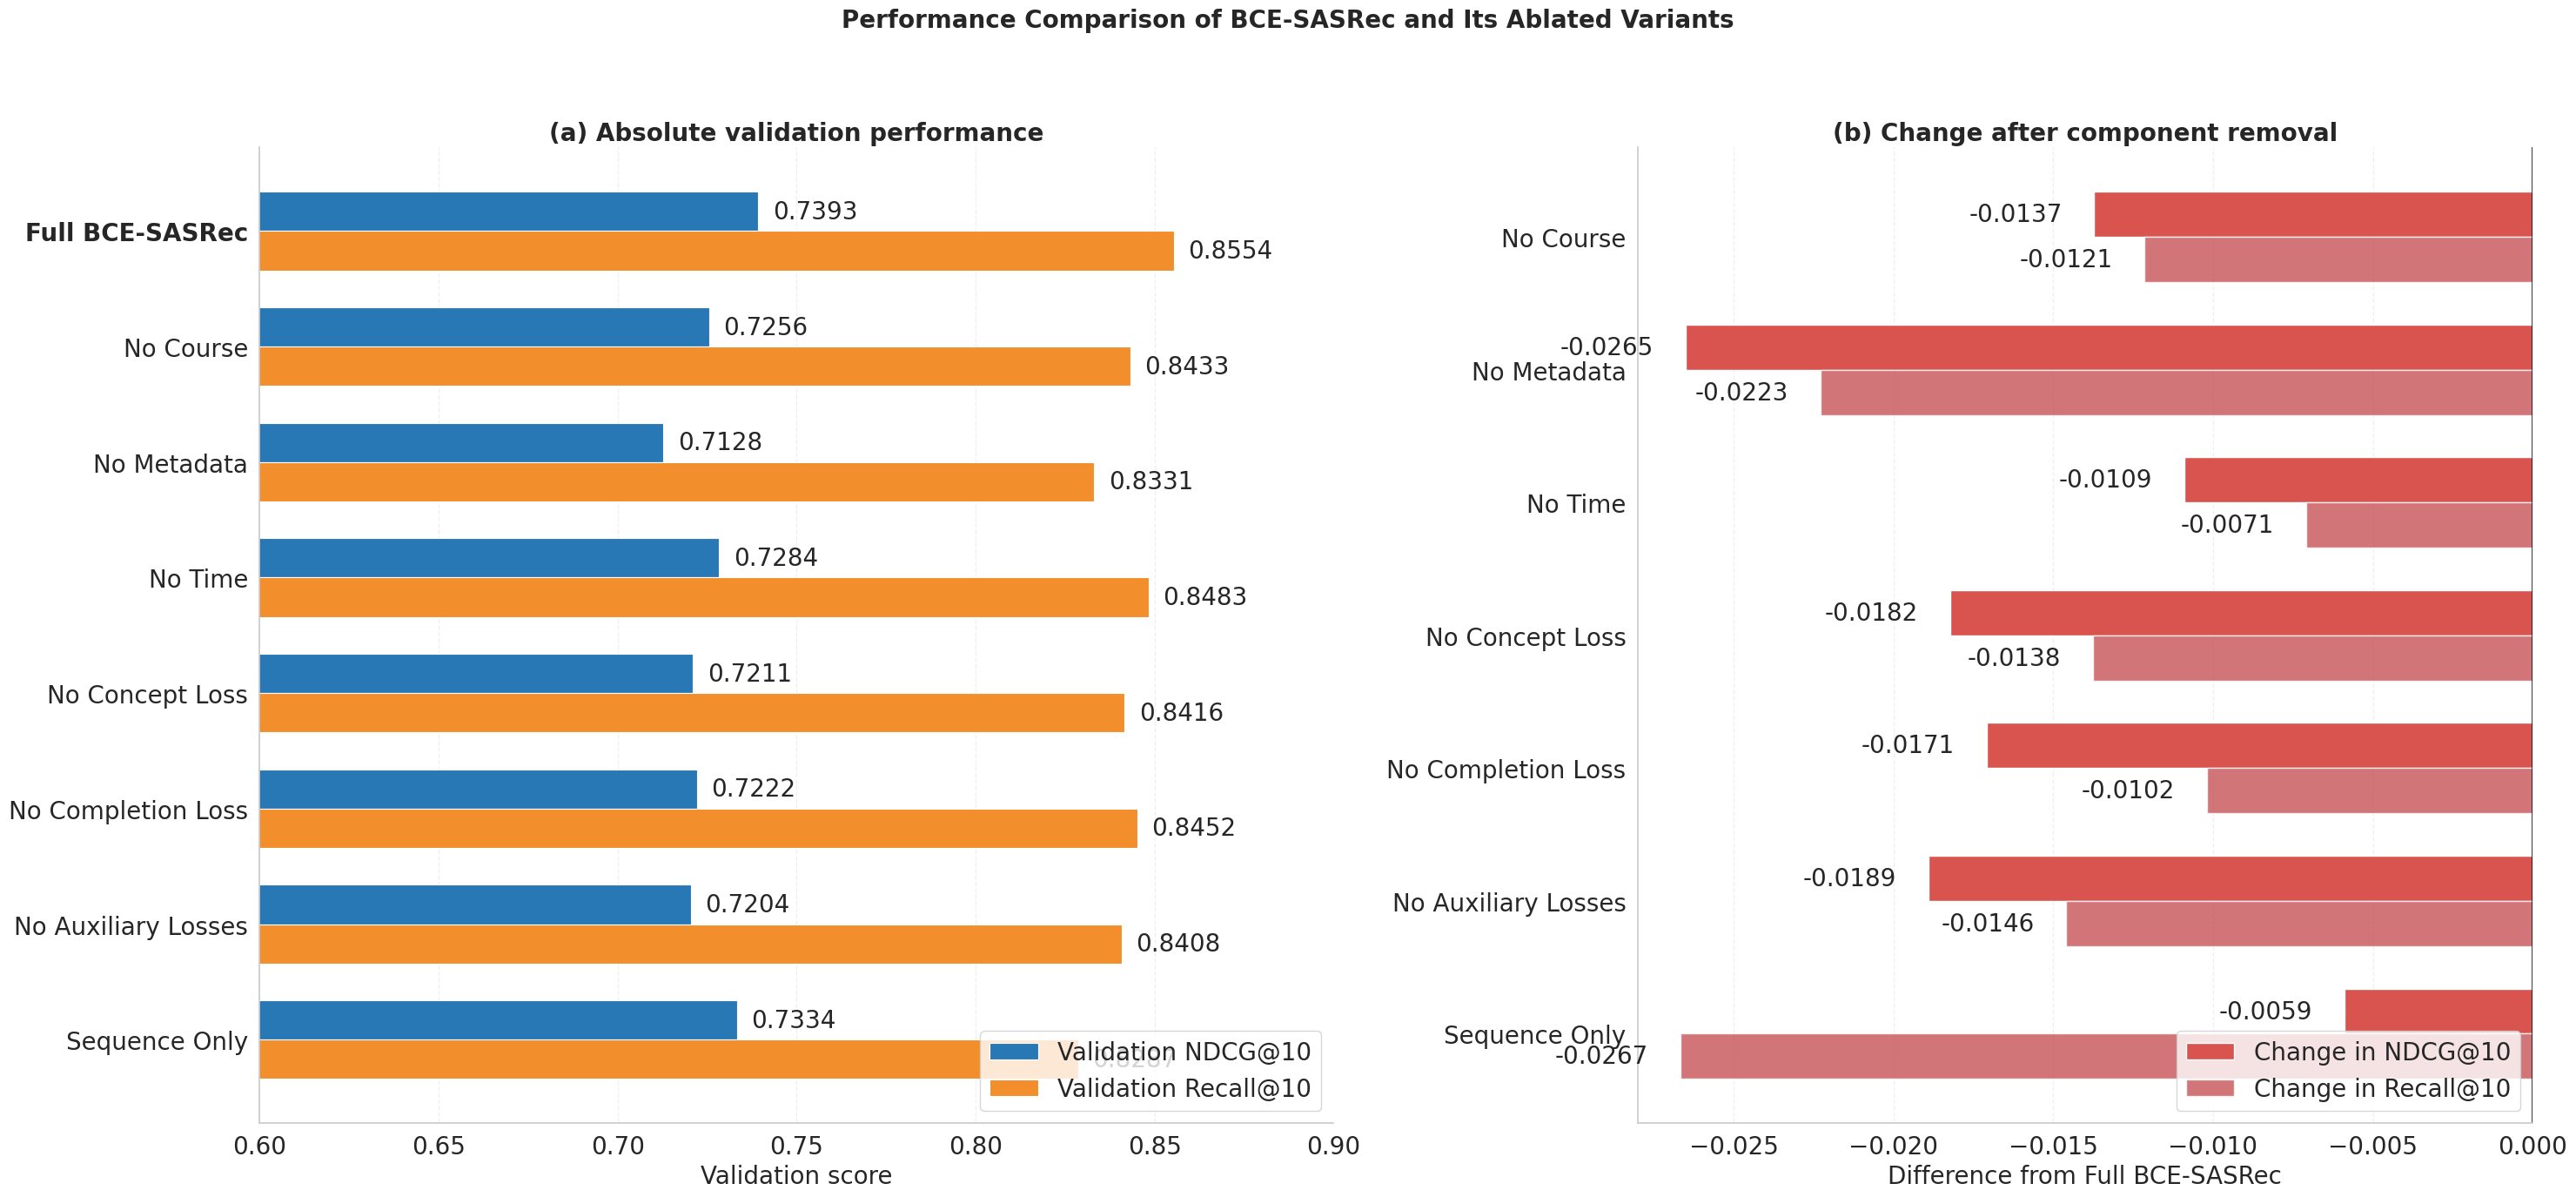


Saved files:
PNG: /kaggle/working/ablation_comparison/Figure_8_Ablation_Comparison.png
PDF: /kaggle/working/ablation_comparison/Figure_8_Ablation_Comparison.pdf
CSV: /kaggle/working/ablation_comparison/figure_8_ablation_values.csv


In [1]:
# ============================================================
# Figure 8: BCE-SASRec ablation performance comparison
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.0,
    rc={
        "font.family": "Times New Roman",
        "font.size": 20,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
        "figure.titlesize": 20,
    },
)

# Enforce exactly 20-point text for every Matplotlib text category.
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.titlesize": 20,
})

# ------------------------------------------------------------
# 1. Output location
# ------------------------------------------------------------

if Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/kaggle/working/ablation_comparison")
elif Path("/content/drive/MyDrive/DataCon").exists():
    OUTPUT_DIR = Path(
        "/content/drive/MyDrive/DataCon/ablation_comparison"
    )
else:
    OUTPUT_DIR = Path("./ablation_comparison")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Search for ablation result CSV files
# ------------------------------------------------------------

search_roots = [
    Path("/kaggle/working"),
    Path("/kaggle/input"),
    Path("/content/drive/MyDrive/DataCon"),
    Path("."),
]

candidate_files = []

for root in search_roots:
    if not root.exists():
        continue

    for pattern in [
        "*ablation*metrics*.csv",
        "*Ablation*metrics*.csv",
        "*ablation*results*.csv",
    ]:
        try:
            candidate_files.extend(root.rglob(pattern))
        except PermissionError:
            pass

candidate_files = list(dict.fromkeys(candidate_files))

print("Ablation files discovered:")

for path in candidate_files:
    print(" -", path)

# ------------------------------------------------------------
# 3. Load compatible result tables
# ------------------------------------------------------------

tables = []

for path in candidate_files:
    try:
        frame = pd.read_csv(path)

        normalized = {
            str(column).strip().lower().replace("_", "").replace(" ", ""):
            column
            for column in frame.columns
        }

        required_keys = ["variant", "ndcg@10", "recall@10"]

        if all(key in normalized for key in required_keys):
            rename_map = {
                normalized["variant"]: "Variant",
                normalized["ndcg@10"]: "NDCG@10",
                normalized["recall@10"]: "Recall@10",
            }

            if "split" in normalized:
                rename_map[normalized["split"]] = "Split"

            if "bestepoch" in normalized:
                rename_map[normalized["bestepoch"]] = "BestEpoch"

            if "seed" in normalized:
                rename_map[normalized["seed"]] = "Seed"

            selected = frame.rename(columns=rename_map)
            selected["SourceFile"] = str(path)
            tables.append(selected)

    except Exception as error:
        print(f"Skipped {path}: {error}")

if tables:
    raw_results = pd.concat(tables, ignore_index=True)
else:
    raw_results = pd.DataFrame()

# ------------------------------------------------------------
# 4. Retain validation results
# ------------------------------------------------------------

if not raw_results.empty:
    if "Split" in raw_results.columns:
        validation = raw_results[
            raw_results["Split"]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("validation")
        ].copy()
    else:
        validation = raw_results.copy()

    validation = validation[
        ["Variant", "NDCG@10", "Recall@10"]
    ].copy()

    validation["NDCG@10"] = pd.to_numeric(
        validation["NDCG@10"],
        errors="coerce"
    )
    validation["Recall@10"] = pd.to_numeric(
        validation["Recall@10"],
        errors="coerce"
    )

    validation = validation.dropna(
        subset=["NDCG@10", "Recall@10"]
    )
else:
    validation = pd.DataFrame(
        columns=["Variant", "NDCG@10", "Recall@10"]
    )

# ------------------------------------------------------------
# 5. Standardize variant names
# ------------------------------------------------------------

def clean_variant_name(value):
    name = str(value).strip()

    prefixes = [
        "Remaining_Ablation_",
        "Ablation_",
        "Remaining ",
    ]

    for prefix in prefixes:
        name = name.replace(prefix, "")

    name = name.replace("_", " ")

    replacements = {
        "Full BCE SASRec": "Full BCE-SASRec",
        "Full": "Full BCE-SASRec",
        "No Behaviour Features": "No Behaviour",
        "No Behavior": "No Behaviour",
        "No Concepts": "No Concept Features",
        "No Concept": "No Concept Features",
        "No Aux Losses": "No Auxiliary Losses",
    }

    return replacements.get(name, name)

if not validation.empty:
    validation["Variant"] = validation["Variant"].apply(
        clean_variant_name
    )

# ------------------------------------------------------------
# 6. Add fallback values when the first ablation file is absent
#
# These are the previously obtained validation results.
# Values from actual CSV files take priority.
# ------------------------------------------------------------

fallback_results = pd.DataFrame({
    "Variant": [
        "Full BCE-SASRec",
        "No Course",
        "No Metadata",
        "No Time",
        "No Concept Loss",
        "No Completion Loss",
        "No Auxiliary Losses",
        "Sequence Only",
    ],
    "NDCG@10": [
        0.7393,
        0.725578,
        0.712790,
        0.728391,
        0.721075,
        0.722211,
        0.720397,
        0.733404,
    ],
    "Recall@10": [
        0.8554,
        0.843254,
        0.833120,
        0.848321,
        0.841639,
        0.845203,
        0.840804,
        0.828721,
    ],
})

# Retain real CSV values and fill only missing variants.
if validation.empty:
    results = fallback_results.copy()
else:
    validation = validation.drop_duplicates(
        subset=["Variant"],
        keep="last"
    )

    missing_fallback = fallback_results[
        ~fallback_results["Variant"].isin(
            validation["Variant"]
        )
    ]

    results = pd.concat(
        [validation, missing_fallback],
        ignore_index=True
    )

# ------------------------------------------------------------
# 7. Arrange variants in a meaningful order
# ------------------------------------------------------------

variant_order = [
    "Full BCE-SASRec",
    "No Behaviour",
    "No Concept Features",
    "No Course",
    "No Metadata",
    "No Time",
    "No Concept Loss",
    "No Completion Loss",
    "No Auxiliary Losses",
    "Sequence Only",
]

results = results[
    results["Variant"].isin(variant_order)
].copy()

results["Variant"] = pd.Categorical(
    results["Variant"],
    categories=variant_order,
    ordered=True,
)

results = (
    results
    .sort_values("Variant")
    .reset_index(drop=True)
)

print("\nValidation ablation results:")
display(results)

# Save the exact data used by the graph.
results.to_csv(
    OUTPUT_DIR / "figure_8_ablation_values.csv",
    index=False
)

# ------------------------------------------------------------
# 8. Calculate changes relative to the complete model
# ------------------------------------------------------------

full_model = results[
    results["Variant"] == "Full BCE-SASRec"
].iloc[0]

results["Delta_NDCG@10"] = (
    results["NDCG@10"] -
    full_model["NDCG@10"]
)

results["Delta_Recall@10"] = (
    results["Recall@10"] -
    full_model["Recall@10"]
)

# ------------------------------------------------------------
# 9. Create publication-quality comparison graph
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(30, 14),
    gridspec_kw={"width_ratios": [1.2, 1.0]}
)

positions = np.arange(len(results))
bar_height = 0.34

# Colors
ndcg_color = "#2878B5"
recall_color = "#F28E2B"

# ------------------------------------------------------------
# Panel A: absolute validation performance
# ------------------------------------------------------------

bars_ndcg = axes[0].barh(
    positions - bar_height / 2,
    results["NDCG@10"],
    height=bar_height,
    color=ndcg_color,
    edgecolor="white",
    linewidth=0.8,
    label="Validation NDCG@10",
)

bars_recall = axes[0].barh(
    positions + bar_height / 2,
    results["Recall@10"],
    height=bar_height,
    color=recall_color,
    edgecolor="white",
    linewidth=0.8,
    label="Validation Recall@10",
)

axes[0].set_yticks(positions)
axes[0].set_yticklabels(results["Variant"])
axes[0].invert_yaxis()
axes[0].set_xlim(0.60, 0.90)
axes[0].set_xlabel("Validation score")
axes[0].set_title(
    "(a) Absolute validation performance",
    fontweight="bold"
)
axes[0].legend(
    loc="lower right",
    frameon=True
)

# Add values to bars.
for bars in [bars_ndcg, bars_recall]:
    for bar in bars:
        value = bar.get_width()

        axes[0].text(
            value + 0.004,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            ha="left",
            fontsize=20,
        )

# Emphasize the full model.
axes[0].get_yticklabels()[0].set_fontweight("bold")

# ------------------------------------------------------------
# Panel B: changes relative to complete BCE-SASRec
# ------------------------------------------------------------

ablated = results[
    results["Variant"] != "Full BCE-SASRec"
].reset_index(drop=True)

delta_positions = np.arange(len(ablated))

ndcg_delta_colors = [
    "#2E8B57" if value >= 0 else "#D9534F"
    for value in ablated["Delta_NDCG@10"]
]

recall_delta_colors = [
    "#55A868" if value >= 0 else "#C44E52"
    for value in ablated["Delta_Recall@10"]
]

bars_delta_ndcg = axes[1].barh(
    delta_positions - bar_height / 2,
    ablated["Delta_NDCG@10"],
    height=bar_height,
    color=ndcg_delta_colors,
    edgecolor="white",
    label="Change in NDCG@10",
)

bars_delta_recall = axes[1].barh(
    delta_positions + bar_height / 2,
    ablated["Delta_Recall@10"],
    height=bar_height,
    color=recall_delta_colors,
    edgecolor="white",
    alpha=0.78,
    label="Change in Recall@10",
)

axes[1].axvline(
    0,
    color="black",
    linewidth=1.1
)

axes[1].set_yticks(delta_positions)
axes[1].set_yticklabels(ablated["Variant"])
axes[1].invert_yaxis()
axes[1].set_xlabel("Difference from Full BCE-SASRec")
axes[1].set_title(
    "(b) Change after component removal",
    fontweight="bold"
)
axes[1].legend(
    loc="lower right",
    frameon=True
)

# Add signed values.
for bars in [bars_delta_ndcg, bars_delta_recall]:
    for bar in bars:
        value = bar.get_width()

        offset = 0.0010 if value >= 0 else -0.0010
        alignment = "left" if value >= 0 else "right"

        axes[1].text(
            value + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:+.4f}",
            va="center",
            ha=alignment,
            fontsize=20,
        )

# ------------------------------------------------------------
# 10. Final formatting
# ------------------------------------------------------------

fig.suptitle(
    "Performance Comparison of BCE-SASRec and Its Ablated Variants",
    fontsize=20,
    fontweight="bold",
    y=0.99,
)

for axis in axes:
    axis.grid(
        axis="x",
        linestyle="--",
        alpha=0.30
    )
    axis.grid(
        axis="y",
        visible=False
    )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])

png_path = OUTPUT_DIR / "Figure_8_Ablation_Comparison.png"
pdf_path = OUTPUT_DIR / "Figure_8_Ablation_Comparison.pdf"

plt.savefig(
    png_path,
    dpi=400,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\nSaved files:")
print("PNG:", png_path)
print("PDF:", pdf_path)
print(
    "CSV:",
    OUTPUT_DIR / "figure_8_ablation_values.csv"
)


In [2]:
# ============================================================
# Figure 9: Explainable concept-map visualization
# ============================================================

from pathlib import Path
import ast
import json
import textwrap

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

# ------------------------------------------------------------
# 1. Locate processed data and model outputs
# ------------------------------------------------------------

SEARCH_ROOTS = [
    Path("/kaggle/working"),
    Path("/kaggle/input"),
    Path("/content/drive/MyDrive/DataCon"),
    Path("."),
]

OUTPUT_DIR = None

if Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/kaggle/working/concept_map")
elif Path("/content/drive/MyDrive/DataCon").exists():
    OUTPUT_DIR = Path(
        "/content/drive/MyDrive/DataCon/concept_map"
    )
else:
    OUTPUT_DIR = Path("./concept_map")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def find_file(names, required=True):
    """Find the first file matching any supplied name or pattern."""

    matches = []

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue

        for name in names:
            try:
                matches.extend(root.rglob(name))
            except PermissionError:
                pass

    matches = list(dict.fromkeys(matches))

    if not matches:
        if required:
            raise FileNotFoundError(
                "Could not find any of these files:\n" +
                "\n".join(names)
            )
        return None

    # Prefer working-directory outputs over input copies.
    matches.sort(
        key=lambda path: (
            0 if "/working/" in path.as_posix() else 1,
            len(path.as_posix())
        )
    )

    print("Selected:", matches[0])
    return matches[0]


TRAIN_FILE = find_file([
    "processed/splits/train.parquet",
    "splits/train.parquet",
    "train.parquet",
])

CONCEPT_EDGE_FILE = find_file([
    "processed/graph/concept_video_edges.parquet",
    "graph/concept_video_edges.parquet",
    "concept_video_edges.parquet",
])

COURSE_EDGE_FILE = find_file([
    "processed/graph/course_video_edges.parquet",
    "graph/course_video_edges.parquet",
    "course_video_edges.parquet",
], required=False)

VIDEO_METADATA_FILE = find_file([
    "processed/graph/video_metadata.parquet",
    "graph/video_metadata.parquet",
    "video_metadata.parquet",
    "video_index.parquet",
], required=False)

# The evaluation notebook may use any of these names.
RECOMMENDATION_FILE = find_file([
    "*test*top10*.csv",
    "*test*top_10*.csv",
    "*test*recommendations*.csv",
    "*recommendation*examples*.csv",
    "*top10*.parquet",
    "*recommendations*.parquet",
])

# Optional prerequisite output generated during preprocessing.
PREREQUISITE_FILE = find_file([
    "*prerequisite*edges*.parquet",
    "*concept*prerequisite*.parquet",
    "*prerequisites*.csv",
], required=False)

# ------------------------------------------------------------
# 2. Utility functions
# ------------------------------------------------------------

def read_table(path):
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)

    raise ValueError(f"Unsupported file type: {path}")


def find_column(frame, candidates, required=True):
    normalized = {
        str(column).lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", ""): column
        for column in frame.columns
    }

    for candidate in candidates:
        key = (
            candidate.lower()
            .replace("_", "")
            .replace("-", "")
            .replace(" ", "")
        )

        if key in normalized:
            return normalized[key]

    if required:
        raise KeyError(
            f"Could not find one of {candidates}. "
            f"Columns are: {frame.columns.tolist()}"
        )

    return None


def short_text(value, width=24):
    text = str(value)

    if len(text) <= width:
        return text

    return text[:width - 1] + "…"


def parse_list(value):
    """Convert a saved list, JSON list or scalar into a Python list."""

    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)

    if pd.isna(value):
        return []

    text = str(value).strip()

    try:
        parsed = json.loads(text)

        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass

    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, (list, tuple)):
            return list(parsed)
    except Exception:
        pass

    if "," in text:
        return [
            item.strip()
            for item in text.split(",")
            if item.strip()
        ]

    return [value]


# ------------------------------------------------------------
# 3. Load processed relations
# ------------------------------------------------------------

train = read_table(TRAIN_FILE)
concept_edges = read_table(CONCEPT_EDGE_FILE)

course_edges = (
    read_table(COURSE_EDGE_FILE)
    if COURSE_EDGE_FILE else pd.DataFrame()
)

video_metadata = (
    read_table(VIDEO_METADATA_FILE)
    if VIDEO_METADATA_FILE else pd.DataFrame()
)

recommendation_data = read_table(RECOMMENDATION_FILE)

prerequisites = (
    read_table(PREREQUISITE_FILE)
    if PREREQUISITE_FILE else pd.DataFrame()
)

print("\nRecommendation columns:")
print(recommendation_data.columns.tolist())

# ------------------------------------------------------------
# 4. Normalize train interaction columns
# ------------------------------------------------------------

train_user_col = find_column(
    train,
    ["user_id", "user", "uid"]
)

train_video_col = find_column(
    train,
    ["video_id", "video", "item_id", "item"]
)

train_time_col = find_column(
    train,
    ["timestamp", "time", "last_timestamp"],
    required=False
)

train = train.rename(columns={
    train_user_col: "user_id",
    train_video_col: "video_id",
})

train["user_id"] = train["user_id"].astype(str)
train["video_id"] = train["video_id"].astype(str)

if train_time_col:
    train = train.rename(
        columns={train_time_col: "timestamp"}
    )
else:
    train["timestamp"] = np.arange(len(train))

# ------------------------------------------------------------
# 5. Convert recommendation output to long format
# ------------------------------------------------------------

rec_user_col = find_column(
    recommendation_data,
    ["user_id", "user", "uid"]
)

recommendation_data = recommendation_data.rename(
    columns={rec_user_col: "user_id"}
)

recommendation_data["user_id"] = (
    recommendation_data["user_id"].astype(str)
)

rec_video_col = find_column(
    recommendation_data,
    ["video_id", "recommended_video", "item_id"],
    required=False
)

rank_col = find_column(
    recommendation_data,
    ["rank", "position"],
    required=False
)

score_col = find_column(
    recommendation_data,
    ["score", "ranking_score", "prediction"],
    required=False
)

# Long-format recommendation table.
if rec_video_col:
    rename_map = {rec_video_col: "video_id"}

    if rank_col:
        rename_map[rank_col] = "rank"

    if score_col:
        rename_map[score_col] = "score"

    recs = recommendation_data.rename(
        columns=rename_map
    ).copy()

    recs["video_id"] = recs["video_id"].astype(str)

    if "rank" not in recs:
        recs["rank"] = (
            recs.groupby("user_id").cumcount() + 1
        )

# A list stored in a top10 or recommendations column.
else:
    list_col = find_column(
        recommendation_data,
        [
            "top10",
            "top_10",
            "recommendations",
            "recommended_items",
            "top_items",
        ]
    )

    expanded_rows = []

    for _, row in recommendation_data.iterrows():
        videos = parse_list(row[list_col])

        for rank, video_id in enumerate(videos, start=1):
            expanded_rows.append({
                "user_id": str(row["user_id"]),
                "video_id": str(video_id),
                "rank": rank,
            })

    recs = pd.DataFrame(expanded_rows)

recs = recs.sort_values(["user_id", "rank"])

# ------------------------------------------------------------
# 6. Normalize concept-video edges
# ------------------------------------------------------------

concept_video_col = find_column(
    concept_edges,
    ["video_id", "video", "item_id"]
)

concept_col = find_column(
    concept_edges,
    ["concept_id", "concept", "knowledge_id"]
)

concept_edges = concept_edges.rename(columns={
    concept_video_col: "video_id",
    concept_col: "concept_id",
})

concept_edges["video_id"] = (
    concept_edges["video_id"].astype(str)
)

concept_edges["concept_id"] = (
    concept_edges["concept_id"].astype(str)
)

# ------------------------------------------------------------
# 7. Normalize course-video edges
# ------------------------------------------------------------

if not course_edges.empty:
    course_video_col = find_column(
        course_edges,
        ["video_id", "video", "item_id"]
    )

    course_col = find_column(
        course_edges,
        ["course_id", "course"]
    )

    course_edges = course_edges.rename(columns={
        course_video_col: "video_id",
        course_col: "course_id",
    })

    course_edges["video_id"] = (
        course_edges["video_id"].astype(str)
    )

    course_edges["course_id"] = (
        course_edges["course_id"].astype(str)
    )

# ------------------------------------------------------------
# 8. Create readable video labels
# ------------------------------------------------------------

video_label_map = {}

if not video_metadata.empty:
    metadata_video_col = find_column(
        video_metadata,
        ["video_id", "video", "item_id"],
        required=False
    )

    title_col = find_column(
        video_metadata,
        [
            "title",
            "video_title",
            "name",
            "caption",
            "text",
        ],
        required=False
    )

    if metadata_video_col and title_col:
        temp = video_metadata[
            [metadata_video_col, title_col]
        ].dropna()

        video_label_map = dict(zip(
            temp[metadata_video_col].astype(str),
            temp[title_col].astype(str),
        ))


def video_label(video_id):
    title = video_label_map.get(str(video_id))

    if title:
        return short_text(title, 26)

    return "Video " + short_text(video_id, 15)


def concept_label(concept_id):
    return "Concept " + short_text(concept_id, 13)


# ------------------------------------------------------------
# 9. Select a learner with sufficient evidence
# ------------------------------------------------------------

user_history_counts = (
    train.groupby("user_id")
    .size()
    .rename("history_count")
)

user_rec_counts = (
    recs.groupby("user_id")
    .size()
    .rename("recommendation_count")
)

eligible_users = (
    pd.concat(
        [user_history_counts, user_rec_counts],
        axis=1,
        join="inner",
    )
    .fillna(0)
)

eligible_users = eligible_users[
    (eligible_users["history_count"] >= 3) &
    (eligible_users["recommendation_count"] >= 5)
]

if eligible_users.empty:
    raise RuntimeError(
        "No user has at least three historical videos "
        "and five saved recommendations."
    )

# Prefer a user whose videos have many concept connections.
candidate_users = eligible_users.sort_values(
    ["recommendation_count", "history_count"],
    ascending=False,
).head(100).index

best_user = None
best_coverage = -1

for user_id in candidate_users:
    user_recs = (
        recs[recs["user_id"] == user_id]
        .sort_values("rank")
        .head(5)["video_id"]
        .tolist()
    )

    coverage = concept_edges[
        concept_edges["video_id"].isin(user_recs)
    ]["concept_id"].nunique()

    if coverage > best_coverage:
        best_coverage = coverage
        best_user = user_id

SELECTED_USER = str(best_user)

print("\nSelected learner:", SELECTED_USER)
print("Connected recommendation concepts:", best_coverage)

# ------------------------------------------------------------
# 10. Obtain recent videos and top recommendations
# ------------------------------------------------------------

recent_videos = (
    train[train["user_id"] == SELECTED_USER]
    .sort_values("timestamp")
    .tail(3)["video_id"]
    .astype(str)
    .tolist()
)

top_recommendations = (
    recs[recs["user_id"] == SELECTED_USER]
    .sort_values("rank")
    .head(5)
    .copy()
)

recommended_videos = (
    top_recommendations["video_id"]
    .astype(str)
    .tolist()
)

# Limit concept count for readable visualization.
recent_concepts = (
    concept_edges[
        concept_edges["video_id"].isin(recent_videos)
    ]
    .groupby("concept_id")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
    .astype(str)
    .tolist()
)

recommended_concepts = (
    concept_edges[
        concept_edges["video_id"].isin(
            recommended_videos
        )
    ]
    .groupby("concept_id")
    .size()
    .sort_values(ascending=False)
    .head(6)
    .index
    .astype(str)
    .tolist()
)

selected_concepts = list(dict.fromkeys(
    recent_concepts + recommended_concepts
))[:8]

# ------------------------------------------------------------
# 11. Optional prerequisite relations
# ------------------------------------------------------------

prerequisite_pairs = []

if not prerequisites.empty:
    source_col = find_column(
        prerequisites,
        [
            "source_concept",
            "prerequisite_id",
            "source",
            "prerequisite",
        ],
        required=False
    )

    target_col = find_column(
        prerequisites,
        [
            "target_concept",
            "concept_id",
            "target",
            "dependent_concept",
        ],
        required=False
    )

    if source_col and target_col:
        prereq_temp = prerequisites.rename(columns={
            source_col: "source_concept",
            target_col: "target_concept",
        })

        prereq_temp["source_concept"] = (
            prereq_temp["source_concept"].astype(str)
        )
        prereq_temp["target_concept"] = (
            prereq_temp["target_concept"].astype(str)
        )

        prereq_temp = prereq_temp[
            prereq_temp["source_concept"].isin(
                selected_concepts
            ) |
            prereq_temp["target_concept"].isin(
                selected_concepts
            )
        ].head(4)

        prerequisite_pairs = list(zip(
            prereq_temp["source_concept"],
            prereq_temp["target_concept"],
        ))

# ------------------------------------------------------------
# 12. Build the explanation graph
# ------------------------------------------------------------

G = nx.DiGraph()

learner_node = f"learner::{SELECTED_USER}"

G.add_node(
    learner_node,
    node_type="learner",
    label="Learner\n" + short_text(SELECTED_USER, 12),
)

# Recent-history nodes.
for index, video_id in enumerate(recent_videos, start=1):
    node = f"history::{video_id}"

    G.add_node(
        node,
        node_type="history",
        label=f"Recent video {index}\n{video_label(video_id)}",
    )

    G.add_edge(
        learner_node,
        node,
        relation="watched",
    )

# Concept nodes.
for concept_id in selected_concepts:
    node = f"concept::{concept_id}"

    G.add_node(
        node,
        node_type="concept",
        label=concept_label(concept_id),
    )

# Recent video-to-concept edges.
recent_edge_data = concept_edges[
    concept_edges["video_id"].isin(recent_videos) &
    concept_edges["concept_id"].isin(selected_concepts)
]

for _, row in recent_edge_data.iterrows():
    G.add_edge(
        f"history::{row['video_id']}",
        f"concept::{row['concept_id']}",
        relation="covers",
    )

# Recommended video nodes.
for _, row in top_recommendations.iterrows():
    video_id = str(row["video_id"])
    rank = int(row["rank"])
    node = f"recommended::{video_id}"

    score_text = ""

    if "score" in row and pd.notna(row["score"]):
        score_text = f"\nScore: {float(row['score']):.3f}"

    G.add_node(
        node,
        node_type="recommended",
        label=(
            f"Recommendation {rank}\n"
            f"{video_label(video_id)}"
            f"{score_text}"
        ),
    )

# Concept-to-recommended-video edges.
recommended_edge_data = concept_edges[
    concept_edges["video_id"].isin(
        recommended_videos
    ) &
    concept_edges["concept_id"].isin(
        selected_concepts
    )
]

for _, row in recommended_edge_data.iterrows():
    G.add_edge(
        f"concept::{row['concept_id']}",
        f"recommended::{row['video_id']}",
        relation="supports",
    )

# Course nodes and course-membership edges.
if not course_edges.empty:
    selected_course_edges = course_edges[
        course_edges["video_id"].isin(
            recommended_videos
        )
    ]

    # Keep at most three course nodes.
    selected_courses = (
        selected_course_edges["course_id"]
        .drop_duplicates()
        .head(3)
        .tolist()
    )

    for course_id in selected_courses:
        course_node = f"course::{course_id}"

        G.add_node(
            course_node,
            node_type="course",
            label="Course\n" + short_text(course_id, 13),
        )

    for _, row in selected_course_edges.iterrows():
        course_id = str(row["course_id"])
        video_id = str(row["video_id"])

        if course_id in selected_courses:
            G.add_edge(
                f"course::{course_id}",
                f"recommended::{video_id}",
                relation="contains",
            )

# Prerequisite nodes and relations.
for source_concept, target_concept in prerequisite_pairs:
    source_node = f"concept::{source_concept}"
    target_node = f"prerequisite::{target_concept}"

    if source_node not in G:
        G.add_node(
            source_node,
            node_type="concept",
            label=concept_label(source_concept),
        )

    G.add_node(
        target_node,
        node_type="prerequisite",
        label=(
            "Prerequisite\n" +
            short_text(target_concept, 13)
        ),
    )

    G.add_edge(
        source_node,
        target_node,
        relation="prerequisite",
    )

if len(G.nodes) == 1:
    raise RuntimeError(
        "The selected learner produced no graph relations."
    )

# ------------------------------------------------------------
# 13. Create fixed layered positions
# ------------------------------------------------------------

positions = {}

positions[learner_node] = (0.0, 0.5)


def vertical_positions(nodes, x, low=0.08, high=0.92):
    nodes = list(nodes)

    if not nodes:
        return

    values = np.linspace(high, low, len(nodes))

    for node, y in zip(nodes, values):
        positions[node] = (x, float(y))


history_nodes = [
    node for node, data in G.nodes(data=True)
    if data["node_type"] == "history"
]

concept_nodes = [
    node for node, data in G.nodes(data=True)
    if data["node_type"] == "concept"
]

prerequisite_nodes = [
    node for node, data in G.nodes(data=True)
    if data["node_type"] == "prerequisite"
]

course_nodes = [
    node for node, data in G.nodes(data=True)
    if data["node_type"] == "course"
]

recommended_nodes = [
    node for node, data in G.nodes(data=True)
    if data["node_type"] == "recommended"
]

vertical_positions(history_nodes, 1.6)
vertical_positions(concept_nodes, 3.3)
vertical_positions(prerequisite_nodes, 4.8)
vertical_positions(course_nodes, 4.8, low=0.60, high=0.90)
vertical_positions(recommended_nodes, 6.4)

# ------------------------------------------------------------
# 14. Draw publication-quality concept map
# ------------------------------------------------------------

node_style = {
    "learner": {
        "color": "#1F5AA6",
        "size": 3600,
        "shape": "o",
    },
    "history": {
        "color": "#43A8D5",
        "size": 4300,
        "shape": "s",
    },
    "concept": {
        "color": "#46A66A",
        "size": 3600,
        "shape": "o",
    },
    "prerequisite": {
        "color": "#F1A340",
        "size": 3900,
        "shape": "h",
    },
    "course": {
        "color": "#A078C5",
        "size": 3900,
        "shape": "D",
    },
    "recommended": {
        "color": "#E65C75",
        "size": 4600,
        "shape": "s",
    },
}

edge_style = {
    "watched": {
        "color": "#2878B5",
        "style": "solid",
        "width": 2.2,
    },
    "covers": {
        "color": "#2E9D63",
        "style": "solid",
        "width": 1.8,
    },
    "supports": {
        "color": "#D64F68",
        "style": "solid",
        "width": 1.8,
    },
    "prerequisite": {
        "color": "#ED8B24",
        "style": "dashed",
        "width": 2.0,
    },
    "contains": {
        "color": "#8B63B5",
        "style": "dotted",
        "width": 1.8,
    },
}

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_facecolor("#FAFCFF")

# Draw nodes by node type.
for node_type, style in node_style.items():
    node_list = [
        node for node, data in G.nodes(data=True)
        if data["node_type"] == node_type
    ]

    if not node_list:
        continue

    nx.draw_networkx_nodes(
        G,
        positions,
        nodelist=node_list,
        node_color=style["color"],
        node_size=style["size"],
        node_shape=style["shape"],
        edgecolors="white",
        linewidths=2.0,
        alpha=0.97,
        ax=ax,
    )

# Draw edges by relation.
for relation, style in edge_style.items():
    relation_edges = [
        (source, target)
        for source, target, data in G.edges(data=True)
        if data["relation"] == relation
    ]

    if not relation_edges:
        continue

    nx.draw_networkx_edges(
        G,
        positions,
        edgelist=relation_edges,
        edge_color=style["color"],
        style=style["style"],
        width=style["width"],
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        connectionstyle="arc3,rad=0.05",
        min_source_margin=20,
        min_target_margin=20,
        alpha=0.90,
        ax=ax,
    )

# Draw readable labels.
labels = {
    node: data["label"]
    for node, data in G.nodes(data=True)
}

nx.draw_networkx_labels(
    G,
    positions,
    labels=labels,
    font_size=8.2,
    font_color="white",
    font_weight="bold",
    ax=ax,
)

# Draw selected edge labels only once per relationship path.
edge_labels = {}

for source, target, data in G.edges(data=True):
    relation = data["relation"]

    if relation in {
        "watched",
        "covers",
        "supports",
        "prerequisite",
        "contains",
    }:
        edge_labels[(source, target)] = relation

nx.draw_networkx_edge_labels(
    G,
    positions,
    edge_labels=edge_labels,
    font_size=7,
    font_color="#34495E",
    rotate=False,
    label_pos=0.5,
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.80,
        "pad": 1.5,
    },
    ax=ax,
)

# Column headings.
column_headings = [
    (0.0, "Learner"),
    (1.6, "Recent History"),
    (3.3, "Covered Concepts"),
    (4.8, "Prerequisites / Courses"),
    (6.4, "Recommended Videos"),
]

for x, heading in column_headings:
    ax.text(
        x,
        1.04,
        heading,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="#17365D",
    )

# Node legend.
node_legend = [
    Line2D(
        [0], [0],
        marker=node_style[node_type]["shape"],
        color="none",
        markerfacecolor=node_style[node_type]["color"],
        markeredgecolor="white",
        markersize=11,
        label=node_type.replace("_", " ").title(),
    )
    for node_type in node_style
    if any(
        data["node_type"] == node_type
        for _, data in G.nodes(data=True)
    )
]

# Edge legend.
edge_legend = [
    Line2D(
        [0], [0],
        color=style["color"],
        linewidth=style["width"],
        linestyle=style["style"],
        label=relation.title(),
    )
    for relation, style in edge_style.items()
    if any(
        data["relation"] == relation
        for _, _, data in G.edges(data=True)
    )
]

legend_one = ax.legend(
    handles=node_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=min(6, len(node_legend)),
    frameon=True,
    title="Node types",
)

ax.add_artist(legend_one)

ax.legend(
    handles=edge_legend,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=min(5, len(edge_legend)),
    frameon=True,
    title="Relationship types",
)

ax.set_title(
    "Concept-Map Explanation for Personalized Educational "
    "Short-Video Recommendations",
    fontsize=17,
    fontweight="bold",
    color="#17365D",
    pad=28,
)

ax.text(
    0.5,
    0.985,
    (
        f"Learner {short_text(SELECTED_USER, 18)}: "
        "recent interactions, educational concepts, "
        "prerequisites and ranked recommendations"
    ),
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10,
    color="#58677C",
)

ax.set_xlim(-0.65, 7.05)
ax.set_ylim(-0.15, 1.12)
ax.axis("off")

plt.tight_layout(rect=[0, 0.14, 1, 0.96])

png_path = OUTPUT_DIR / "Figure_9_Concept_Map.png"
pdf_path = OUTPUT_DIR / "Figure_9_Concept_Map.pdf"

plt.savefig(
    png_path,
    dpi=400,
    bbox_inches="tight",
    facecolor="white",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("\nSaved:")
print("PNG:", png_path)
print("PDF:", pdf_path)

Selected: /kaggle/input/datasets/kabil908/processed/processed/splits/train.parquet
Selected: /kaggle/input/datasets/kabil908/processed/processed/graph/concept_video_edges.parquet
Selected: /kaggle/input/datasets/kabil908/processed/processed/graph/course_video_edges.parquet
Selected: /kaggle/input/datasets/kabil908/processed/processed/graph/video_index.parquet


FileNotFoundError: Could not find any of these files:
*test*top10*.csv
*test*top_10*.csv
*test*recommendations*.csv
*recommendation*examples*.csv
*top10*.parquet
*recommendations*.parquet

In [3]:
# Save model recommendations for Figure 9.
recommendation_rows = []

for user_id, video_ids in test_top10.items():
    for rank, video_id in enumerate(video_ids, start=1):
        recommendation_rows.append({
            "user_id": str(user_id),
            "video_id": str(video_id),
            "rank": rank,
        })

pd.DataFrame(recommendation_rows).to_csv(
    "/kaggle/working/test_top10_recommendations.csv",
    index=False,
)

print(
    "Saved:",
    "/kaggle/working/test_top10_recommendations.csv"
)

NameError: name 'test_top10' is not defined

In [4]:
from pathlib import Path
import pandas as pd
import torch

# Select the output folder used by the model.
if Path("/kaggle/working").exists():
    REPORTS = Path(
        "/kaggle/working/bce_sasrec_concept_map"
    )
else:
    REPORTS = Path(
        "/content/drive/MyDrive/DataCon/"
        "bce_sasrec_concept_map"
    )

REPORTS.mkdir(parents=True, exist_ok=True)

required_variables = [
    "model",
    "evaluate",
    "test_hist",
    "test_target",
    "test_completion",
    "eval_users",
    "idx2user",
    "idx2item",
    "device",
]

missing = [
    name for name in required_variables
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "The model session is not ready. Missing variables:\n" +
        "\n".join(f" - {name}" for name in missing) +
        "\n\nRun the notebook from the data-loading cells "
        "through the model and evaluate() definitions first."
    )

# ------------------------------------------------------------
# Find and restore the best checkpoint
# ------------------------------------------------------------

checkpoint_candidates = []

search_roots = [
    Path("/kaggle/working"),
    Path("/kaggle/input"),
    Path("/content/drive/MyDrive/DataCon"),
]

for root in search_roots:
    if root.exists():
        checkpoint_candidates.extend(
            root.rglob("*BCE*SASRec*best.pt")
        )

if not checkpoint_candidates:
    raise FileNotFoundError(
        "No BCE-SASRec best checkpoint was found. "
        "Upload the proposed-model output ZIP as a Kaggle "
        "input or run the training notebook."
    )

# Prefer seed 42 for the example explanation.
seed_42 = [
    path for path in checkpoint_candidates
    if "seed_42" in path.name.lower()
]

checkpoint_path = (
    seed_42[0]
    if seed_42
    else checkpoint_candidates[0]
)

print("Checkpoint:", checkpoint_path)

saved = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(saved["model_state"])
model.eval()

print(
    "Restored best epoch:",
    saved.get("epoch", "not recorded")
)

# ------------------------------------------------------------
# Evaluate and obtain actual Top-10 predictions
# ------------------------------------------------------------

test_metrics, test_ranks, test_top10 = evaluate(
    model,
    test_hist,
    test_target,
    test_completion,
    eval_users,
    "Generating Top-10 recommendations",
)

print("Users evaluated:", len(eval_users))
print("Recommendation lists:", len(test_top10))

# ------------------------------------------------------------
# Convert internal indices back to original MOOCCubeX IDs
# ------------------------------------------------------------

recommendation_rows = []

for internal_user, recommended_items in zip(
    eval_users,
    test_top10,
):
    original_user = str(idx2user[internal_user])

    actual_internal_item = test_target[internal_user]
    actual_video = str(idx2item[actual_internal_item])

    row = {
        "user_id": original_user,
        "actual_video_id": actual_video,
    }

    for rank, internal_item in enumerate(
        recommended_items,
        start=1,
    ):
        row[f"rank_{rank}"] = str(
            idx2item[internal_item]
        )

    recommendation_rows.append(row)

recommendations_df = pd.DataFrame(
    recommendation_rows
)

RECOMMENDATION_FILE = (
    REPORTS /
    "test_top10_recommendations.parquet"
)

recommendations_df.to_parquet(
    RECOMMENDATION_FILE,
    index=False,
)

# Also save CSV for easy inspection.
recommendations_df.to_csv(
    REPORTS /
    "test_top10_recommendations.csv",
    index=False,
)

display(recommendations_df.head())

print("\nSaved recommendation file:")
print(RECOMMENDATION_FILE)

RuntimeError: The model session is not ready. Missing variables:
 - model
 - evaluate
 - test_hist
 - test_target
 - test_completion
 - eval_users
 - idx2user
 - idx2item
 - device

Run the notebook from the data-loading cells through the model and evaluate() definitions first.

In [6]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

# ------------------------------------------------------------
# Locate the attached model directory
# ------------------------------------------------------------

model_directories = [
    path
    for path in INPUT_ROOT.rglob(
        "bce_sasrec_3seeds_no_trials"
    )
    if path.is_dir()
]

if not model_directories:
    raise FileNotFoundError(
        "Could not find the attached Model BCE SREC dataset."
    )

MODEL_OUTPUT = model_directories[0]
CHECKPOINTS = MODEL_OUTPUT / "checkpoints"
REPORTS_INPUT = MODEL_OUTPUT / "reports"

print("Model output:", MODEL_OUTPUT)
print("Checkpoint directory:", CHECKPOINTS)
print("Reports directory:", REPORTS_INPUT)

print("\nAvailable checkpoints:")

checkpoint_files = sorted(
    CHECKPOINTS.glob("*.pt")
)

for path in checkpoint_files:
    print(" -", path)

print("\nAvailable reports:")

report_files = sorted(
    path for path in REPORTS_INPUT.rglob("*")
    if path.is_file()
)

for path in report_files:
    print(" -", path)

Model output: /kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials
Checkpoint directory: /kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials/checkpoints
Reports directory: /kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials/reports

Available checkpoints:
 - /kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials/checkpoints/Proposed_BCE_SASRec_seed_2026_best.pt
 - /kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials/checkpoints/Proposed_BCE_SASRec_seed_3407_best.pt
 - /kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials/checkpoints/Proposed_BCE_SASRec_seed_42_best.pt

Available reports:
 - /kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials/reports/01_learning_curves.png
 - /kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials/reports/02_split_metric_comparison.png
 - /kaggle/input/datasets/kabil908/model-bce-sre

In [7]:
from pathlib import Path

seed_42_checkpoints = list(
    Path("/kaggle/input").rglob(
        "Proposed_BCE_SASRec_seed_42_best.pt"
    )
)

if not seed_42_checkpoints:
    raise FileNotFoundError(
        "Seed-42 BCE-SASRec checkpoint was not found."
    )

checkpoint_path = seed_42_checkpoints[0]

print("Selected checkpoint:")
print(checkpoint_path)

Selected checkpoint:
/kaggle/input/datasets/kabil908/model-bce-srec/bce_sasrec_3seeds_no_trials/checkpoints/Proposed_BCE_SASRec_seed_42_best.pt


In [8]:
from pathlib import Path

recommendation_files = []

for pattern in [
    "test_top10_recommendations.parquet",
    "test_top10_recommendations.csv",
    "*recommendations*.parquet",
    "*recommendations*.csv",
]:
    recommendation_files.extend(
        Path("/kaggle/input").rglob(pattern)
    )

recommendation_files = list(
    dict.fromkeys(recommendation_files)
)

if recommendation_files:
    print("Recommendation files found:")

    for file in recommendation_files:
        print(" -", file)

    RECOMMENDATION_FILE = recommendation_files[0]

else:
    print(
        "No saved recommendation file was found.\n"
        "The checkpoint is available, but recommendations "
        "must be regenerated using the model."
    )

No saved recommendation file was found.
The checkpoint is available, but recommendations must be regenerated using the model.


In [9]:
import torch

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model_state"],
    strict=True,
)

model.to(device)
model.eval()

print("Model restored")
print("Best epoch:", checkpoint.get("epoch"))

NameError: name 'device' is not defined

In [12]:
"""BCE-SASRec: complete three-seed training and evaluation script.
Expected structure: processed/{splits,graph} with train/valid/test parquet files.
Run: python bce_sasrec_proposed_full.py --processed /path/to/processed --output /path/to/output
"""
from __future__ import annotations
import argparse, copy, gc, json, math, os, random, time
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

@dataclass
class Config:
    seeds: tuple=(42,2026,3407); max_len:int=50; max_concepts_per_video:int=12
    hidden_dim:int=256; transformer_layers:int=2; attention_heads:int=4; feedforward_dim:int=512
    dropout:float=.1429; time_buckets:int=32; negatives:int=100; batch_size:int=128
    eval_batch_size:int=128; max_epochs:int=50; minimum_epochs:int=8
    early_stopping_patience:int=4; early_stopping_min_delta:float=1e-4
    learning_rate:float=5e-4; weight_decay:float=1e-6; concept_loss_weight:float=.1173
    completion_loss_weight:float=.05; label_smoothing:float=.03; gradient_clip:float=.5
    num_workers:int=2; ks:tuple=(5,10,20)

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds','completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}
META_COLUMNS=['duration_seconds','subtitle_sentences','subtitle_characters','concept_count']

def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

def locate_processed(explicit=None):
    candidates=[explicit,os.getenv('BCE_PROCESSED'),'/kaggle/working/processed','/kaggle/input/datasets/kabil908/processed/processed','/content/drive/MyDrive/DataCon/processed','./processed']
    for x in candidates:
        if not x: continue
        p=Path(x)
        if all((p/'splits'/f).exists() for f in ['train.parquet','valid.parquet','test.parquet']): return p
    roots=[Path('/kaggle/input'),Path('/content/drive/MyDrive'),Path('.')]
    for root in roots:
        if root.exists():
            for f in root.rglob('train.parquet'):
                p=f.parent.parent
                if (p/'splits'/'valid.parquet').exists() and (p/'graph'/'video_index.parquet').exists(): return p
    raise FileNotFoundError('Could not locate processed/splits and processed/graph. Pass --processed explicitly.')

def left_pad(seq,n,pad):
    seq=list(seq)[-n:]; return seq+[pad]*(n-len(seq))

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR: x[c]=np.log1p(x[c].clip(lower=0))
    return x

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx)); g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

class PrefixDataset(Dataset):
    def __init__(self,histories,cfg):
        self.h=histories; self.cfg=cfg
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self): return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index]; h=self.h[u]; c=self.cfg
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],c.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],c.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],c.max_len,[0.]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

class BCESASRec(nn.Module):
    def __init__(self,n_items,n_concepts,n_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__(); self.cfg=cfg; d=cfg.hidden_dim
        self.item_emb=nn.Embedding(n_items+1,d,padding_idx=0)
        self.concept_emb=nn.Embedding(n_concepts+1,d,padding_idx=0)
        self.course_emb=nn.Embedding(n_courses+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d)
        self.time_emb=nn.Embedding(cfg.time_buckets,d,padding_idx=0)
        self.behaviour_mlp=nn.Sequential(nn.Linear(6,d//2),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d//2,d))
        self.metadata_mlp=nn.Sequential(nn.Linear(4,d//2),nn.GELU(),nn.Linear(d//2,d))
        self.concept_query=nn.Linear(d,d,bias=False); self.concept_key=nn.Linear(d,d,bias=False)
        self.event_norm=nn.LayerNorm(d); self.candidate_norm=nn.LayerNorm(d); self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers); self.output_norm=nn.LayerNorm(d)
        self.completion_head=nn.Sequential(nn.Linear(2*d,d),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d,1))
        self.register_buffer('item_concepts',torch.as_tensor(item_concepts,dtype=torch.long))
        self.register_buffer('item_course',torch.as_tensor(item_course,dtype=torch.long))
        self.register_buffer('item_metadata',torch.as_tensor(item_metadata,dtype=torch.float32))
        self.scale=math.sqrt(d)
    def concept_pool(self,item_idx):
        ids=self.item_concepts[item_idx]; c=self.concept_emb(ids)
        q=self.concept_query(self.item_emb(item_idx)).unsqueeze(-2)
        logits=((q*self.concept_key(c)).sum(-1)/self.scale).float(); mask=ids.eq(0)
        weights=torch.softmax(logits.masked_fill(mask,-1e9),-1).masked_fill(mask,0.)
        weights=weights/weights.sum(-1,keepdim=True).clamp_min(1.)
        return (weights.unsqueeze(-1)*c.float()).sum(-2).to(c.dtype)
    def candidate(self,item_idx):
        z=self.item_emb(item_idx)+self.concept_pool(item_idx)+self.course_emb(self.item_course[item_idx])+self.metadata_mlp(self.item_metadata[item_idx])
        return self.candidate_norm(z)
    def time_bucket(self,times):
        gap=torch.zeros_like(times); valid=(times[:,1:]>0)&(times[:,:-1]>0)
        gap[:,1:]=torch.where(valid,(times[:,1:]-times[:,:-1]).clamp_min(0),torch.zeros_like(times[:,1:]))
        return (torch.floor(torch.log2(gap.float()+1)).long()+1).clamp(0,self.cfg.time_buckets-1).masked_fill(times.eq(0),0)
    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0); padding=seq.eq(0)
        x=self.candidate(seq)+self.behaviour_mlp(behaviour)+self.time_emb(self.time_bucket(times))+self.position_emb(pos)
        x=self.dropout(self.event_norm(x)).masked_fill(padding.unsqueeze(-1),0.)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last=seq.ne(0).sum(1).clamp_min(1)-1
        return self.output_norm(x[torch.arange(len(seq),device=seq.device),last])
    def sampled_logits(self,h,candidates): return (h[:,None,:]*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidates(self): return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item): return torch.sigmoid(self.completion_head(torch.cat([h,self.candidate(item)],-1))).squeeze(-1)

def prepare(processed,cfg):
    splits=processed/'splits'; graph=processed/'graph'
    required=[splits/f for f in ['train.parquet','valid.parquet','test.parquet']]+[graph/f for f in ['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']]
    missing=[str(x) for x in required if not x.exists()]
    if missing: raise FileNotFoundError('Missing files:\n'+'\n'.join(missing))
    frames=[pd.read_parquet(splits/f).sort_values(['user_id','timestamp']).reset_index(drop=True) for f in ['train.parquet','valid.parquet','test.parquet']]
    train_df,valid_df,test_df=frames
    need={'user_id','video_id','timestamp',*BEHAVIOUR_COLUMNS}
    for name,f in zip(['train','valid','test'],frames):
        absent=need-set(f.columns)
        if absent: raise ValueError(f'{name} missing columns: {sorted(absent)}')
        f['user_id']=f.user_id.astype(str); f['video_id']=f.video_id.astype(str); f['timestamp']=pd.to_numeric(f.timestamp,errors='coerce').fillna(0).astype('int64')
    items=sorted(train_df.video_id.unique()); users=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
    item2idx={v:i+1 for i,v in enumerate(items)}; user2idx={v:i for i,v in enumerate(users)}
    def mapped(f):
        x=f[f.video_id.isin(item2idx)].copy().reset_index(drop=True); x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64'); return x
    train,valid,test=map(mapped,frames); n_items=len(items)
    train_max=train.groupby('u').timestamp.max(); vb=valid.set_index('u'); tb=test.set_index('u'); common=sorted(set(train_max.index)&set(vb.index)&set(tb.index))
    checks={'chronology_train_valid':bool((train_max.loc[common].values<=vb.loc[common].timestamp.values).all()),'chronology_valid_test':bool((vb.loc[common].timestamp.values<=tb.loc[common].timestamp.values).all()),'valid_catalog':bool(valid.i.isin(set(train.i)).all()),'test_catalog':bool(test.i.isin(set(train.i)).all())}
    if not all(checks.values()): raise RuntimeError(f'Leakage audit failed: {checks}')
    traw=raw_behaviour(train); mean=traw.mean(); std=traw.std().replace(0,1).fillna(1)
    norm=lambda f:((raw_behaviour(f)-mean)/std).astype('float32').to_numpy()
    train_beh,valid_beh,test_beh=map(norm,[train,valid,test])
    vi=pd.read_parquet(graph/'video_index.parquet'); vi[['video_id','ccid']]=vi[['video_id','ccid']].astype(str)
    v2c=dict(zip(vi.video_id,vi.ccid)); c2i={v2c[v]:item2idx[v] for v in item2idx if v in v2c}
    cv=pd.read_parquet(graph/'concept_video_edges.parquet'); cv[['concept_id','ccid']]=cv[['concept_id','ccid']].astype(str); cv=cv[cv.ccid.isin(c2i)].drop_duplicates(['ccid','concept_id'])
    concepts=sorted(cv.concept_id.unique()); con2idx={c:i+1 for i,c in enumerate(concepts)}
    item_concepts=np.zeros((n_items+1,cfg.max_concepts_per_video),np.int64)
    for ccid,g in cv.groupby('ccid'):
        item_index=c2i.get(str(ccid))
        if item_index is None: continue
        ids=[con2idx[c] for c in g.concept_id.iloc[:cfg.max_concepts_per_video] if c in con2idx]
        item_concepts[item_index,:len(ids)]=ids
    course=pd.read_parquet(graph/'course_video_edges.parquet'); course[['video_id','course_id']]=course[['video_id','course_id']].astype(str); course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
    courses=sorted(course.course_id.unique()); co2idx={c:i+1 for i,c in enumerate(courses)}; item_course=np.zeros(n_items+1,np.int64)
    for r in course.itertuples():
        item_index=item2idx.get(str(r.video_id)); course_index=co2idx.get(str(r.course_id))
        if item_index is not None and course_index is not None: item_course[item_index]=course_index
    meta=pd.read_parquet(graph/'video_metadata.parquet'); meta['video_id']=meta.video_id.astype(str)
    for c in META_COLUMNS:
        if c not in meta: meta[c]=0
    meta=meta.drop_duplicates('video_id').set_index('video_id'); mt=pd.DataFrame(index=items)
    for c in META_COLUMNS: mt[c]=np.log1p(pd.to_numeric(meta.reindex(items)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).clip(lower=0))
    mt=((mt-mt.mean())/mt.std().replace(0,1).fillna(1)).astype('float32'); item_meta=np.zeros((n_items+1,4),np.float32); item_meta[1:]=mt.to_numpy()
    train_h=build_history(train,train_beh); ve=build_history(valid,valid_beh); te=build_history(test,test_beh); eval_users=sorted(set(train_h)&set(ve)&set(te))
    valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}; test_hist={}; vt={u:ve[u]['items'][0] for u in eval_users}; tt={u:te[u]['items'][0] for u in eval_users}; vc={u:ve[u]['completion'][0] for u in eval_users}; tc={u:te[u]['completion'][0] for u in eval_users}
    for u in eval_users:
        h=copy.deepcopy(train_h[u])
        for k in ['items','times','behaviour','completion']: h[k].append(ve[u][k][0])
        test_hist[u]=h
    # Exclude only observed training-history items. Validation and test targets
    # must not influence training-time negative sampling.
    all_pos={u:set(train_h[u]['items']) for u in train_h}
    train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2); train_eval_hist={u:{k:list(v[:-1]) for k,v in train_h[u].items()} for u in train_eval_users}; train_eval_target={u:train_h[u]['items'][-1] for u in train_eval_users}; train_eval_completion={u:train_h[u]['completion'][-1] for u in train_eval_users}
    return {
        'train':train,'valid':valid,'test':test,'n_items':n_items,
        'concepts':concepts,'courses':courses,'item_concepts':item_concepts,
        'item_course':item_course,'item_meta':item_meta,'train_h':train_h,
        'valid_hist':valid_hist,'test_hist':test_hist,'vt':vt,'tt':tt,'vc':vc,'tc':tc,
        'eval_users':eval_users,'all_pos':all_pos,'train_eval_users':train_eval_users,
        'train_eval_hist':train_eval_hist,'train_eval_target':train_eval_target,
        'train_eval_completion':train_eval_completion,'checks':checks,
    }

def metrics(ranks,top,item_pop,n_items,item_concepts,targets,users,ks):
    r=np.asarray(ranks); out={'Accuracy@1':float((r==1).mean()),'MRR':float((1/r).mean()),'MeanRank':float(r.mean()),'MedianRank':float(np.median(r))}
    for k in ks:
        hit=r<=k; rec=float(hit.mean()); pre=rec/k; out.update({f'Precision@{k}':pre,f'Recall@{k}':rec,f'F1@{k}':0 if rec==0 else 2*pre*rec/(pre+rec),f'NDCG@{k}':float(np.where(hit,1/np.log2(r+1),0).mean()),f'MAP@{k}':float(np.where(hit,1/r,0).mean())})
    out['CatalogCoverage@10']=len(np.unique(top))/n_items
    cr=[]
    for u,recs in zip(users,top):
        true=set(item_concepts[targets[u]])-{0}; pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true: cr.append(len(true&pred)/len(true))
    out['ConceptRecall@10']=float(np.mean(cr)) if cr else float('nan'); return out


In [14]:
def main(args):
    cfg=Config(); processed=locate_processed(args.processed); out=Path(args.output or ('/kaggle/working/bce_sasrec_3seeds' if Path('/kaggle/working').exists() else './bce_sasrec_3seeds')); (out/'checkpoints').mkdir(parents=True,exist_ok=True); (out/'reports').mkdir(exist_ok=True)
    D=prepare(processed,cfg); device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print('Processed:',processed,'Device:',device)
    train_dataset=PrefixDataset(D['train_h'],cfg)
    def tensors(hist,us):
        return (torch.tensor([left_pad(hist[u]['items'],cfg.max_len,0) for u in us],device=device),torch.tensor([left_pad(hist[u]['times'],cfg.max_len,0) for u in us],device=device),torch.tensor([left_pad(hist[u]['behaviour'],cfg.max_len,[0.]*6) for u in us],dtype=torch.float32,device=device))
    @torch.no_grad()
    def evaluate(model,hist,targets,completion,users,desc):
        model.eval(); cz=model.all_candidates(); ranks=[]; tops=[]; ce=0.; n=0; errs=[]
        for st in tqdm(range(0,len(users),cfg.eval_batch_size),desc=desc,leave=False):
            us=users[st:st+cfg.eval_batch_size]; seq,times,beh=tensors(hist,us); h=model.encode(seq,times,beh); scores=h@cz.T/model.scale
            tar=torch.tensor([targets[u]-1 for u in us],device=device)
            for row,u in enumerate(us):
                seen=set(hist[u]['items']); seen.discard(targets[u])
                if seen: scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
            ce+=F.cross_entropy(scores,tar,reduction='sum').item(); n+=len(us); ts=scores[torch.arange(len(us),device=device),tar]; ranks.extend(((scores>ts[:,None]).sum(1)+1).cpu().tolist()); tops.extend((scores.topk(10,1).indices+1).cpu().tolist()); pred=model.completion(h,tar+1).cpu().numpy(); true=np.asarray([completion[u] for u in us]); errs.extend(pred-true)
        m=metrics(ranks,tops,D['train'].i.value_counts().to_dict(),D['n_items'],D['item_concepts'],targets,users,cfg.ks); e=np.asarray(errs); m.update(Loss=ce/n,CompletionMAE=float(np.abs(e).mean()),CompletionRMSE=float(np.sqrt((e**2).mean()))); return m
    def pair_loss(model,h,pos):
        ids=model.item_concepts[pos]; mask=ids.ne(0); has=mask.any(1)
        if not has.any(): return h.sum()*0
        first=mask.float().argmax(1); pc=ids[torch.arange(len(ids),device=device),first]; nc=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device); nc=torch.where(nc.eq(pc),(nc%(model.concept_emb.num_embeddings-1))+1,nc); return -F.logsigmoid((h*model.concept_emb(pc)).sum(-1)[has]/model.scale-(h*model.concept_emb(nc)).sum(-1)[has]/model.scale).mean()
    all_rows=[]
    for seed in cfg.seeds:
        seed_all(seed)
        loader_generator=torch.Generator().manual_seed(seed)
        loader=DataLoader(train_dataset,batch_size=cfg.batch_size,shuffle=True,generator=loader_generator,num_workers=cfg.num_workers,pin_memory=device.type=='cuda',persistent_workers=cfg.num_workers>0)
        model=BCESASRec(D['n_items'],len(D['concepts']),len(D['courses']),D['item_concepts'],D['item_course'],D['item_meta'],cfg).to(device); opt=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay); best=-1.; bad=0; history=[]; ck=out/'checkpoints'/f'BCE_SASRec_seed_{seed}.pt'
        for ep in range(1,cfg.max_epochs+1):
            model.train(); sums=defaultdict(float); count=0
            for users,seq,times,beh,pos,comp in tqdm(loader,desc=f'Seed {seed} epoch {ep}',leave=False):
                users,seq,times,beh,pos,comp=[x.to(device,non_blocking=True) for x in [users,seq,times,beh,pos,comp]]; neg=[]
                for u in users.cpu().tolist():
                    vals=[]; known=D['all_pos'][u]
                    while len(vals)<cfg.negatives:
                        x=random.randint(1,D['n_items'])
                        if x not in known: vals.append(x)
                    neg.append(vals)
                cand=torch.cat([pos[:,None],torch.tensor(neg,device=device)],1); opt.zero_grad(set_to_none=True); h=model.encode(seq,times,beh); rank=F.cross_entropy(model.sampled_logits(h,cand),torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=cfg.label_smoothing); con=pair_loss(model,h,pos); cl=F.mse_loss(model.completion(h,pos),comp.clamp(0,1)); loss=rank+cfg.concept_loss_weight*con+cfg.completion_loss_weight*cl
                if not torch.isfinite(loss): raise FloatingPointError('Non-finite loss')
                loss.backward(); grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
                if not torch.isfinite(grad): raise FloatingPointError('Non-finite gradient')
                opt.step(); bs=len(seq); count+=bs
                for k,v in [('TrainLoss',loss),('RankingLoss',rank),('ConceptLoss',con),('CompletionLoss',cl)]: sums[k]+=float(v.detach())*bs
            val=evaluate(model,D['valid_hist'],D['vt'],D['vc'],D['eval_users'],'Validation'); row={'Epoch':ep,**{k:v/count for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()}}; history.append(row); score=val['NDCG@10']; print(f'Seed {seed} epoch {ep}: loss={row["TrainLoss"]:.4f}, val NDCG@10={score:.4f}')
            if score>best+cfg.early_stopping_min_delta: best=score; bad=0; torch.save({'state':model.state_dict(),'epoch':ep,'validation':val,'config':asdict(cfg)},ck)
            else: bad+=1
            if ep>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience: break
        pd.DataFrame(history).to_csv(out/'reports'/f'BCE_SASRec_seed_{seed}_epochs.csv',index=False); saved=torch.load(ck,map_location=device,weights_only=False); model.load_state_dict(saved['state'])
        evaluations=[('Train',D['train_eval_hist'],D['train_eval_target'],D['train_eval_completion'],D['train_eval_users']),('Validation',D['valid_hist'],D['vt'],D['vc'],D['eval_users']),('Test',D['test_hist'],D['tt'],D['tc'],D['eval_users'])]
        for split,h,t,c,u in evaluations: all_rows.append({'Seed':seed,'Split':split,'BestEpoch':saved['epoch'],**evaluate(model,h,t,c,u,f'{split} seed {seed}')})
        del model; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
    results=pd.DataFrame(all_rows); results.to_csv(out/'reports'/'three_seed_all_metrics.csv',index=False); numeric=[c for c in results.columns if c not in ['Seed','Split']]; summary=results.groupby('Split')[numeric].agg(['mean','std']); summary.to_csv(out/'reports'/'three_seed_mean_std.csv'); json.dump({'processed':str(processed),'config':asdict(cfg)},open(out/'reports'/'manifest.json','w'),indent=2); print(results[['Seed','Split','BestEpoch','NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']].to_string(index=False)); print('Outputs:',out)


In [15]:
from types import SimpleNamespace

# Set processed=None to auto-detect the attached Kaggle dataset.
# If auto-detection fails, replace None with the printed dataset path.
run_args = SimpleNamespace(
    processed=None,
    output="/kaggle/working/bce_sasrec_corrected_3seeds",
)
main(run_args)


KeyError: "['video_id'] not in index"

In [17]:
"""BCE-SASRec: complete three-seed training and evaluation script.
Expected structure: processed/{splits,graph} with train/valid/test parquet files.
Run: python bce_sasrec_proposed_full.py --processed /path/to/processed --output /path/to/output
"""
from __future__ import annotations
import argparse, copy, gc, json, math, os, random, time
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

@dataclass
class Config:
    seeds: tuple=(42,2026,3407); max_len:int=50; max_concepts_per_video:int=12
    hidden_dim:int=256; transformer_layers:int=2; attention_heads:int=4; feedforward_dim:int=512
    dropout:float=.1429; time_buckets:int=32; negatives:int=100; batch_size:int=128
    eval_batch_size:int=128; max_epochs:int=50; minimum_epochs:int=8
    early_stopping_patience:int=4; early_stopping_min_delta:float=1e-4
    learning_rate:float=5e-4; weight_decay:float=1e-6; concept_loss_weight:float=.1173
    completion_loss_weight:float=.05; label_smoothing:float=.03; gradient_clip:float=.5
    num_workers:int=2; ks:tuple=(5,10,20)

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds','completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}
META_COLUMNS=['duration_seconds','subtitle_sentences','subtitle_characters','concept_count']

def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

def locate_processed(explicit=None):
    candidates=[explicit,os.getenv('BCE_PROCESSED'),'/kaggle/working/processed','/kaggle/input/datasets/kabil908/processed/processed','/content/drive/MyDrive/DataCon/processed','./processed']
    for x in candidates:
        if not x: continue
        p=Path(x)
        if all((p/'splits'/f).exists() for f in ['train.parquet','valid.parquet','test.parquet']): return p
    roots=[Path('/kaggle/input'),Path('/content/drive/MyDrive'),Path('.')]
    for root in roots:
        if root.exists():
            for f in root.rglob('train.parquet'):
                p=f.parent.parent
                if (p/'splits'/'valid.parquet').exists() and (p/'graph'/'video_index.parquet').exists(): return p
    raise FileNotFoundError('Could not locate processed/splits and processed/graph. Pass --processed explicitly.')

def left_pad(seq,n,pad):
    seq=list(seq)[-n:]; return seq+[pad]*(n-len(seq))

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR: x[c]=np.log1p(x[c].clip(lower=0))
    return x

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx)); g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

class PrefixDataset(Dataset):
    def __init__(self,histories,cfg):
        self.h=histories; self.cfg=cfg
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self): return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index]; h=self.h[u]; c=self.cfg
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],c.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],c.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],c.max_len,[0.]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

class BCESASRec(nn.Module):
    def __init__(self,n_items,n_concepts,n_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__(); self.cfg=cfg; d=cfg.hidden_dim
        self.item_emb=nn.Embedding(n_items+1,d,padding_idx=0)
        self.concept_emb=nn.Embedding(n_concepts+1,d,padding_idx=0)
        self.course_emb=nn.Embedding(n_courses+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d)
        self.time_emb=nn.Embedding(cfg.time_buckets,d,padding_idx=0)
        self.behaviour_mlp=nn.Sequential(nn.Linear(6,d//2),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d//2,d))
        self.metadata_mlp=nn.Sequential(nn.Linear(4,d//2),nn.GELU(),nn.Linear(d//2,d))
        self.concept_query=nn.Linear(d,d,bias=False); self.concept_key=nn.Linear(d,d,bias=False)
        self.event_norm=nn.LayerNorm(d); self.candidate_norm=nn.LayerNorm(d); self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers); self.output_norm=nn.LayerNorm(d)
        self.completion_head=nn.Sequential(nn.Linear(2*d,d),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d,1))
        self.register_buffer('item_concepts',torch.as_tensor(item_concepts,dtype=torch.long))
        self.register_buffer('item_course',torch.as_tensor(item_course,dtype=torch.long))
        self.register_buffer('item_metadata',torch.as_tensor(item_metadata,dtype=torch.float32))
        self.scale=math.sqrt(d)
    def concept_pool(self,item_idx):
        ids=self.item_concepts[item_idx]; c=self.concept_emb(ids)
        q=self.concept_query(self.item_emb(item_idx)).unsqueeze(-2)
        logits=((q*self.concept_key(c)).sum(-1)/self.scale).float(); mask=ids.eq(0)
        weights=torch.softmax(logits.masked_fill(mask,-1e9),-1).masked_fill(mask,0.)
        weights=weights/weights.sum(-1,keepdim=True).clamp_min(1.)
        return (weights.unsqueeze(-1)*c.float()).sum(-2).to(c.dtype)
    def candidate(self,item_idx):
        z=self.item_emb(item_idx)+self.concept_pool(item_idx)+self.course_emb(self.item_course[item_idx])+self.metadata_mlp(self.item_metadata[item_idx])
        return self.candidate_norm(z)
    def time_bucket(self,times):
        gap=torch.zeros_like(times); valid=(times[:,1:]>0)&(times[:,:-1]>0)
        gap[:,1:]=torch.where(valid,(times[:,1:]-times[:,:-1]).clamp_min(0),torch.zeros_like(times[:,1:]))
        return (torch.floor(torch.log2(gap.float()+1)).long()+1).clamp(0,self.cfg.time_buckets-1).masked_fill(times.eq(0),0)
    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0); padding=seq.eq(0)
        x=self.candidate(seq)+self.behaviour_mlp(behaviour)+self.time_emb(self.time_bucket(times))+self.position_emb(pos)
        x=self.dropout(self.event_norm(x)).masked_fill(padding.unsqueeze(-1),0.)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last=seq.ne(0).sum(1).clamp_min(1)-1
        return self.output_norm(x[torch.arange(len(seq),device=seq.device),last])
    def sampled_logits(self,h,candidates): return (h[:,None,:]*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidates(self): return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item): return torch.sigmoid(self.completion_head(torch.cat([h,self.candidate(item)],-1))).squeeze(-1)

def prepare(processed,cfg):
    splits=processed/'splits'; graph=processed/'graph'
    required=[splits/f for f in ['train.parquet','valid.parquet','test.parquet']]+[graph/f for f in ['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']]
    missing=[str(x) for x in required if not x.exists()]
    if missing: raise FileNotFoundError('Missing files:\n'+'\n'.join(missing))
    frames=[pd.read_parquet(splits/f).sort_values(['user_id','timestamp']).reset_index(drop=True) for f in ['train.parquet','valid.parquet','test.parquet']]
    train_df,valid_df,test_df=frames
    need={'user_id','video_id','timestamp',*BEHAVIOUR_COLUMNS}
    for name,f in zip(['train','valid','test'],frames):
        absent=need-set(f.columns)
        if absent: raise ValueError(f'{name} missing columns: {sorted(absent)}')
        f['user_id']=f.user_id.astype(str); f['video_id']=f.video_id.astype(str); f['timestamp']=pd.to_numeric(f.timestamp,errors='coerce').fillna(0).astype('int64')
    items=sorted(train_df.video_id.unique()); users=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
    item2idx={v:i+1 for i,v in enumerate(items)}; user2idx={v:i for i,v in enumerate(users)}
    def mapped(f):
        x=f[f.video_id.isin(item2idx)].copy().reset_index(drop=True); x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64'); return x
    train,valid,test=map(mapped,frames); n_items=len(items)
    train_max=train.groupby('u').timestamp.max(); vb=valid.set_index('u'); tb=test.set_index('u'); common=sorted(set(train_max.index)&set(vb.index)&set(tb.index))
    checks={'chronology_train_valid':bool((train_max.loc[common].values<=vb.loc[common].timestamp.values).all()),'chronology_valid_test':bool((vb.loc[common].timestamp.values<=tb.loc[common].timestamp.values).all()),'valid_catalog':bool(valid.i.isin(set(train.i)).all()),'test_catalog':bool(test.i.isin(set(train.i)).all())}
    if not all(checks.values()): raise RuntimeError(f'Leakage audit failed: {checks}')
    traw=raw_behaviour(train); mean=traw.mean(); std=traw.std().replace(0,1).fillna(1)
    norm=lambda f:((raw_behaviour(f)-mean)/std).astype('float32').to_numpy()
    train_beh,valid_beh,test_beh=map(norm,[train,valid,test])
    vi=pd.read_parquet(graph/'video_index.parquet'); vi[['video_id','ccid']]=vi[['video_id','ccid']].astype(str)
    v2c=dict(zip(vi.video_id,vi.ccid)); c2i={v2c[v]:item2idx[v] for v in item2idx if v in v2c}
    cv=pd.read_parquet(graph/'concept_video_edges.parquet'); cv[['concept_id','ccid']]=cv[['concept_id','ccid']].astype(str); cv=cv[cv.ccid.isin(c2i)].drop_duplicates(['ccid','concept_id'])
    concepts=sorted(cv.concept_id.unique()); con2idx={c:i+1 for i,c in enumerate(concepts)}
    item_concepts=np.zeros((n_items+1,cfg.max_concepts_per_video),np.int64)
    for ccid,g in cv.groupby('ccid'):
        item_index=c2i.get(str(ccid))
        if item_index is None: continue
        ids=[con2idx[c] for c in g.concept_id.iloc[:cfg.max_concepts_per_video] if c in con2idx]
        item_concepts[item_index,:len(ids)]=ids
    course=pd.read_parquet(graph/'course_video_edges.parquet').copy()
    # Preprocessing versions in circulation use either platform ``video_id``
    # or content ``ccid`` for course-video relations. Support both schemas.
    if 'course_id' not in course.columns:
        course_alias=next((c for c in ['course','courseid','courseId','id_course'] if c in course.columns),None)
        if course_alias is None:
            raise ValueError(f"course_video_edges.parquet has no course identifier. Columns: {list(course.columns)}")
        course=course.rename(columns={course_alias:'course_id'})
    if 'video_id' not in course.columns:
        if 'ccid' in course.columns:
            # Prefer a catalogue video when several platform IDs share a ccid.
            ccid_to_video={}
            for video_id,ccid in zip(vi.video_id,vi.ccid):
                if video_id in item2idx: ccid_to_video.setdefault(str(ccid),str(video_id))
            course['video_id']=course['ccid'].astype(str).map(ccid_to_video)
        else:
            video_alias=next((c for c in ['video','videoid','videoId','resource_id','item_id'] if c in course.columns),None)
            if video_alias is None:
                raise ValueError(f"course_video_edges.parquet has neither video_id nor ccid. Columns: {list(course.columns)}")
            course=course.rename(columns={video_alias:'video_id'})
    course['video_id']=course['video_id'].astype(str); course['course_id']=course['course_id'].astype(str)
    course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
    courses=sorted(course.course_id.unique()); co2idx={c:i+1 for i,c in enumerate(courses)}; item_course=np.zeros(n_items+1,np.int64)
    for r in course.itertuples():
        item_index=item2idx.get(str(r.video_id)); course_index=co2idx.get(str(r.course_id))
        if item_index is not None and course_index is not None: item_course[item_index]=course_index
    meta=pd.read_parquet(graph/'video_metadata.parquet'); meta['video_id']=meta.video_id.astype(str)
    for c in META_COLUMNS:
        if c not in meta: meta[c]=0
    meta=meta.drop_duplicates('video_id').set_index('video_id'); mt=pd.DataFrame(index=items)
    for c in META_COLUMNS: mt[c]=np.log1p(pd.to_numeric(meta.reindex(items)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).clip(lower=0))
    mt=((mt-mt.mean())/mt.std().replace(0,1).fillna(1)).astype('float32'); item_meta=np.zeros((n_items+1,4),np.float32); item_meta[1:]=mt.to_numpy()
    train_h=build_history(train,train_beh); ve=build_history(valid,valid_beh); te=build_history(test,test_beh); eval_users=sorted(set(train_h)&set(ve)&set(te))
    valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}; test_hist={}; vt={u:ve[u]['items'][0] for u in eval_users}; tt={u:te[u]['items'][0] for u in eval_users}; vc={u:ve[u]['completion'][0] for u in eval_users}; tc={u:te[u]['completion'][0] for u in eval_users}
    for u in eval_users:
        h=copy.deepcopy(train_h[u])
        for k in ['items','times','behaviour','completion']: h[k].append(ve[u][k][0])
        test_hist[u]=h
    # Exclude only observed training-history items. Validation and test targets
    # must not influence training-time negative sampling.
    all_pos={u:set(train_h[u]['items']) for u in train_h}
    train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2); train_eval_hist={u:{k:list(v[:-1]) for k,v in train_h[u].items()} for u in train_eval_users}; train_eval_target={u:train_h[u]['items'][-1] for u in train_eval_users}; train_eval_completion={u:train_h[u]['completion'][-1] for u in train_eval_users}
    return {
        'train':train,'valid':valid,'test':test,'n_items':n_items,
        'concepts':concepts,'courses':courses,'item_concepts':item_concepts,
        'item_course':item_course,'item_meta':item_meta,'train_h':train_h,
        'valid_hist':valid_hist,'test_hist':test_hist,'vt':vt,'tt':tt,'vc':vc,'tc':tc,
        'eval_users':eval_users,'all_pos':all_pos,'train_eval_users':train_eval_users,
        'train_eval_hist':train_eval_hist,'train_eval_target':train_eval_target,
        'train_eval_completion':train_eval_completion,'checks':checks,
    }

def metrics(ranks,top,item_pop,n_items,item_concepts,targets,users,ks):
    r=np.asarray(ranks); out={'Accuracy@1':float((r==1).mean()),'MRR':float((1/r).mean()),'MeanRank':float(r.mean()),'MedianRank':float(np.median(r))}
    for k in ks:
        hit=r<=k; rec=float(hit.mean()); pre=rec/k; out.update({f'Precision@{k}':pre,f'Recall@{k}':rec,f'F1@{k}':0 if rec==0 else 2*pre*rec/(pre+rec),f'NDCG@{k}':float(np.where(hit,1/np.log2(r+1),0).mean()),f'MAP@{k}':float(np.where(hit,1/r,0).mean())})
    out['CatalogCoverage@10']=len(np.unique(top))/n_items
    cr=[]
    for u,recs in zip(users,top):
        true=set(item_concepts[targets[u]])-{0}; pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true: cr.append(len(true&pred)/len(true))
    out['ConceptRecall@10']=float(np.mean(cr)) if cr else float('nan'); return out


In [18]:
def main(args):
    cfg=Config(); processed=locate_processed(args.processed); out=Path(args.output or ('/kaggle/working/bce_sasrec_3seeds' if Path('/kaggle/working').exists() else './bce_sasrec_3seeds')); (out/'checkpoints').mkdir(parents=True,exist_ok=True); (out/'reports').mkdir(exist_ok=True)
    D=prepare(processed,cfg); device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print('Processed:',processed,'Device:',device)
    train_dataset=PrefixDataset(D['train_h'],cfg)
    def tensors(hist,us):
        return (torch.tensor([left_pad(hist[u]['items'],cfg.max_len,0) for u in us],device=device),torch.tensor([left_pad(hist[u]['times'],cfg.max_len,0) for u in us],device=device),torch.tensor([left_pad(hist[u]['behaviour'],cfg.max_len,[0.]*6) for u in us],dtype=torch.float32,device=device))
    @torch.no_grad()
    def evaluate(model,hist,targets,completion,users,desc):
        model.eval(); cz=model.all_candidates(); ranks=[]; tops=[]; ce=0.; n=0; errs=[]
        for st in tqdm(range(0,len(users),cfg.eval_batch_size),desc=desc,leave=False):
            us=users[st:st+cfg.eval_batch_size]; seq,times,beh=tensors(hist,us); h=model.encode(seq,times,beh); scores=h@cz.T/model.scale
            tar=torch.tensor([targets[u]-1 for u in us],device=device)
            for row,u in enumerate(us):
                seen=set(hist[u]['items']); seen.discard(targets[u])
                if seen: scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
            ce+=F.cross_entropy(scores,tar,reduction='sum').item(); n+=len(us); ts=scores[torch.arange(len(us),device=device),tar]; ranks.extend(((scores>ts[:,None]).sum(1)+1).cpu().tolist()); tops.extend((scores.topk(10,1).indices+1).cpu().tolist()); pred=model.completion(h,tar+1).cpu().numpy(); true=np.asarray([completion[u] for u in us]); errs.extend(pred-true)
        m=metrics(ranks,tops,D['train'].i.value_counts().to_dict(),D['n_items'],D['item_concepts'],targets,users,cfg.ks); e=np.asarray(errs); m.update(Loss=ce/n,CompletionMAE=float(np.abs(e).mean()),CompletionRMSE=float(np.sqrt((e**2).mean()))); return m
    def pair_loss(model,h,pos):
        ids=model.item_concepts[pos]; mask=ids.ne(0); has=mask.any(1)
        if not has.any(): return h.sum()*0
        first=mask.float().argmax(1); pc=ids[torch.arange(len(ids),device=device),first]; nc=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device); nc=torch.where(nc.eq(pc),(nc%(model.concept_emb.num_embeddings-1))+1,nc); return -F.logsigmoid((h*model.concept_emb(pc)).sum(-1)[has]/model.scale-(h*model.concept_emb(nc)).sum(-1)[has]/model.scale).mean()
    all_rows=[]
    for seed in cfg.seeds:
        seed_all(seed)
        loader_generator=torch.Generator().manual_seed(seed)
        loader=DataLoader(train_dataset,batch_size=cfg.batch_size,shuffle=True,generator=loader_generator,num_workers=cfg.num_workers,pin_memory=device.type=='cuda',persistent_workers=cfg.num_workers>0)
        model=BCESASRec(D['n_items'],len(D['concepts']),len(D['courses']),D['item_concepts'],D['item_course'],D['item_meta'],cfg).to(device); opt=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay); best=-1.; bad=0; history=[]; ck=out/'checkpoints'/f'BCE_SASRec_seed_{seed}.pt'
        for ep in range(1,cfg.max_epochs+1):
            model.train(); sums=defaultdict(float); count=0
            for users,seq,times,beh,pos,comp in tqdm(loader,desc=f'Seed {seed} epoch {ep}',leave=False):
                users,seq,times,beh,pos,comp=[x.to(device,non_blocking=True) for x in [users,seq,times,beh,pos,comp]]; neg=[]
                for u in users.cpu().tolist():
                    vals=[]; known=D['all_pos'][u]
                    while len(vals)<cfg.negatives:
                        x=random.randint(1,D['n_items'])
                        if x not in known: vals.append(x)
                    neg.append(vals)
                cand=torch.cat([pos[:,None],torch.tensor(neg,device=device)],1); opt.zero_grad(set_to_none=True); h=model.encode(seq,times,beh); rank=F.cross_entropy(model.sampled_logits(h,cand),torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=cfg.label_smoothing); con=pair_loss(model,h,pos); cl=F.mse_loss(model.completion(h,pos),comp.clamp(0,1)); loss=rank+cfg.concept_loss_weight*con+cfg.completion_loss_weight*cl
                if not torch.isfinite(loss): raise FloatingPointError('Non-finite loss')
                loss.backward(); grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
                if not torch.isfinite(grad): raise FloatingPointError('Non-finite gradient')
                opt.step(); bs=len(seq); count+=bs
                for k,v in [('TrainLoss',loss),('RankingLoss',rank),('ConceptLoss',con),('CompletionLoss',cl)]: sums[k]+=float(v.detach())*bs
            val=evaluate(model,D['valid_hist'],D['vt'],D['vc'],D['eval_users'],'Validation'); row={'Epoch':ep,**{k:v/count for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()}}; history.append(row); score=val['NDCG@10']; print(f'Seed {seed} epoch {ep}: loss={row["TrainLoss"]:.4f}, val NDCG@10={score:.4f}')
            if score>best+cfg.early_stopping_min_delta: best=score; bad=0; torch.save({'state':model.state_dict(),'epoch':ep,'validation':val,'config':asdict(cfg)},ck)
            else: bad+=1
            if ep>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience: break
        pd.DataFrame(history).to_csv(out/'reports'/f'BCE_SASRec_seed_{seed}_epochs.csv',index=False); saved=torch.load(ck,map_location=device,weights_only=False); model.load_state_dict(saved['state'])
        evaluations=[('Train',D['train_eval_hist'],D['train_eval_target'],D['train_eval_completion'],D['train_eval_users']),('Validation',D['valid_hist'],D['vt'],D['vc'],D['eval_users']),('Test',D['test_hist'],D['tt'],D['tc'],D['eval_users'])]
        for split,h,t,c,u in evaluations: all_rows.append({'Seed':seed,'Split':split,'BestEpoch':saved['epoch'],**evaluate(model,h,t,c,u,f'{split} seed {seed}')})
        del model; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
    results=pd.DataFrame(all_rows); results.to_csv(out/'reports'/'three_seed_all_metrics.csv',index=False); numeric=[c for c in results.columns if c not in ['Seed','Split']]; summary=results.groupby('Split')[numeric].agg(['mean','std']); summary.to_csv(out/'reports'/'three_seed_mean_std.csv'); json.dump({'processed':str(processed),'config':asdict(cfg)},open(out/'reports'/'manifest.json','w'),indent=2); print(results[['Seed','Split','BestEpoch','NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']].to_string(index=False)); print('Outputs:',out)


In [19]:
from types import SimpleNamespace

# Set processed=None to auto-detect the attached Kaggle dataset.
# If auto-detection fails, replace None with the printed dataset path.
run_args = SimpleNamespace(
    processed=None,
    output="/kaggle/working/bce_sasrec_corrected_3seeds",
)
main(run_args)


Processed: /kaggle/input/datasets/kabil908/processed/processed Device: cuda


/tmp/ipykernel_58/2715211049.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers); self.output_norm=nn.LayerNorm(d)


Seed 42 epoch 1:   0%|          | 0/1048 [00:00<?, ?it/s]

Validation:   0%|          | 0/141 [00:00<?, ?it/s]

Seed 42 epoch 1: loss=1.2814, val NDCG@10=0.5427


Seed 42 epoch 2:   0%|          | 0/1048 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [20]:
"""BCE-SASRec: complete three-seed training and evaluation script.
Expected structure: processed/{splits,graph} with train/valid/test parquet files.
Run: python bce_sasrec_proposed_full.py --processed /path/to/processed --output /path/to/output
"""
from __future__ import annotations
import argparse, copy, gc, json, math, os, random, time
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

@dataclass
class Config:
    seeds: tuple=(42,2026,3407); max_len:int=50; max_concepts_per_video:int=12
    hidden_dim:int=256; transformer_layers:int=2; attention_heads:int=4; feedforward_dim:int=512
    dropout:float=.1429; time_buckets:int=32; negatives:int=100; batch_size:int=128
    eval_batch_size:int=128; max_epochs:int=50; minimum_epochs:int=8
    early_stopping_patience:int=4; early_stopping_min_delta:float=1e-4
    learning_rate:float=5e-4; weight_decay:float=1e-6; concept_loss_weight:float=.1173
    completion_loss_weight:float=.05; label_smoothing:float=.03; gradient_clip:float=.5
    num_workers:int=2; ks:tuple=(5,10,20)

BEHAVIOUR_COLUMNS=['watched_seconds','playback_seconds','duration_seconds','completion_ratio','segment_count','engagement_weight']
LOG_BEHAVIOUR={'watched_seconds','playback_seconds','duration_seconds','segment_count'}
META_COLUMNS=['duration_seconds','subtitle_sentences','subtitle_characters','concept_count']

def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

def locate_processed(explicit=None):
    candidates=[explicit,os.getenv('BCE_PROCESSED'),'/kaggle/working/processed','/kaggle/input/datasets/kabil908/processed/processed','/content/drive/MyDrive/DataCon/processed','./processed']
    for x in candidates:
        if not x: continue
        p=Path(x)
        if all((p/'splits'/f).exists() for f in ['train.parquet','valid.parquet','test.parquet']): return p
    roots=[Path('/kaggle/input'),Path('/content/drive/MyDrive'),Path('.')]
    for root in roots:
        if root.exists():
            for f in root.rglob('train.parquet'):
                p=f.parent.parent
                if (p/'splits'/'valid.parquet').exists() and (p/'graph'/'video_index.parquet').exists(): return p
    raise FileNotFoundError('Could not locate processed/splits and processed/graph. Pass --processed explicitly.')

def left_pad(seq,n,pad):
    seq=list(seq)[-n:]; return seq+[pad]*(n-len(seq))

def raw_behaviour(frame):
    x=frame[BEHAVIOUR_COLUMNS].astype('float32').replace([np.inf,-np.inf],np.nan).fillna(0).copy()
    for c in LOG_BEHAVIOUR: x[c]=np.log1p(x[c].clip(lower=0))
    return x

def build_history(frame,features):
    out={}
    for u,idx in frame.groupby('u',sort=False).groups.items():
        rows=np.asarray(list(idx)); g=frame.loc[rows]
        out[int(u)]={'items':g.i.astype(int).tolist(),'times':g.timestamp.astype('int64').tolist(),
                     'behaviour':features[rows].tolist(),'completion':g.completion_ratio.astype(float).tolist()}
    return out

class PrefixDataset(Dataset):
    def __init__(self,histories,cfg):
        self.h=histories; self.cfg=cfg
        self.examples=[(u,t) for u,h in histories.items() for t in range(1,len(h['items']))]
    def __len__(self): return len(self.examples)
    def __getitem__(self,index):
        u,t=self.examples[index]; h=self.h[u]; c=self.cfg
        return (torch.tensor(u),torch.tensor(left_pad(h['items'][:t],c.max_len,0)),
                torch.tensor(left_pad(h['times'][:t],c.max_len,0)),
                torch.tensor(left_pad(h['behaviour'][:t],c.max_len,[0.]*len(BEHAVIOUR_COLUMNS)),dtype=torch.float32),
                torch.tensor(h['items'][t]),torch.tensor(h['completion'][t],dtype=torch.float32))

class BCESASRec(nn.Module):
    def __init__(self,n_items,n_concepts,n_courses,item_concepts,item_course,item_metadata,cfg):
        super().__init__(); self.cfg=cfg; d=cfg.hidden_dim
        self.item_emb=nn.Embedding(n_items+1,d,padding_idx=0)
        self.concept_emb=nn.Embedding(n_concepts+1,d,padding_idx=0)
        self.course_emb=nn.Embedding(n_courses+1,d,padding_idx=0)
        self.position_emb=nn.Embedding(cfg.max_len,d)
        self.time_emb=nn.Embedding(cfg.time_buckets,d,padding_idx=0)
        self.behaviour_mlp=nn.Sequential(nn.Linear(6,d//2),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d//2,d))
        self.metadata_mlp=nn.Sequential(nn.Linear(4,d//2),nn.GELU(),nn.Linear(d//2,d))
        self.concept_query=nn.Linear(d,d,bias=False); self.concept_key=nn.Linear(d,d,bias=False)
        self.event_norm=nn.LayerNorm(d); self.candidate_norm=nn.LayerNorm(d); self.dropout=nn.Dropout(cfg.dropout)
        layer=nn.TransformerEncoderLayer(d,cfg.attention_heads,cfg.feedforward_dim,cfg.dropout,batch_first=True,norm_first=True,activation='gelu')
        self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers); self.output_norm=nn.LayerNorm(d)
        self.completion_head=nn.Sequential(nn.Linear(2*d,d),nn.GELU(),nn.Dropout(cfg.dropout),nn.Linear(d,1))
        self.register_buffer('item_concepts',torch.as_tensor(item_concepts,dtype=torch.long))
        self.register_buffer('item_course',torch.as_tensor(item_course,dtype=torch.long))
        self.register_buffer('item_metadata',torch.as_tensor(item_metadata,dtype=torch.float32))
        self.scale=math.sqrt(d)
    def concept_pool(self,item_idx):
        ids=self.item_concepts[item_idx]; c=self.concept_emb(ids)
        q=self.concept_query(self.item_emb(item_idx)).unsqueeze(-2)
        logits=((q*self.concept_key(c)).sum(-1)/self.scale).float(); mask=ids.eq(0)
        weights=torch.softmax(logits.masked_fill(mask,-1e9),-1).masked_fill(mask,0.)
        weights=weights/weights.sum(-1,keepdim=True).clamp_min(1.)
        return (weights.unsqueeze(-1)*c.float()).sum(-2).to(c.dtype)
    def candidate(self,item_idx):
        z=self.item_emb(item_idx)+self.concept_pool(item_idx)+self.course_emb(self.item_course[item_idx])+self.metadata_mlp(self.item_metadata[item_idx])
        return self.candidate_norm(z)
    def time_bucket(self,times):
        gap=torch.zeros_like(times); valid=(times[:,1:]>0)&(times[:,:-1]>0)
        gap[:,1:]=torch.where(valid,(times[:,1:]-times[:,:-1]).clamp_min(0),torch.zeros_like(times[:,1:]))
        return (torch.floor(torch.log2(gap.float()+1)).long()+1).clamp(0,self.cfg.time_buckets-1).masked_fill(times.eq(0),0)
    def encode(self,seq,times,behaviour):
        pos=torch.arange(self.cfg.max_len,device=seq.device).unsqueeze(0); padding=seq.eq(0)
        x=self.candidate(seq)+self.behaviour_mlp(behaviour)+self.time_emb(self.time_bucket(times))+self.position_emb(pos)
        x=self.dropout(self.event_norm(x)).masked_fill(padding.unsqueeze(-1),0.)
        causal=torch.triu(torch.ones(self.cfg.max_len,self.cfg.max_len,device=seq.device,dtype=torch.bool),1)
        x=self.transformer(x,mask=causal,src_key_padding_mask=padding)
        last=seq.ne(0).sum(1).clamp_min(1)-1
        return self.output_norm(x[torch.arange(len(seq),device=seq.device),last])
    def sampled_logits(self,h,candidates): return (h[:,None,:]*self.candidate(candidates)).sum(-1)/self.scale
    def all_candidates(self): return self.candidate(torch.arange(1,self.item_emb.num_embeddings,device=self.item_emb.weight.device))
    def completion(self,h,item): return torch.sigmoid(self.completion_head(torch.cat([h,self.candidate(item)],-1))).squeeze(-1)

def prepare(processed,cfg):
    splits=processed/'splits'; graph=processed/'graph'
    required=[splits/f for f in ['train.parquet','valid.parquet','test.parquet']]+[graph/f for f in ['video_metadata.parquet','concept_video_edges.parquet','video_index.parquet','course_video_edges.parquet']]
    missing=[str(x) for x in required if not x.exists()]
    if missing: raise FileNotFoundError('Missing files:\n'+'\n'.join(missing))
    frames=[pd.read_parquet(splits/f).sort_values(['user_id','timestamp']).reset_index(drop=True) for f in ['train.parquet','valid.parquet','test.parquet']]
    train_df,valid_df,test_df=frames
    need={'user_id','video_id','timestamp',*BEHAVIOUR_COLUMNS}
    for name,f in zip(['train','valid','test'],frames):
        absent=need-set(f.columns)
        if absent: raise ValueError(f'{name} missing columns: {sorted(absent)}')
        f['user_id']=f.user_id.astype(str); f['video_id']=f.video_id.astype(str); f['timestamp']=pd.to_numeric(f.timestamp,errors='coerce').fillna(0).astype('int64')
    items=sorted(train_df.video_id.unique()); users=sorted(set(train_df.user_id)|set(valid_df.user_id)|set(test_df.user_id))
    item2idx={v:i+1 for i,v in enumerate(items)}; user2idx={v:i for i,v in enumerate(users)}
    def mapped(f):
        x=f[f.video_id.isin(item2idx)].copy().reset_index(drop=True); x['u']=x.user_id.map(user2idx).astype('int64'); x['i']=x.video_id.map(item2idx).astype('int64'); return x
    train,valid,test=map(mapped,frames); n_items=len(items)
    train_max=train.groupby('u').timestamp.max(); vb=valid.set_index('u'); tb=test.set_index('u'); common=sorted(set(train_max.index)&set(vb.index)&set(tb.index))
    checks={'chronology_train_valid':bool((train_max.loc[common].values<=vb.loc[common].timestamp.values).all()),'chronology_valid_test':bool((vb.loc[common].timestamp.values<=tb.loc[common].timestamp.values).all()),'valid_catalog':bool(valid.i.isin(set(train.i)).all()),'test_catalog':bool(test.i.isin(set(train.i)).all())}
    if not all(checks.values()): raise RuntimeError(f'Leakage audit failed: {checks}')
    traw=raw_behaviour(train); mean=traw.mean(); std=traw.std().replace(0,1).fillna(1)
    norm=lambda f:((raw_behaviour(f)-mean)/std).astype('float32').to_numpy()
    train_beh,valid_beh,test_beh=map(norm,[train,valid,test])
    vi=pd.read_parquet(graph/'video_index.parquet'); vi[['video_id','ccid']]=vi[['video_id','ccid']].astype(str)
    v2c=dict(zip(vi.video_id,vi.ccid)); c2i={v2c[v]:item2idx[v] for v in item2idx if v in v2c}
    cv=pd.read_parquet(graph/'concept_video_edges.parquet'); cv[['concept_id','ccid']]=cv[['concept_id','ccid']].astype(str); cv=cv[cv.ccid.isin(c2i)].drop_duplicates(['ccid','concept_id'])
    concepts=sorted(cv.concept_id.unique()); con2idx={c:i+1 for i,c in enumerate(concepts)}
    item_concepts=np.zeros((n_items+1,cfg.max_concepts_per_video),np.int64)
    for ccid,g in cv.groupby('ccid'):
        item_index=c2i.get(str(ccid))
        if item_index is None: continue
        ids=[con2idx[c] for c in g.concept_id.iloc[:cfg.max_concepts_per_video] if c in con2idx]
        item_concepts[item_index,:len(ids)]=ids
    course=pd.read_parquet(graph/'course_video_edges.parquet').copy()
    # Preprocessing versions in circulation use either platform ``video_id``
    # or content ``ccid`` for course-video relations. Support both schemas.
    if 'course_id' not in course.columns:
        course_alias=next((c for c in ['course','courseid','courseId','id_course'] if c in course.columns),None)
        if course_alias is None:
            raise ValueError(f"course_video_edges.parquet has no course identifier. Columns: {list(course.columns)}")
        course=course.rename(columns={course_alias:'course_id'})
    if 'video_id' not in course.columns:
        if 'ccid' in course.columns:
            # Prefer a catalogue video when several platform IDs share a ccid.
            ccid_to_video={}
            for video_id,ccid in zip(vi.video_id,vi.ccid):
                if video_id in item2idx: ccid_to_video.setdefault(str(ccid),str(video_id))
            course['video_id']=course['ccid'].astype(str).map(ccid_to_video)
        else:
            video_alias=next((c for c in ['video','videoid','videoId','resource_id','item_id'] if c in course.columns),None)
            if video_alias is None:
                raise ValueError(f"course_video_edges.parquet has neither video_id nor ccid. Columns: {list(course.columns)}")
            course=course.rename(columns={video_alias:'video_id'})
    course['video_id']=course['video_id'].astype(str); course['course_id']=course['course_id'].astype(str)
    course=course[course.video_id.isin(item2idx)].drop_duplicates('video_id')
    courses=sorted(course.course_id.unique()); co2idx={c:i+1 for i,c in enumerate(courses)}; item_course=np.zeros(n_items+1,np.int64)
    for r in course.itertuples():
        item_index=item2idx.get(str(r.video_id)); course_index=co2idx.get(str(r.course_id))
        if item_index is not None and course_index is not None: item_course[item_index]=course_index
    meta=pd.read_parquet(graph/'video_metadata.parquet'); meta['video_id']=meta.video_id.astype(str)
    for c in META_COLUMNS:
        if c not in meta: meta[c]=0
    meta=meta.drop_duplicates('video_id').set_index('video_id'); mt=pd.DataFrame(index=items)
    for c in META_COLUMNS: mt[c]=np.log1p(pd.to_numeric(meta.reindex(items)[c],errors='coerce').replace([np.inf,-np.inf],np.nan).fillna(0).clip(lower=0))
    mt=((mt-mt.mean())/mt.std().replace(0,1).fillna(1)).astype('float32'); item_meta=np.zeros((n_items+1,4),np.float32); item_meta[1:]=mt.to_numpy()
    train_h=build_history(train,train_beh); ve=build_history(valid,valid_beh); te=build_history(test,test_beh); eval_users=sorted(set(train_h)&set(ve)&set(te))
    valid_hist={u:copy.deepcopy(train_h[u]) for u in eval_users}; test_hist={}; vt={u:ve[u]['items'][0] for u in eval_users}; tt={u:te[u]['items'][0] for u in eval_users}; vc={u:ve[u]['completion'][0] for u in eval_users}; tc={u:te[u]['completion'][0] for u in eval_users}
    for u in eval_users:
        h=copy.deepcopy(train_h[u])
        for k in ['items','times','behaviour','completion']: h[k].append(ve[u][k][0])
        test_hist[u]=h
    # Exclude only observed training-history items. Validation and test targets
    # must not influence training-time negative sampling.
    all_pos={u:set(train_h[u]['items']) for u in train_h}
    train_eval_users=sorted(u for u,h in train_h.items() if len(h['items'])>=2); train_eval_hist={u:{k:list(v[:-1]) for k,v in train_h[u].items()} for u in train_eval_users}; train_eval_target={u:train_h[u]['items'][-1] for u in train_eval_users}; train_eval_completion={u:train_h[u]['completion'][-1] for u in train_eval_users}
    return {
        'train':train,'valid':valid,'test':test,'n_items':n_items,'items':items,'users':users,
        'concepts':concepts,'courses':courses,'item_concepts':item_concepts,
        'item_course':item_course,'item_meta':item_meta,'train_h':train_h,
        'valid_hist':valid_hist,'test_hist':test_hist,'vt':vt,'tt':tt,'vc':vc,'tc':tc,
        'eval_users':eval_users,'all_pos':all_pos,'train_eval_users':train_eval_users,
        'train_eval_hist':train_eval_hist,'train_eval_target':train_eval_target,
        'train_eval_completion':train_eval_completion,'checks':checks,
    }

def metrics(ranks,top,item_pop,n_items,item_concepts,targets,users,ks):
    r=np.asarray(ranks); out={'Accuracy@1':float((r==1).mean()),'MRR':float((1/r).mean()),'MeanRank':float(r.mean()),'MedianRank':float(np.median(r))}
    for k in ks:
        hit=r<=k; rec=float(hit.mean()); pre=rec/k; out.update({f'Precision@{k}':pre,f'Recall@{k}':rec,f'F1@{k}':0 if rec==0 else 2*pre*rec/(pre+rec),f'NDCG@{k}':float(np.where(hit,1/np.log2(r+1),0).mean()),f'MAP@{k}':float(np.where(hit,1/r,0).mean())})
    out['CatalogCoverage@10']=len(np.unique(top))/n_items
    cr=[]
    for u,recs in zip(users,top):
        true=set(item_concepts[targets[u]])-{0}; pred=set(item_concepts[np.asarray(recs)].ravel())-{0}
        if true: cr.append(len(true&pred)/len(true))
    out['ConceptRecall@10']=float(np.mean(cr)) if cr else float('nan'); return out


In [21]:
def main(args):
    cfg=Config(); processed=locate_processed(args.processed); out=Path(args.output or ('/kaggle/working/bce_sasrec_3seeds' if Path('/kaggle/working').exists() else './bce_sasrec_3seeds')); (out/'checkpoints').mkdir(parents=True,exist_ok=True); (out/'reports').mkdir(exist_ok=True)
    D=prepare(processed,cfg); device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print('Processed:',processed,'Device:',device)
    train_dataset=PrefixDataset(D['train_h'],cfg)
    def tensors(hist,us):
        return (torch.tensor([left_pad(hist[u]['items'],cfg.max_len,0) for u in us],device=device),torch.tensor([left_pad(hist[u]['times'],cfg.max_len,0) for u in us],device=device),torch.tensor([left_pad(hist[u]['behaviour'],cfg.max_len,[0.]*6) for u in us],dtype=torch.float32,device=device))
    @torch.no_grad()
    def evaluate(model,hist,targets,completion,users,desc):
        model.eval(); cz=model.all_candidates(); ranks=[]; tops=[]; ce=0.; n=0; errs=[]
        for st in tqdm(range(0,len(users),cfg.eval_batch_size),desc=desc,leave=False):
            us=users[st:st+cfg.eval_batch_size]; seq,times,beh=tensors(hist,us); h=model.encode(seq,times,beh); scores=h@cz.T/model.scale
            tar=torch.tensor([targets[u]-1 for u in us],device=device)
            for row,u in enumerate(us):
                seen=set(hist[u]['items']); seen.discard(targets[u])
                if seen: scores[row,torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
            ce+=F.cross_entropy(scores,tar,reduction='sum').item(); n+=len(us); ts=scores[torch.arange(len(us),device=device),tar]; ranks.extend(((scores>ts[:,None]).sum(1)+1).cpu().tolist()); tops.extend((scores.topk(10,1).indices+1).cpu().tolist()); pred=model.completion(h,tar+1).cpu().numpy(); true=np.asarray([completion[u] for u in us]); errs.extend(pred-true)
        m=metrics(ranks,tops,D['train'].i.value_counts().to_dict(),D['n_items'],D['item_concepts'],targets,users,cfg.ks); e=np.asarray(errs); m.update(Loss=ce/n,CompletionMAE=float(np.abs(e).mean()),CompletionRMSE=float(np.sqrt((e**2).mean()))); return m
    def pair_loss(model,h,pos):
        ids=model.item_concepts[pos]; mask=ids.ne(0); has=mask.any(1)
        if not has.any(): return h.sum()*0
        first=mask.float().argmax(1); pc=ids[torch.arange(len(ids),device=device),first]; nc=torch.randint(1,model.concept_emb.num_embeddings,(len(ids),),device=device); nc=torch.where(nc.eq(pc),(nc%(model.concept_emb.num_embeddings-1))+1,nc); return -F.logsigmoid((h*model.concept_emb(pc)).sum(-1)[has]/model.scale-(h*model.concept_emb(nc)).sum(-1)[has]/model.scale).mean()
    @torch.no_grad()
    def save_concept_map_case_study(model,seed):
        """Create a reproducible concept-map case study from one real test learner."""
        import matplotlib.pyplot as plt
        import networkx as nx
        model.eval(); candidate_vectors=model.all_candidates(); selected=None
        # Prefer a case whose held-out target is retrieved in the Top-10 and whose
        # recommendations overlap at least one target concept.
        for u in D['eval_users'][:min(2000,len(D['eval_users']))]:
            seq,times,beh=tensors(D['test_hist'],[u]); h=model.encode(seq,times,beh)
            scores=(h@candidate_vectors.T/model.scale).squeeze(0)
            seen=set(D['test_hist'][u]['items']); seen.discard(D['tt'][u])
            if seen: scores[torch.tensor([i-1 for i in seen],device=device)]=torch.finfo(scores.dtype).min
            recs=(scores.topk(10).indices+1).cpu().tolist(); target=D['tt'][u]
            target_concepts=set(D['item_concepts'][target])-{0}
            recommended_concepts=set(D['item_concepts'][np.asarray(recs)].ravel())-{0}
            overlap=target_concepts & recommended_concepts
            if target in recs and overlap:
                selected=(u,recs,target,overlap); break
            if selected is None: selected=(u,recs,target,overlap)
        u,recs,target,overlap=selected; recent=D['test_hist'][u]['items'][-3:]
        graph_nx=nx.DiGraph(); node_type={}; edges=[]
        learner=f'Learner {D["users"][u]}'
        graph_nx.add_node(learner); node_type[learner]='learner'
        def video_label(i,prefix): return f'{prefix}\n{D["items"][i-1]}'
        def concept_label(c): return f'Concept\n{D["concepts"][c-1]}'
        for i in recent:
            v=video_label(i,'Watched video'); graph_nx.add_edge(learner,v,label='watched'); node_type[v]='history'; edges.append((learner,v,'watched'))
            for c in [x for x in D['item_concepts'][i] if x][:2]:
                cn=concept_label(int(c)); graph_nx.add_edge(v,cn,label='covers'); node_type[cn]='concept'; edges.append((v,cn,'covers'))
        for rank,i in enumerate(recs[:5],1):
            v=video_label(i,f'Recommendation {rank}'); graph_nx.add_edge(learner,v,label='recommended'); node_type[v]='target' if i==target else 'recommendation'; edges.append((learner,v,'recommended'))
            for c in [x for x in D['item_concepts'][i] if x][:2]:
                cn=concept_label(int(c)); graph_nx.add_edge(cn,v,label='supports'); node_type[cn]='overlap' if int(c) in overlap else 'concept'; edges.append((cn,v,'supports'))
        colors={'learner':'#1F77B4','history':'#8EC7E8','concept':'#F4D06F','overlap':'#FFB000','recommendation':'#F28E8E','target':'#2CA02C'}
        pos=nx.spring_layout(graph_nx,seed=42,k=1.2); plt.figure(figsize=(18,11));
        nx.draw_networkx_nodes(graph_nx,pos,node_color=[colors[node_type[n]] for n in graph_nx],node_size=2400,edgecolors='white',linewidths=1.5)
        nx.draw_networkx_edges(graph_nx,pos,arrows=True,arrowstyle='-|>',arrowsize=18,width=1.4,edge_color='#637083')
        nx.draw_networkx_labels(graph_nx,pos,font_size=8,font_weight='bold')
        nx.draw_networkx_edge_labels(graph_nx,pos,edge_labels=nx.get_edge_attributes(graph_nx,'label'),font_size=7,label_pos=.55)
        plt.title(f'Concept-map case study: test learner, seed {seed}',fontsize=18,fontweight='bold'); plt.axis('off'); plt.tight_layout()
        figure=out/'reports'/'Figure_Concept_Map_Case_Study.png'; plt.savefig(figure,dpi=300,bbox_inches='tight',facecolor='white'); plt.close()
        pd.DataFrame([{'learner_index':u,'learner_id':D['users'][u],'target_item':D['items'][target-1],'target_rank':(recs.index(target)+1 if target in recs else None),'seed':seed}]).to_csv(out/'reports'/'concept_map_case_study.csv',index=False)
        pd.DataFrame(edges,columns=['source','target','relation']).to_csv(out/'reports'/'concept_map_case_study_edges.csv',index=False)
        print('Concept-map case study:',figure)
    all_rows=[]
    for seed in cfg.seeds:
        seed_all(seed)
        loader_generator=torch.Generator().manual_seed(seed)
        loader=DataLoader(train_dataset,batch_size=cfg.batch_size,shuffle=True,generator=loader_generator,num_workers=cfg.num_workers,pin_memory=device.type=='cuda',persistent_workers=cfg.num_workers>0)
        model=BCESASRec(D['n_items'],len(D['concepts']),len(D['courses']),D['item_concepts'],D['item_course'],D['item_meta'],cfg).to(device); opt=torch.optim.AdamW(model.parameters(),lr=cfg.learning_rate,weight_decay=cfg.weight_decay); best=-1.; bad=0; history=[]; ck=out/'checkpoints'/f'BCE_SASRec_seed_{seed}.pt'
        for ep in range(1,cfg.max_epochs+1):
            model.train(); sums=defaultdict(float); count=0
            for users,seq,times,beh,pos,comp in tqdm(loader,desc=f'Seed {seed} epoch {ep}',leave=False):
                users,seq,times,beh,pos,comp=[x.to(device,non_blocking=True) for x in [users,seq,times,beh,pos,comp]]; neg=[]
                for u in users.cpu().tolist():
                    vals=[]; known=D['all_pos'][u]
                    while len(vals)<cfg.negatives:
                        x=random.randint(1,D['n_items'])
                        if x not in known: vals.append(x)
                    neg.append(vals)
                cand=torch.cat([pos[:,None],torch.tensor(neg,device=device)],1); opt.zero_grad(set_to_none=True); h=model.encode(seq,times,beh); rank=F.cross_entropy(model.sampled_logits(h,cand),torch.zeros(len(seq),dtype=torch.long,device=device),label_smoothing=cfg.label_smoothing); con=pair_loss(model,h,pos); cl=F.mse_loss(model.completion(h,pos),comp.clamp(0,1)); loss=rank+cfg.concept_loss_weight*con+cfg.completion_loss_weight*cl
                if not torch.isfinite(loss): raise FloatingPointError('Non-finite loss')
                loss.backward(); grad=nn.utils.clip_grad_norm_(model.parameters(),cfg.gradient_clip)
                if not torch.isfinite(grad): raise FloatingPointError('Non-finite gradient')
                opt.step(); bs=len(seq); count+=bs
                for k,v in [('TrainLoss',loss),('RankingLoss',rank),('ConceptLoss',con),('CompletionLoss',cl)]: sums[k]+=float(v.detach())*bs
            val=evaluate(model,D['valid_hist'],D['vt'],D['vc'],D['eval_users'],'Validation'); row={'Epoch':ep,**{k:v/count for k,v in sums.items()},**{f'Val_{k}':v for k,v in val.items()}}; history.append(row); score=val['NDCG@10']; print(f'Seed {seed} epoch {ep}: loss={row["TrainLoss"]:.4f}, val NDCG@10={score:.4f}')
            if score>best+cfg.early_stopping_min_delta: best=score; bad=0; torch.save({'state':model.state_dict(),'epoch':ep,'validation':val,'config':asdict(cfg)},ck)
            else: bad+=1
            if ep>=cfg.minimum_epochs and bad>=cfg.early_stopping_patience: break
        pd.DataFrame(history).to_csv(out/'reports'/f'BCE_SASRec_seed_{seed}_epochs.csv',index=False); saved=torch.load(ck,map_location=device,weights_only=False); model.load_state_dict(saved['state'])
        evaluations=[('Train',D['train_eval_hist'],D['train_eval_target'],D['train_eval_completion'],D['train_eval_users']),('Validation',D['valid_hist'],D['vt'],D['vc'],D['eval_users']),('Test',D['test_hist'],D['tt'],D['tc'],D['eval_users'])]
        for split,h,t,c,u in evaluations: all_rows.append({'Seed':seed,'Split':split,'BestEpoch':saved['epoch'],**evaluate(model,h,t,c,u,f'{split} seed {seed}')})
        if seed==cfg.seeds[0]: save_concept_map_case_study(model,seed)
        del model; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
    results=pd.DataFrame(all_rows); results.to_csv(out/'reports'/'three_seed_all_metrics.csv',index=False); numeric=[c for c in results.columns if c not in ['Seed','Split']]; summary=results.groupby('Split')[numeric].agg(['mean','std']); summary.to_csv(out/'reports'/'three_seed_mean_std.csv'); json.dump({'processed':str(processed),'config':asdict(cfg)},open(out/'reports'/'manifest.json','w'),indent=2); print(results[['Seed','Split','BestEpoch','NDCG@10','Recall@10','MRR','Accuracy@1','ConceptRecall@10','Recall@20']].to_string(index=False)); print('Outputs:',out)


In [ ]:
from types import SimpleNamespace

# Set processed=None to auto-detect the attached Kaggle dataset.
# If auto-detection fails, replace None with the printed dataset path.
run_args = SimpleNamespace(
    processed=None,
    output="/kaggle/working/bce_sasrec_corrected_3seeds",
)
main(run_args)


Processed: /kaggle/input/datasets/kabil908/processed/processed Device: cuda


/tmp/ipykernel_58/2994939001.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer=nn.TransformerEncoder(layer,cfg.transformer_layers); self.output_norm=nn.LayerNorm(d)


Seed 42 epoch 1:   0%|          | 0/1048 [00:00<?, ?it/s]

Validation:   0%|          | 0/141 [00:00<?, ?it/s]

Seed 42 epoch 1: loss=1.2814, val NDCG@10=0.5427


...

Seed 3407 epoch 11:   0%|          | 0/1048 [00:00<?, ?it/s]

Validation:   0%|          | 0/141 [00:00<?, ?it/s]

Seed 3407 epoch 11: loss=0.4551, val NDCG@10=0.7172


Seed 3407 epoch 12:   0%|          | 0/1048 [00:00<?, ?it/s]

Validation:   0%|          | 0/141 [00:00<?, ?it/s]